# AgriClimate Intelligence - Quantile Yield Modelling

This notebook represents the model-development and model-selection workflow for annual crop yield prediction. Three crops are modelled separately: `Durum wheat`, `Soft wheat` and `Grain maize`.

Performing a quantile regression allows to have a probabilistic objective instead of simply a point-based prediction/estimation. Q1, Q2 and Q3 represent the 0.25, 0.50 and 0.75 conditional quantiles of yield. Q2 (which is equivalent to the median) is the primary model-selection target, while Q1 and Q3 are retained where useful to assess whether conclusions extend beyond the conditional median.

Because the data are temporal, all model development follows chronological splits. The modelling sequence is deliberately progressive:

1. a naive persistence benchmark
2. an historical linear baseline;
3. Sequential Forward Selection (SFS) over historical and climate predictors, to potentially select significative climate features;
4. L1 regularization as a fine-tuning attempt over the linear model;
5. CatBoost as a conventional nonlinear tabular model;
6. outer temporal validation on 2016-2018;
7. TabPFN as a tabular foundation model;
8. temporal robustness checks for the strongest competing specifications.

The development period ends in 2015. The 2016-2018 block is used as validation set, to perform model selection. The 2019-2022 period is never used in either training or validation, its role is to be the true test set, to estimate the final performance of a model whose specification has already been frozen.

The completed SFS search is not rerun because of its computational cost. Its selected feature sets are stored explicitly below and reused consistently throughout the subsequent experiments.

## Setup

The development period is evaluated through three expanding temporal folds:

- train through 2006 → validate on 2007-2009;
- train through 2009 → validate on 2010-2012;
- train through 2012 → validate on 2013-2015.

This preserves the forecasting logic: every validation period is predicted using only observations from previous years.

This expanding-window design is consistent with established **rolling-origin out-of-sample evaluation** principles, in which models are repeatedly estimated using only information available before each forecast origin. Such designs provide a more realistic assessment of forecasting performance than random resampling when the prediction problem has an explicit temporal ordering (**Tashman, 2000**).

`SFS_TOL` is the minimum improvement in mean temporal-CV Q2 required before SFS accepts another predictor.

For CatBoost, the two most recent years inside each training window are used only to determine the stopping iteration. The model is then refitted on the complete training window using that number of trees, so the external validation period is never used for fitting or early stopping.


In [1]:
from pathlib import Path
import os
import sys

from google.cloud import bigquery

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import QuantileRegressor

from dotenv import load_dotenv
import tabpfn_client
from tabpfn_client import TabPFNRegressor

import shap

from tabpfn_extensions.interpretability import (
    shapiq as tabpfn_shapiq,
    shapiq_to_shap_explanation,
)

from IPython.display import display


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"

# Make the project package available when the notebook is executed
# from the notebooks directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eda_utils import *
from src.modelling_utils import *

In [2]:
# Development setup shared by all crops and all quantiles.
CUTOFF = 2015
ROLLING_YEARS = 5

CROPS = [
    "Durum wheat",
    "Soft wheat",
    "Grain maize",
]

QUANTILES = {
    "Q1": 0.25,
    "Q2": 0.50,
    "Q3": 0.75,
}

# Expanding temporal folds: every validation block is strictly later than the
# observations used to fit its model.
CV_FOLDS = [
    ("2007-2009", 2007, 2009),
    ("2010-2012", 2010, 2012),
    ("2013-2015", 2013, 2015),
]

# Minimum mean-CV Q2 improvement required by SFS before another feature is kept.
SFS_TOL = 1e-4

# Minimal CatBoost overfitting control.
EARLY_STOPPING_YEARS = 2
EARLY_STOPPING_ROUNDS = 50

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.6g}".format)

DATA_PATH = DATA_DIR / "modelling_data.csv"

## Data preparation

The complete modelling dataset is loaded once and ordered by crop, province and harvest year.

The candidate pool used by SFS contains:

- four historical predictors derived only from previous yields;
- all phase-level climate variables, identified by the `__` separator in their names.

No historical predictor is forced into the selected model: historical and climate variables compete in the same candidate pool. Current-year `area`, `production` and `yield` are never used as predictors by choice.

The linear models keep the original explicit missing-value treatment because `StandardScaler` and `QuantileRegressor` require complete numeric inputs. In parallel, the corresponding non-imputed historical variables are preserved for CatBoost and TabPFN, which can handle missing numerical values natively. This allows the nonlinear models to use missingness directly rather than receiving the zero-filled values required by the linear pipeline. The explicit `yield_lag_1_missing` indicator is retained, so the historical information set changes only in how missing numeric values are represented.

In [3]:
# BigQuery sources containing the transformed climate and production data.
PROJECT_ID = "agriclimate-intelligence"
DATASET_ID = "ml"

MODELLING_TABLE = f"{PROJECT_ID}.{DATASET_ID}.modeling_dataset_v1"

# Application Default Credentials are used by the BigQuery client.
bq_client = bigquery.Client(
    project=PROJECT_ID
)

In [4]:
# Load the modelling table and keep a deterministic chronological order inside
# every crop-province series.

# OPTION 1: loading the table from BigQuery
data = (
    bq_client
    .list_rows(MODELLING_TABLE)
    .to_dataframe()
)

# OPTION 2: loading the table from a local path
#data = pd.read_csv(DATA_PATH)

data = (
    data
    .sort_values([
        "crop_name",
        "PROVINCE",
        "harvest_year",
    ])
    .reset_index(drop=True)
)

# Phase-level climate variables are the columns produced by the crop-calendar
# aggregation step and therefore contain the "__" separator.
CLIMATE_FEATURES = [
    column
    for column in data.columns
    if "__" in column
]

# Keep the lag missingness flag for the linear specification.
data["yield_lag_1_missing"] = (
    data["yield_lag_1"]
    .isna()
    .astype(int)
)

data["yield_lag_1_zero_filled"] = (
    data["yield_lag_1"]
    .fillna(0.0)
)

# Preserve the raw rolling histories for models that support NaN values.
data["yield_median_province_rolling_native"] = (
    rolling_history_median(
        data,
        ["crop_name", "PROVINCE"],
        years=ROLLING_YEARS,
    )
)

data["yield_median_region_rolling_native"] = (
    rolling_history_median(
        data,
        ["crop_name", "REGION"],
        years=ROLLING_YEARS,
    )
)

# Linear models use zero-filled versions of the same historical summaries.
data["yield_median_province_rolling"] = (
    data["yield_median_province_rolling_native"]
    .fillna(0.0)
)

data["yield_median_region_rolling"] = (
    data["yield_median_region_rolling_native"]
    .fillna(0.0)
)

HISTORICAL_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "yield_median_region_rolling",
]

# SFS can freely choose between historical and phase-level climate information.
SFS_CANDIDATE_FEATURES = (
    HISTORICAL_FEATURES
    + CLIMATE_FEATURES
)

# Replace only the imputed historical columns when a model supports NaNs.
NATIVE_FEATURE_MAP = {
    "yield_lag_1_zero_filled": "yield_lag_1",
    "yield_median_province_rolling": "yield_median_province_rolling_native",
    "yield_median_region_rolling": "yield_median_region_rolling_native",
}



# Rows without an observed target cannot be used for supervised modelling.
model_data = (
    data
    .dropna(subset=["yield"])
    .copy()
)

# The development/benchmark boundary is fixed before any model comparison.
development_data = (
    model_data[
        model_data["harvest_year"] <= CUTOFF
    ]
    .copy()
)

benchmark_data = (
    model_data[
        model_data["harvest_year"] > CUTOFF
    ]
    .copy()
)

print("Rows used for modelling:", len(model_data))
print(
    "Development years:",
    development_data["harvest_year"].min(),
    "-",
    development_data["harvest_year"].max(),
)
print(
    "Held-out benchmark years:",
    benchmark_data["harvest_year"].min(),
    "-",
    benchmark_data["harvest_year"].max(),
)
print("Historical features:", len(HISTORICAL_FEATURES))
print("Climate features:", len(CLIMATE_FEATURES))
print("SFS candidates:", len(SFS_CANDIDATE_FEATURES))

Rows used for modelling: 7576
Development years: 1995 - 2015
Held-out benchmark years: 2016 - 2022
Historical features: 4
Climate features: 192
SFS candidates: 196


### Quantile regression

Standard regression models usually estimate the **conditional mean** of a target. Quantile regression instead estimates a chosen conditional quantile

$$
Q_{\tau}(Y \mid X)
$$

where $\tau$ identifies the part of the conditional target distribution being modelled.

This is useful when the objective is not only to predict an expected yield but also to describe how the plausible yield distribution changes with the available predictors. In this notebook:

- `Q1` estimates the 25th conditional percentile;
- `Q2` estimates the conditional median;
- `Q3` estimates the 75th conditional percentile.

Quantile regression is trained through the **pinball loss**:

$$
L_{\tau}(y, \hat{y}) =
\begin{cases}
\tau (y-\hat{y}) & \text{if } y \geq \hat{y} \\
(1-\tau)(\hat{y}-y) & \text{if } y < \hat{y}.
\end{cases}
$$

The asymmetric penalty makes the optimal prediction correspond to the requested conditional quantile. At $\tau=0.5$, the loss becomes symmetric and the model estimates the conditional median.

Q2 is therefore used as the primary model-selection objective, while Q1 and Q3 provide complementary information about the lower and upper parts of the conditional yield distribution.

The regression-quantile framework used here originates from the formulation introduced by **Koenker and Bassett (1978)**, in which conditional quantiles are estimated by minimizing an asymmetric loss function rather than squared error.

## Naive persistence baseline

Before introducing any fitted model, a simple naive benchmark is used to establish a minimum level of predictive skill.

For each observation, the naive forecast assumes that yield remains unchanged from the previous year:

$$
\hat{y}_{t} = y_{t-1}.
$$

This persistence rule uses no fitted parameters and no climate information. When the previous-year yield is unavailable, the median yield observed in the corresponding training period is used as a fallback, so that the benchmark can be evaluated on the same validation observations as the subsequent models without introducing future information.

Because Q2 is the primary model-selection objective in this notebook, the naive benchmark is evaluated only on median pinball loss. Its purpose is not to provide a complete probabilistic forecast, but to test whether the first fitted model adds predictive value beyond the simplest available temporal rule.

In [5]:
# Evaluate a simple persistence forecast on the same temporal folds used later
# for model development.
naive_rows = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    fold_losses = []

    for fold_name, validation_start, validation_end in CV_FOLDS:
        train = crop_development[
            crop_development["harvest_year"] < validation_start
        ]

        validation = crop_development[
            crop_development["harvest_year"].between(
                validation_start,
                validation_end,
            )
        ]

        prediction = (
            validation["yield_lag_1"]
            .fillna(train["yield"].median())
        )

        fold_losses.append(
            pinball(
                validation["yield"],
                prediction,
                QUANTILES["Q2"],
            )
        )

    naive_rows.append({
        "crop": crop,
        "model": "Naive persistence",
        "CV Q2": np.mean(fold_losses),
    })

naive_results = pd.DataFrame(naive_rows)

display(
    naive_results.set_index([
        "crop",
        "model",
    ])
)

,,CV Q2
crop,model,
Durum wheat,Naive persistence,0.267652
Soft wheat,Naive persistence,0.288555
Grain maize,Naive persistence,0.513825


### Linear quantile regression

The first model family assumes that each conditional yield quantile can be represented as a linear combination of the predictors:

$$
Q_{\tau}(Y \mid X)=\beta_{0,\tau}+\beta_{1,\tau}X_1+\dots+\beta_{p,\tau}X_p.
$$

Unlike ordinary least squares, the coefficients are estimated by minimizing pinball loss rather than squared error. A separate coefficient vector is therefore learned for each quantile.

The linear specification provides an appropriate starting point for this analysis for two reasons. First, it offers a parsimonious and interpretable benchmark against which more complex models can be evaluated. Second, with only a few thousand observations per crop, limiting model flexibility reduces the risk of fitting unstable relationships that do not generalize across time.

All numerical predictors are standardized before fitting so that their scales are comparable and the same pipeline can subsequently accommodate regularization.

## Scaled historical baseline

After removing rows without a target, the modelling dataset contains **7,576 observations**. The training set spans **1995-2015**, while the period **2016-2018** has the role of the validation set and the rest (**2019-2022**) is kept aside as the final out-of-time benchmark. The SFS search considers **196 predictors** in total: 4 historical and 192 phase-level climate features.

The first learned benchmark is the historical model, from here on indicated as `H`. It is fitted through exactly the same scaling and quantile-regression pipeline later used for the SFS feature set, so the comparison changes only the predictors and not the estimator or validation procedure.

In [6]:
# Fit the same four-feature historical specification separately for each crop.
baseline_results = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    scores = evaluate_feature_set(
        crop_development,
        HISTORICAL_FEATURES,
        QUANTILES,
        CV_FOLDS,
    )

    baseline_results.append({
        "crop": crop,
        "model": "LinearQR",
        "features": "H",
        **scores,
    })

baseline_results = pd.DataFrame(
    baseline_results
)

# One row per crop keeps Q1, Q2 and Q3 directly comparable.
display(
    baseline_results.set_index([
        "crop",
        "model",
        "features",
    ])
)

,,,Train Q1,Train Q2,Train Q3,CV Q1,CV Q2,CV Q3
crop,model,features,,,,,,
Durum wheat,LinearQR,H,0.203877,0.241653,0.201903,0.206603,0.241013,0.202508
Soft wheat,LinearQR,H,0.215177,0.248214,0.204443,0.233367,0.25635,0.211042
Grain maize,LinearQR,H,0.441069,0.496001,0.421002,0.414412,0.473793,0.416559


### Naive baseline check

Before using `Linear H` as the reference model for the subsequent experiments, its temporal-CV performance is compared with the naive persistence benchmark.

The comparison is based on Q2, the primary model-selection target. A lower pinball loss indicates better predictive performance.

If `Linear H` improves on the naive benchmark for all three crops, the persistence model has served its purpose as a minimum predictive hurdle and will not be retained in the subsequent model comparisons.

In [7]:
# Verify that the first fitted model improves on the naive persistence benchmark.
naive_vs_linear = (
    naive_results[
        ["crop", "CV Q2"]
    ]
    .rename(columns={
        "CV Q2": "Naive CV Q2",
    })
    .merge(
        baseline_results[
            ["crop", "CV Q2"]
        ].rename(columns={
            "CV Q2": "Linear H CV Q2",
        }),
        on="crop",
    )
)

naive_vs_linear["Improvement (%)"] = (
    (
        naive_vs_linear["Naive CV Q2"]
        - naive_vs_linear["Linear H CV Q2"]
    )
    / naive_vs_linear["Naive CV Q2"]
    * 100
)

naive_vs_linear["Linear H beats naive"] = (
    naive_vs_linear["Linear H CV Q2"]
    < naive_vs_linear["Naive CV Q2"]
)

display(
    naive_vs_linear.set_index("crop")
)

,Naive CV Q2,Linear H CV Q2,Improvement (%),Linear H beats naive
crop,,,,
Durum wheat,0.267652,0.241013,9.95267,True
Soft wheat,0.288555,0.25635,11.1608,True
Grain maize,0.513825,0.473793,7.79096,True


### Naive baseline conclusion

The historical linear model (`Linear H`) consistently outperforms the naive persistence benchmark on the primary Q2 objective across all three crops.

The reduction in temporal-CV pinball loss is approximately:

- **10.0% for Durum wheat**,
- **11.2% for Soft wheat**,
- **7.8% for Grain maize**.

This confirms that even the first fitted model adds predictive value beyond simply carrying the previous year's yield forward.

These results establish that `Linear H` clears the minimum predictive hurdle **within the development-period temporal folds**, and justify using it as the reference model for the subsequent feature-selection and model-family comparisons.

The naive benchmark is therefore not retained as a competing specification during model development. This conclusion should not, however, be interpreted as evidence that the same relative advantage must persist on completely unseen future years. The persistence benchmark will consequently be revisited once, after model selection is frozen, on the independent 2019–2022 final test period.

The comparison remains centred on Q2, since the naive benchmark is used as a minimum forecasting-skill reference rather than as a candidate probabilistic model for the full Q1–Q3 forecast.

## Sequential Forward Selection

Sequential Forward Selection (from here on indicated as SFS) is a **wrapper-based feature-selection procedure** that builds a predictor set iteratively. Starting from an empty set, candidate variables are added one at a time according to the improvement they provide to a chosen validation objective.

Wrapper methods evaluate feature subsets through the predictive behaviour of a specific learning algorithm. Consequently, the resulting subset is inherently **model-specific** rather than a universally optimal set of informative predictors (**Kohavi & John, 1997**).

In this notebook, SFS is performed **separately for each crop using linear quantile regression**, with the same expanding temporal folds defined above. The selection criterion is Q2 pinball loss, and no predictor is mandatory at the beginning of the search. A feature is therefore retained only when its inclusion improves median-yield prediction on future validation periods rather than simply improving the fit to the observations used for estimation.

SFS is also a greedy procedure: once a variable has been added, previous choices are not exhaustively reconsidered. The resulting crop-specific subsets should therefore be interpreted as predictors that proved useful **for linear Q2 regression under this search procedure**, not as the only informative variables available in the dataset. Features excluded by SFS may still contain useful information for models able to exploit nonlinear effects or interactions.

This distinction becomes important when CatBoost and TabPFN are introduced later in the notebook. A fully model-specific wrapper comparison would require repeating feature selection independently for each modelling family. Under unconstrained computational resources, this would provide the most complete comparison. It is not performed here for practical reasons: the original SFS search over 196 candidate predictors already requires several hours with the linear estimator, while repeating an analogous search with TabPFN would additionally require a very large number of calls to the hosted API and would exceed the computational and API budget allocated to this project.

The SFS subsets are therefore **transferred to the nonlinear models as predefined compact feature representations**, rather than being presented as feature sets optimized for those models. To make this limitation observable rather than implicit, CatBoost and TabPFN are also evaluated with the `Full` predictor set. The comparison between `SFS` and `Full` consequently tests whether information discarded by the linear wrapper becomes useful when a model can exploit different nonlinear relationships or interactions.

The complete linear SFS search is not repeated in this notebook. The original execution code is preserved in commented form for reproducibility, while the exact crop-specific feature sets returned by the completed search are stored explicitly below and reused in all subsequent experiments.

The notebook thus **recomputes model performance using the selected features, but does not perform a new feature-selection search**.

In [8]:
# Original SFS execution preserved for reproducibility but disabled. Running this
# block would repeat the expensive feature search separately for every crop.
# SFS_SELECTORS = {}
# SFS_SELECTED_FEATURES = {}
# SFS_RESULTS = []
#
# for crop in CROPS:
#     print("=" * 80)
#     print(crop)
#     print("=" * 80)
#
#     crop_development = (
#         development_data[
#             development_data["crop_name"] == crop
#         ]
#         .copy()
#     )
#
#     selector, selected_features = fit_sfs(
#         crop_development,
#         SFS_CANDIDATE_FEATURES,
#         QUANTILES["Q2"],
#         SFS_TOL,
#         CV_FOLDS,
#     )
#
#     SFS_SELECTORS[crop] = selector
#     SFS_SELECTED_FEATURES[crop] = selected_features
#
#     scores = evaluate_feature_set(
#         crop_development,
#         selected_features,
#         QUANTILES,
#         CV_FOLDS,
#     )
#
#     SFS_RESULTS.append({
#         "crop": crop,
#         "model": "LinearQR",
#         "features": "SFS",
#         "n_features": len(selected_features),
#         **scores,
#     })
#
#     print("Selected features:", len(selected_features))
#     display(selected_feature_table(selected_features, HISTORICAL_FEATURES))

# Exact feature sets obtained from the completed SFS run are stored below.

In [9]:
# Selected feature set returned by SFS for durum wheat.
DURUM_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "EXTREME_HEAT_AREA_FRACTION_MAX__planting_early_vegetative",
    "EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive",
    "EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive",
    "EXTREME_WIND_AREA_WHEN_PRESENT__planting_early_vegetative",
    "DAYS_HOT_35_ANY_AREA__vegetative_reproductive",
    "MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__planting_early_vegetative",
    "MAX_CONSECUTIVE_FROST_10PCT_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive",
]

# Selected feature set returned by SFS for soft wheat.
SOFT_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "TEMPERATURE_MAX_MONTH__vegetative_reproductive",
    "TEMPERATURE_MIN_MONTH__vegetative_reproductive",
    "VAPOURPRESSURE_AVG_MONTH__ripening_harvest",
    "TEMPERATURE_SPATIAL_STD_AVG__vegetative_reproductive",
    "WET_AREA_WHEN_PRESENT__planting_early_vegetative",
    "DAYS_VERY_EXTREME_RAIN__ripening_harvest",
    "EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive",
    "EXTREME_COLD_AREA_FRACTION_AVG__planting_early_vegetative",
    "DAYS_FROST_ANY_AREA__planting_early_vegetative",
    "DAYS_HOT_35_ANY_AREA__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_COLD_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_VERY_EXTREME_RAIN_DAYS__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_WIND_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__ripening_harvest",
    "MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive",
]

# Selected feature set returned by SFS for grain maize.
MAIZE_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "yield_median_region_rolling",
    "TEMPERATURE_MIN_MONTH__planting_early_vegetative",
    "VAPOURPRESSURE_AVG_MONTH__planting_early_vegetative",
    "ET0_DAILY_AVG__vegetative_reproductive",
    "RADIATION_DAILY_AVG__ripening_harvest",
    "PRECIPITATION_TOTAL_MONTH__vegetative_reproductive",
    "WET_DAYS_SPATIAL__ripening_harvest",
    "DRY_DAYS_ALL_CELLS__vegetative_reproductive",
    "WET_AREA_FRACTION_AVG__vegetative_reproductive",
    "DAYS_RAIN_20__planting_early_vegetative",
    "DAYS_RAIN_20__vegetative_reproductive",
    "DAYS_RAIN_50__planting_early_vegetative",
    "RAIN_20_AREA_FRACTION_MAX__vegetative_reproductive",
    "DAYS_EXTREME_HEAT__vegetative_reproductive",
    "EXTREME_COLD_AREA_WHEN_PRESENT__ripening_harvest",
    "EXTREME_WIND_AREA_FRACTION_AVG__vegetative_reproductive",
    "EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive",
    "DAYS_HOT_30_ANY_AREA__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_HEAT_DAYS__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_COLD_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__ripening_harvest",
]

SFS_SELECTED_FEATURES = {
    "Durum wheat": DURUM_SFS_FEATURES,
    "Soft wheat": SOFT_SFS_FEATURES,
    "Grain maize": MAIZE_SFS_FEATURES,
}

# Recompute only the evaluation of the fixed feature sets. This is much faster
# than SFS itself and leaves the selected predictors unchanged.
SFS_RESULTS = []

# Evaluate each stored feature set with the same pipeline and temporal folds used
# for the historical baseline.
for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    selected_features = SFS_SELECTED_FEATURES[crop]

    scores = evaluate_feature_set(
        crop_development,
        selected_features,
        QUANTILES,
        CV_FOLDS,
    )

    SFS_RESULTS.append({
        "crop": crop,
        "model": "LinearQR",
        "features": "SFS",
        "n_features": len(selected_features),
        **scores,
    })

    print("=" * 80)
    print(crop)
    print("=" * 80)
    print("Selected features:", len(selected_features))

    display(
        selected_feature_table(
            selected_features,
            HISTORICAL_FEATURES,
        )
    )

Durum wheat
Selected features: 12


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,EXTREME_HEAT_AREA_FRACTION_MAX__planting_early_vegetative,climate,planting_early_vegetative
4,EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive,climate,vegetative_reproductive
5,EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive,climate,vegetative_reproductive
6,EXTREME_WIND_AREA_WHEN_PRESENT__planting_early_vegetative,climate,planting_early_vegetative
7,DAYS_HOT_35_ANY_AREA__vegetative_reproductive,climate,vegetative_reproductive
8,MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative,climate,planting_early_vegetative
9,MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__planting_early_vegetative,climate,planting_early_vegetative


Soft wheat
Selected features: 18


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,TEMPERATURE_MAX_MONTH__vegetative_reproductive,climate,vegetative_reproductive
4,TEMPERATURE_MIN_MONTH__vegetative_reproductive,climate,vegetative_reproductive
5,VAPOURPRESSURE_AVG_MONTH__ripening_harvest,climate,ripening_harvest
6,TEMPERATURE_SPATIAL_STD_AVG__vegetative_reproductive,climate,vegetative_reproductive
7,WET_AREA_WHEN_PRESENT__planting_early_vegetative,climate,planting_early_vegetative
8,DAYS_VERY_EXTREME_RAIN__ripening_harvest,climate,ripening_harvest
9,EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive,climate,vegetative_reproductive


Grain maize
Selected features: 25


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,yield_median_region_rolling,historical,None
4,TEMPERATURE_MIN_MONTH__planting_early_vegetative,climate,planting_early_vegetative
5,VAPOURPRESSURE_AVG_MONTH__planting_early_vegetative,climate,planting_early_vegetative
6,ET0_DAILY_AVG__vegetative_reproductive,climate,vegetative_reproductive
7,RADIATION_DAILY_AVG__ripening_harvest,climate,ripening_harvest
8,PRECIPITATION_TOTAL_MONTH__vegetative_reproductive,climate,vegetative_reproductive
9,WET_DAYS_SPATIAL__ripening_harvest,climate,ripening_harvest


## Baseline versus SFS

The following table compares the historical baseline `H` with the fixed SFS feature sets over the development data. 
(A lower pinball loss is better)

The main quantities of interest are the mean temporal-CV losses at Q1, Q2 and Q3 and the additional number of predictors required by SFS. Train and CV values are shown together, but their difference should not be read as a classical random-split overfitting gap because they refer to different temporal samples and training windows.

In [10]:
# Combine the two specifications into a single crop-by-model comparison table.
sfs_results = pd.DataFrame(
    SFS_RESULTS
)

comparison = pd.concat(
    [
        baseline_results.assign(
            n_features=len(HISTORICAL_FEATURES)
        ),
        sfs_results,
    ],
    ignore_index=True,
)

comparison = comparison[
    [
        "crop",
        "model",
        "features",
        "n_features",
        "Train Q1",
        "CV Q1",
        "Train Q2",
        "CV Q2",
        "Train Q3",
        "CV Q3",
    ]
]

display(
    comparison.set_index([
        "crop",
        "model",
        "features",
    ])
)

,,,n_features,Train Q1,CV Q1,Train Q2,CV Q2,Train Q3,CV Q3
crop,model,features,,,,,,,
Durum wheat,LinearQR,H,4,0.203877,0.206603,0.241653,0.241013,0.201903,0.202508
Soft wheat,LinearQR,H,4,0.215177,0.233367,0.248214,0.25635,0.204443,0.211042
Grain maize,LinearQR,H,4,0.441069,0.414412,0.496001,0.473793,0.421002,0.416559
Durum wheat,LinearQR,SFS,12,0.19815,0.203725,0.236968,0.233904,0.198888,0.200669
Soft wheat,LinearQR,SFS,18,0.206807,0.224383,0.24033,0.244496,0.196539,0.203132
Grain maize,LinearQR,SFS,25,0.406718,0.396601,0.474964,0.450262,0.403291,0.401842


### Development comparison

SFS improves mean temporal-CV Q2 for all three crops:

* **Durum wheat:** 0.2410 → 0.2339, about **3.0%** lower loss;
* **Soft wheat:** 0.2564 → 0.2445, about **4.6%** lower loss;
* **Grain maize:** 0.4738 → 0.4503, about **5.0%** lower loss.

Mean CV loss also decreases at Q1 and Q3 for every crop. The improvement therefore is not limited to the median model, although its temporal consistency still needs to be checked fold by fold.

The gain comes with a clear increase in complexity: SFS retains 12 predictors for durum wheat, 18 for soft wheat and 25 for grain maize, compared with 4 historical predictors in `H`. This makes temporal stability and the benchmark on the validation set particularly important before preferring the larger specifications.

## What did SFS retain?

The selected sets preserve most of the historical information but also add a substantial climate component.

For **durum wheat** and **soft wheat**, SFS keeps three of the four historical predictors and drops only the rolling regional median. For **grain maize**, all four historical predictors are retained. Climate variables therefore complement rather than replace recent yield history.

The climate composition differs across crops. 
- **Durum wheat** is dominated by heat, wind, frost, dry-spell and extreme-rain indicators;
- **soft wheat** combines temperature, vapour pressure, wetness and several extreme-event measures;
- **grain maize** retains a broader mix including temperature, vapour pressure, evapotranspiration, radiation, precipitation, wet/dry conditions and extremes.

The phase suffix is reported because the same physical phenomenon can have a different role across crop stages.

In [11]:
# Count how much historical and climate information survives SFS for each crop.
selection_summary = []

for crop in CROPS:
    selected_features = SFS_SELECTED_FEATURES[crop]

    selected_historical = [
        feature
        for feature in selected_features
        if feature in HISTORICAL_FEATURES
    ]

    selected_climate = [
        feature
        for feature in selected_features
        if feature in CLIMATE_FEATURES
    ]

    selection_summary.append({
        "crop": crop,
        "total selected": len(selected_features),
        "historical selected": len(selected_historical),
        "climate selected": len(selected_climate),
        "historical retained": ", ".join(selected_historical),
    })

display(
    pd.DataFrame(selection_summary)
    .set_index("crop")
)

,total selected,historical selected,climate selected,historical retained
crop,,,,
Durum wheat,12,3,9,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling"
Soft wheat,18,3,15,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling"
Grain maize,25,4,21,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling, yield_median_region_rolling"


## Temporal stability of the linear models

Mean cross-validation performance can hide changes between validation periods. The next analysis therefore evaluates `LinearQR H` and `LinearQR SFS` separately in each expanding temporal fold.

The key question is not whether one period is absolutely easier or harder than another, but whether the **relative advantage of SFS over H remains visible as validation moves forward in time**.

Q1, Q2 and Q3 are retained, while Q2 remains the primary comparison because it drove SFS.

In [12]:
# Store one row for every crop, fold, feature set and quantile so the same result
# table can support both absolute and relative stability diagnostics.
fold_results = []

for crop in CROPS:
    crop_development = development_data[
        development_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": HISTORICAL_FEATURES,
        "SFS": SFS_SELECTED_FEATURES[crop],
    }

    for fold_order, (fold_name, validation_start, validation_end) in enumerate(
        CV_FOLDS,
        start=1,
    ):
        train = crop_development[
            crop_development["harvest_year"] < validation_start
        ]

        validation = crop_development[
            crop_development["harvest_year"].between(
                validation_start,
                validation_end,
            )
        ]

        # Refit both specifications from scratch within the same fold.
        for feature_label, features in feature_sets.items():
            for quantile_name, quantile in QUANTILES.items():
                model = make_linear_pipeline(quantile)

                model.fit(
                    train[features],
                    train["yield"],
                )

                prediction = model.predict(
                    validation[features]
                )

                fold_results.append({
                    "crop": crop,
                    "fold_order": fold_order,
                    "fold": fold_name,
                    "features": feature_label,
                    "quantile": quantile_name,
                    "pinball": pinball(
                        validation["yield"],
                        prediction,
                        quantile,
                    ),
                })

fold_results = pd.DataFrame(fold_results)

### Q2 (median) performance by fold

The table reports median-model pinball loss separately for each validation period. A lower value is better.

Absolute losses vary across folds, especially for grain maize, so comparisons should be made primarily between `H` and `SFS` **within the same period**.

In [13]:
# Reshape Q2 losses so H and SFS can be compared directly across validation folds.
q2_fold_table = (
    fold_results[
        fold_results["quantile"] == "Q2"
    ]
    .pivot_table(
        index=["crop", "features"],
        columns="fold",
        values="pinball",
    )
)

display(q2_fold_table)

fold                  2007-2009  2010-2012  2013-2015
crop        features                                 
Durum wheat H          0.232637   0.257835   0.232568
            SFS        0.223453   0.252315   0.225944
Grain maize H          0.392866   0.478474   0.550039
            SFS        0.373839   0.456746     0.5202
Soft wheat  H          0.241806   0.299519   0.227726
            SFS        0.226798   0.283949   0.222743

### Relative SFS advantage by fold

At Q2, SFS has lower loss in **all nine crop-fold comparisons**.

* **Durum wheat:** the improvement is 3.95%, 2.14% and 2.85% across the three folds. The gain is modest but does not disappear in the latest period.
* **Soft wheat:** the improvement decreases from 6.21% to 5.20% and then to 2.19%. SFS still wins in 2013-2015, but the advantage clearly narrows.
* **Grain maize:** the improvement remains close to 5% throughout (4.84%, 4.54%, 5.42%), giving the most stable Q2 result.

The table below expresses the same comparison directly. `SFS - H < 0` and `SFS improvement % > 0` both indicate an SFS advantage.

In [14]:
# Put H and SFS on the same row and express the SFS advantage both as an
# absolute pinball-loss difference and as a percentage of the H loss.
q2_relative = (
    fold_results[
        fold_results["quantile"] == "Q2"
    ]
    .pivot_table(
        index=[
            "crop",
            "fold_order",
            "fold",
        ],
        columns="features",
        values="pinball",
    )
    .reset_index()
)

q2_relative["SFS - H"] = (
    q2_relative["SFS"]
    - q2_relative["H"]
)

q2_relative["SFS improvement %"] = (
    (q2_relative["H"] - q2_relative["SFS"])
    / q2_relative["H"]
    * 100
)

q2_relative["winner"] = np.where(
    q2_relative["SFS"] < q2_relative["H"],
    "SFS",
    "H",
)

display(
    q2_relative
    .sort_values([
        "crop",
        "fold_order",
    ])
    [
        [
            "crop",
            "fold",
            "H",
            "SFS",
            "SFS - H",
            "SFS improvement %",
            "winner",
        ]
    ]
    .set_index([
        "crop",
        "fold",
    ])
)

features                     H      SFS     SFS - H  SFS improvement % winner
crop        fold                                                             
Durum wheat 2007-2009 0.232637 0.223453 -0.00918385            3.94772    SFS
            2010-2012 0.257835 0.252315 -0.00552005            2.14092    SFS
            2013-2015 0.232568 0.225944 -0.00662415            2.84827    SFS
Grain maize 2007-2009 0.392866 0.373839  -0.0190267            4.84306    SFS
            2010-2012 0.478474 0.456746  -0.0217275            4.54101    SFS
            2013-2015 0.550039   0.5202  -0.0298385             5.4248    SFS
Soft wheat  2007-2009 0.241806 0.226798  -0.0150081            6.20666    SFS
            2010-2012 0.299519 0.283949  -0.0155703            5.19845    SFS
            2013-2015 0.227726 0.222743 -0.00498333             2.1883    SFS

### Temporal stability summary

The summary condenses the Q2 comparison into the mean loss, number of folds "won" and change between the first and latest validation periods.

All three crops are won by SFS in all three Q2 folds. The first-to-last change confirms the different stability profiles already visible above: **-1.10 percentage points** for durum wheat, **-4.02 points** for soft wheat and **+0.58 points** for grain maize.

With only three folds these changes are, of course, only descriptive diagnostics: in particular, durum wheat does not show a monotonic decline because the improvement partially recovers in the final fold.

In [15]:
# Summarize how the Q2 advantage changes between the first and the latest fold.
stability_rows = []

for crop in CROPS:
    crop_rows = (
        q2_relative[
            q2_relative["crop"] == crop
        ]
        .sort_values("fold_order")
    )

    stability_rows.append({
        "crop": crop,
        "mean H Q2": crop_rows["H"].mean(),
        "mean SFS Q2": crop_rows["SFS"].mean(),
        "SFS folds won": (crop_rows["winner"] == "SFS").sum(),
        "first-fold SFS improvement %": crop_rows["SFS improvement %"].iloc[0],
        "latest-fold SFS improvement %": crop_rows["SFS improvement %"].iloc[-1],
        "change first-to-last": (
            crop_rows["SFS improvement %"].iloc[-1]
            - crop_rows["SFS improvement %"].iloc[0]
        ),
        "latest-fold winner": crop_rows["winner"].iloc[-1],
    })

stability_summary = pd.DataFrame(
    stability_rows
)

display(
    stability_summary.set_index("crop")
)

,mean H Q2,mean SFS Q2,SFS folds won,first-fold SFS improvement %,latest-fold SFS improvement %,change first-to-last,latest-fold winner
crop,,,,,,,
Durum wheat,0.241013,0.233904,3,3.94772,2.84827,-1.09946,SFS
Soft wheat,0.25635,0.244496,3,6.20666,2.1883,-4.01837,SFS
Grain maize,0.473793,0.450262,3,4.84306,5.4248,0.581741,SFS


### Q1 and Q3 stability

Q2 is consistently favourable to SFS, but the tail quantiles are less uniform.

- For **durum wheat**, `H` is better at Q1 in 2013-2015 and at Q3 in 2007-2009.
- For **soft wheat**, `H` becomes better at Q1 in 2013-2015, while Q3 remains favourable to SFS, with the first fold essentially tied.
- **Grain maize is the only crop for which SFS wins every fold at Q1, Q2 and Q3**, although some tail improvements are small.

This check therefore strengthens the case for maize, while suggesting more caution for the two wheat crops: their median improvement is stable in sign, but not every part of the conditional yield distribution benefits in every period.

In [16]:
# Repeat the relative H-versus-SFS calculation for all three quantiles. This
# checks whether the median result is also representative of the lower and upper
# conditional yield distributions.
quantile_relative = (
    fold_results
    .pivot_table(
        index=[
            "crop",
            "fold_order",
            "fold",
            "quantile",
        ],
        columns="features",
        values="pinball",
    )
    .reset_index()
)

quantile_relative["SFS - H"] = (
    quantile_relative["SFS"]
    - quantile_relative["H"]
)

quantile_relative["SFS improvement %"] = (
    (quantile_relative["H"] - quantile_relative["SFS"])
    / quantile_relative["H"]
    * 100
)

quantile_relative["winner"] = np.where(
    quantile_relative["SFS"] < quantile_relative["H"],
    "SFS",
    "H",
)

display(
    quantile_relative
    .sort_values([
        "crop",
        "quantile",
        "fold_order",
    ])
    [
        [
            "crop",
            "fold",
            "quantile",
            "H",
            "SFS",
            "SFS - H",
            "SFS improvement %",
            "winner",
        ]
    ]
    .set_index([
        "crop",
        "quantile",
        "fold",
    ])
)

features                              H      SFS      SFS - H  SFS improvement % winner
crop        quantile fold                                                              
Durum wheat Q1       2007-2009 0.207388 0.198277   -0.0091102            4.39284    SFS
                     2010-2012 0.209815 0.207472   -0.0023432            1.11679    SFS
                     2013-2015 0.202607 0.205425   0.00281775           -1.39075      H
            Q2       2007-2009 0.232637 0.223453  -0.00918385            3.94772    SFS
                     2010-2012 0.257835 0.252315  -0.00552005            2.14092    SFS
                     2013-2015 0.232568 0.225944  -0.00662415            2.84827    SFS
            Q3       2007-2009 0.181952 0.183663   0.00171104          -0.940383      H
                     2010-2012  0.23116 0.226218  -0.00494185            2.13785    SFS
                     2013-2015 0.194412 0.192127  -0.00228485            1.17526    SFS
Grain maize Q1       2007-2009 0.354364 0.344735  -0.00962947             2.7174    SFS
                     2010-2012 0.466368 0.425979   -0.0403892            8.66037    SFS
                     2013-2015 0.422504 0.419088  -0.00341622           0.808565    SFS
            Q2       2007-2009 0.392866 0.373839   -0.0190267            4.84306    SFS
                     2010-2012 0.478474 0.456746   -0.0217275            4.54101    SFS
                     2013-2015 0.550039   0.5202   -0.0298385             5.4248    SFS
            Q3       2007-2009 0.342429 0.342042 -0.000386759           0.112946    SFS
                     2010-2012 0.379903 0.377713  -0.00218994           0.576446    SFS
                     2013-2015 0.527344 0.485772   -0.0415725            7.88337    SFS
Soft wheat  Q1       2007-2009 0.219237 0.202791   -0.0164456            7.50129    SFS
                     2010-2012 0.270643   0.2548   -0.0158433            5.85394    SFS
                     2013-2015 0.210221 0.215558   0.00533709            -2.5388      H
            Q2       2007-2009 0.241806 0.226798   -0.0150081            6.20666    SFS
                     2010-2012 0.299519 0.283949   -0.0155703            5.19845    SFS
                     2013-2015 0.227726 0.222743  -0.00498333             2.1883    SFS
            Q3       2007-2009 0.196634 0.196629 -5.30987e-06         0.00270038    SFS
                     2010-2012 0.249829 0.231267   -0.0185617            7.42975    SFS
                     2013-2015 0.186662   0.1815  -0.00516117            2.76499    SFS

### Visual check of Q2 over time

The plots below show the absolute Q2 loss of `H` and `SFS` in each validation period using the same visual style adopted in the project EDA.

They should be read together with the relative tables. Parallel movements mainly reflect changes in period difficulty; convergence of the lines indicates that the SFS advantage is becoming smaller. **This is especially visible for soft wheat in the latest fold.**

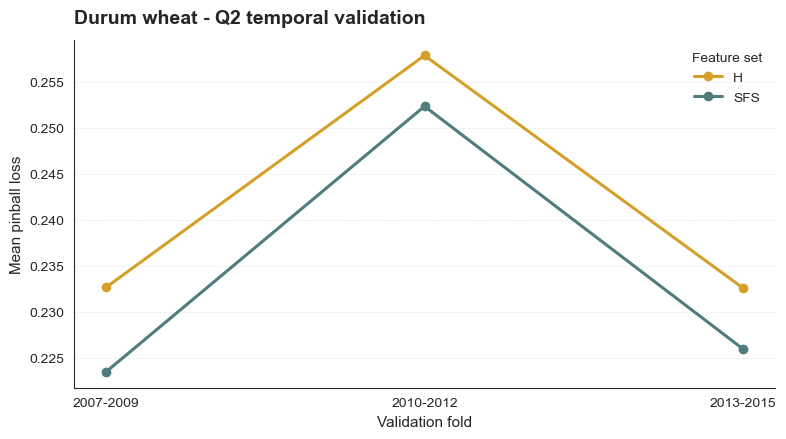

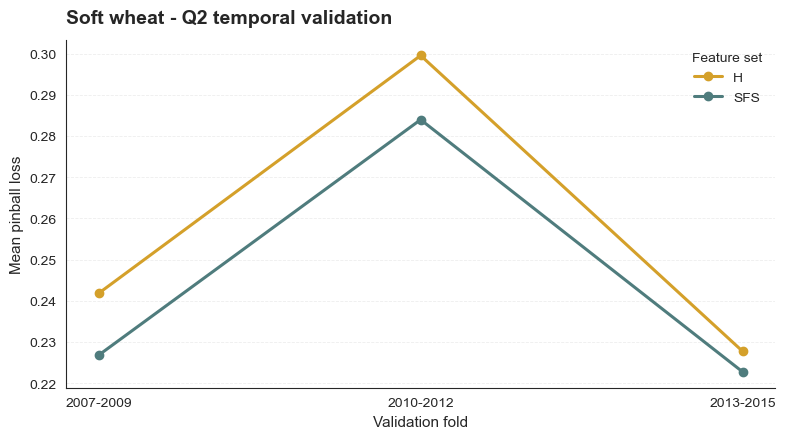

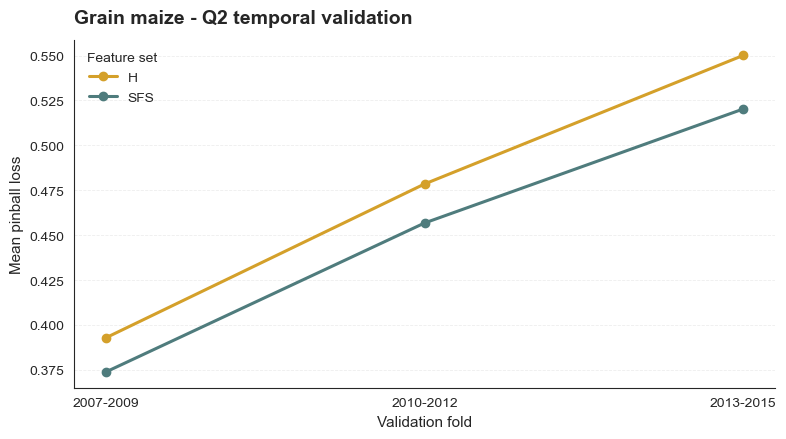

In [17]:
# Plot Q2 losses with the same gold/teal palette and minimal styling used in the
# rest of the project. Each crop keeps its own y scale because absolute pinball
# loss differs substantially between wheat and maize.
set_plot_style()

for crop in CROPS:
    plot_data = (
        fold_results[
            (fold_results["crop"] == crop)
            & (fold_results["quantile"] == "Q2")
        ]
        .pivot(
            index="fold_order",
            columns="features",
            values="pinball",
        )
        .sort_index()
    )

    fold_labels = [
        fold_name
        for fold_name, _, _ in CV_FOLDS
    ]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        plot_data.index,
        plot_data["H"],
        marker="o",
        linewidth=2.2,
        color=GOLD,
        label="H",
    )
    ax.plot(
        plot_data.index,
        plot_data["SFS"],
        marker="o",
        linewidth=2.2,
        color=TEAL,
        label="SFS",
    )

    ax.set_title(f"{crop} - Q2 temporal validation", loc="left")
    ax.set_xlabel("Validation fold")
    ax.set_ylabel("Mean pinball loss")
    ax.set_xticks(range(1, len(fold_labels) + 1))
    ax.set_xticklabels(fold_labels)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend(title="Feature set")

    fig.tight_layout()
    plt.show()

## Interpretations

The development evidence, so far, does **not** support discarding climate features from the linear quantile models. SFS improves mean Q2 loss for every crop and, more importantly, remains better than the historical baseline in every Q2 validation fold. The strength of that evidence is nevertheless crop dependent.

- **Grain maize** provides the clearest case for carrying SFS forward. Its mean Q2 improvement is about 5%, the advantage is stable across the three folds, and SFS also wins every Q1 and Q3 fold. The main counterweight is complexity: the selected model uses 25 predictors.

- **Soft wheat** also benefits from SFS on mean Q2 and in every Q2 fold, but the relative advantage falls from 6.2% in 2007-2009 to 2.2% in 2013-2015. The latest Q1 fold already favours `H`. Climate information therefore appears useful, but its incremental contribution is less temporally robust than for maize.

- **Durum wheat** shows a smaller mean Q2 improvement of about 3%. SFS still wins all three Q2 folds, so there is no development-period reversal at the median, but Q1 and Q3 each contain one fold favouring `H`. The larger feature set should therefore be treated as a promising challenger rather than an automatic replacement for the historical specification.

A final methodological caution remains: SFS was optimized using these same development folds, so the fold-level analysis is mainly a **stability diagnostic of the selected solution**. The later validation period is therefore required to determine whether these development-period gains persist outside the folds used during feature selection.

## L1 (Lasso) regularization of the linear SFS models

The SFS models introduce a larger number of predictors than the historical baseline. While this can improve predictive flexibility, it can also increase estimation variance, particularly when several climate variables contain overlapping information.

**L1 (Lasso) regularization** addresses this problem by adding a penalty proportional to the absolute magnitude of the model coefficients:

$$
\text{Pinball Loss} + \alpha \sum_j |\beta_j|.
$$

This follows the **Lasso principle** introduced by **Tibshirani (1996)**: an L1 penalty shrinks coefficient magnitudes and can drive some coefficients exactly to zero, providing a compromise between predictive fitting and model sparsity. Here the same regularization principle is applied to the quantile-regression objective rather than to ordinary least squares.

As $\alpha$ increases, weak coefficients are progressively shrunk towards zero and sufficiently strong regularization can produce a sparser model. Since all predictors are already standardized inside the modelling pipeline, the penalty is applied on comparable feature scales.

Here L1 regularization is used as a **sensitivity check** on the crop-specific SFS models rather than as a new feature-selection strategy (this mention is needed because Lasso regularization is sometimes used to nullify the contribution of less informative features in a model). The four-feature historical baseline is kept unchanged, while the larger SFS specifications are tested to determine whether additional coefficient shrinkage improves their temporal stability.

For each crop:

- `alpha` is selected using mean temporal-CV Q2 pinball loss over the same three expanding folds used above;
- `alpha = 0` is included, allowing the search to conclude explicitly that regularization provides no improvement;
- when multiple values achieve effectively equivalent Q2 performance, the larger `alpha` is preferred as the more regularized solution;
- the selected crop-specific `alpha` is then reused for Q1 and Q3 rather than tuning each quantile independently.

This deliberately narrow experiment tests whether the selected linear specification benefits materially from regularization before introducing more flexible nonlinear model families.

In [18]:
# Candidate L1 strengths on the standardized SFS predictors. The grid is
# deliberately compact: the purpose is a sensitivity check, not a large search.
L1_ALPHAS = [
    0.0,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
]

# If two alpha values are practically tied on mean Q2 CV loss, prefer the more
# regularized solution. The tolerance is kept on the same scale as the SFS
# stopping tolerance used earlier in the notebook.
L1_SELECTION_TOL = SFS_TOL

### Q2 regularization search

The search below reports three complementary quantities:

* mean Q2 loss across the temporal folds, which drives the choice of `alpha`;
* the standard deviation of the three fold losses, as a descriptive stability indicator;
* the number of non-zero Q2 coefficients after fitting the model on the complete development period.

The coefficient count is useful because an L1 penalty can improve the model either by reducing validation loss or by reaching essentially the same loss with a sparser specification.

In [19]:
# Search one crop-specific alpha on the SFS feature set using Q2 only.
l1_search_rows = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    features = SFS_SELECTED_FEATURES[crop]

    for alpha in L1_ALPHAS:
        fold_scores = q2_l1_cv_scores(
            crop_development,
            features,
            alpha,
            QUANTILES["Q2"],
            CV_FOLDS,
        )

        # Fit once on the full development period only to inspect how much
        # sparsity the penalty induces. This fit is not used to score CV.
        full_model = make_regularized_linear_pipeline(
            QUANTILES["Q2"],
            alpha,
        )

        full_model.fit(
            crop_development[features],
            crop_development["yield"],
        )

        coefficients = full_model.named_steps["model"].coef_
        nonzero_coefficients = np.sum(
            np.abs(coefficients) > 1e-8
        )

        l1_search_rows.append({
            "crop": crop,
            "alpha": alpha,
            "CV Q2": fold_scores["pinball"].mean(),
            "fold std Q2": fold_scores["pinball"].std(ddof=0),
            "non-zero coefficients": nonzero_coefficients,
            "total coefficients": len(coefficients),
        })

In [20]:
l1_search = pd.DataFrame(l1_search_rows)

# Apply the same selection rule crop by crop.
l1_selected_rows = []

for crop in CROPS:
    crop_search = l1_search[
        l1_search["crop"] == crop
    ].copy()

    selected = select_l1_alpha(crop_search, L1_SELECTION_TOL)
    l1_selected_rows.append(selected.to_dict())

l1_selected = pd.DataFrame(l1_selected_rows)

L1_BEST_ALPHA = dict(zip(
    l1_selected["crop"],
    l1_selected["alpha"],
))

print("Selected alpha by crop:")
display(
    l1_selected
    .set_index("crop")
)

print("\nComplete search:")
display(
    l1_search
    .sort_values(["crop", "alpha"])
    .set_index(["crop", "alpha"])
)

Selected alpha by crop:


,alpha,CV Q2,fold std Q2,non-zero coefficients,total coefficients
crop,,,,,
Durum wheat,0.001,0.233818,0.013023,12,12
Soft wheat,0.0001,0.244594,0.0280152,18,18
Grain maize,0.0003,0.450116,0.0599294,24,25



Complete search:


CV Q2  fold std Q2  non-zero coefficients  total coefficients
crop        alpha                                                                  
Durum wheat 0      0.233904    0.0130584                     12                  12
            0.0001 0.233904    0.0130581                     12                  12
            0.0003  0.23391    0.0130493                     12                  12
            0.001  0.233818     0.013023                     12                  12
            0.003  0.233959    0.0122485                     12                  12
            0.01   0.234414    0.0122193                     11                  12
            0.03    0.23466    0.0121315                      8                  12
            0.1    0.271876    0.0113316                      4                  12
Grain maize 0      0.450262    0.0599273                     25                  25
            0.0001  0.45013    0.0599132                     25                  25
            0.0003 0.450116    0.0599294                     24                  25
            0.001  0.450714    0.0602548                     24                  25
            0.003  0.451966    0.0599421                     23                  25
            0.01   0.455471    0.0606082                     19                  25
            0.03   0.464749    0.0569157                     13                  25
            0.1    0.592321    0.0181488                      4                  25
Soft wheat  0      0.244496    0.0279459                     18                  18
            0.0001 0.244594    0.0280152                     18                  18
            0.0003 0.244649    0.0280423                     18                  18
            0.001  0.245032    0.0279426                     18                  18
            0.003  0.246153     0.028014                     18                  18
            0.01   0.248793    0.0294316                     15                  18
            0.03   0.253533    0.0336677                     10                  18
            0.1    0.304213    0.0345437                      5                  18

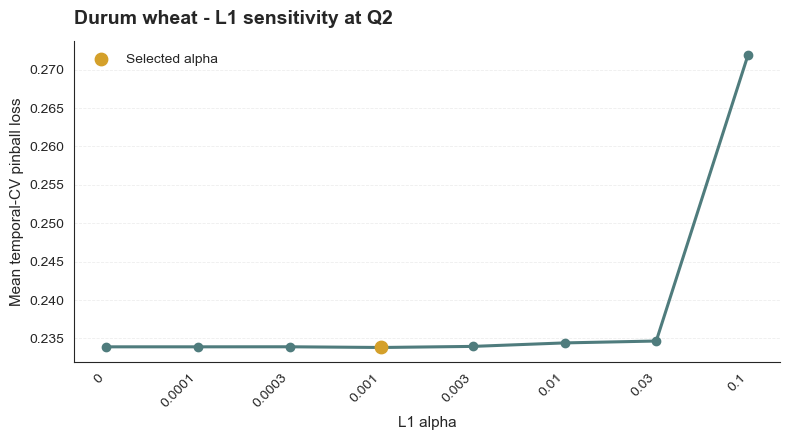

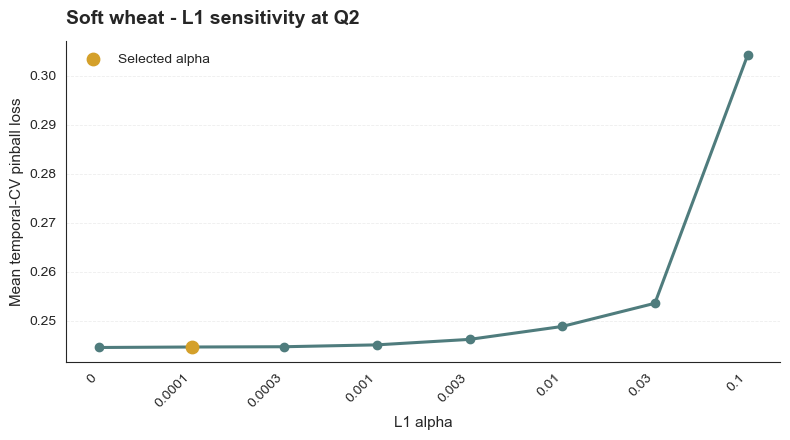

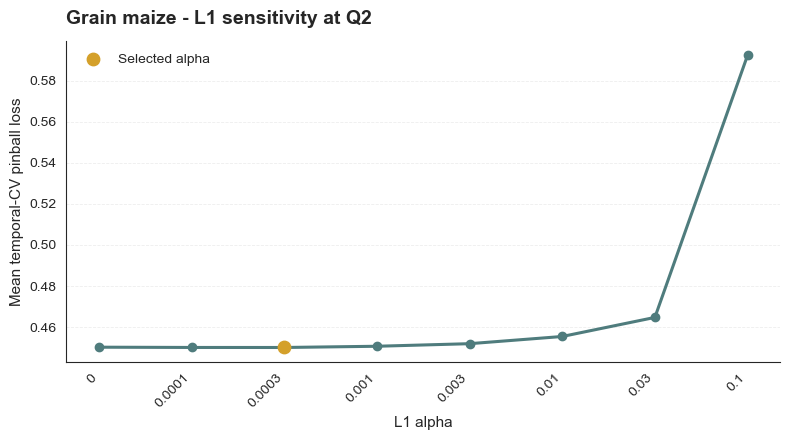

In [21]:
# Visualize the Q2 sensitivity to alpha using the same project style. Alpha is
# treated as a categorical axis so the unregularized value 0 can be shown next
# to the logarithmically spaced positive penalties.
set_plot_style()

alpha_labels = [f"{alpha:g}" for alpha in L1_ALPHAS]

for crop in CROPS:
    plot_data = (
        l1_search[
            l1_search["crop"] == crop
        ]
        .set_index("alpha")
        .reindex(L1_ALPHAS)
        .reset_index()
    )

    selected_alpha = L1_BEST_ALPHA[crop]
    selected_row = plot_data[
        plot_data["alpha"] == selected_alpha
    ].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        range(len(plot_data)),
        plot_data["CV Q2"],
        marker="o",
        linewidth=2.2,
        color=TEAL,
    )

    ax.scatter(
        alpha_labels.index(f"{selected_alpha:g}"),
        selected_row["CV Q2"],
        s=80,
        color=GOLD,
        zorder=3,
        label="Selected alpha",
    )

    ax.set_title(f"{crop} - L1 sensitivity at Q2", loc="left")
    ax.set_xlabel("L1 alpha")
    ax.set_ylabel("Mean temporal-CV pinball loss")
    ax.set_xticks(range(len(alpha_labels)))
    ax.set_xticklabels(alpha_labels, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend()

    fig.tight_layout()
    plt.show()

### Selected L1 models

The chosen `alpha` is now applied to Q1, Q2 and Q3 on the same SFS predictors. This keeps the tuning decision anchored to the primary Q2 objective while allowing the lower and upper conditional quantiles to be checked without a separate hyperparameter search.

The fitted full-development models are stored in `L1_MODELS` with explicit names so they can be reused later for the untouched benchmark without repeating the fit.

In [22]:
# Keep the final crop/quantile fits available for the later benchmark section.
L1_MODELS = {}
l1_results_rows = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    features = SFS_SELECTED_FEATURES[crop]
    alpha = L1_BEST_ALPHA[crop]

    scores = evaluate_regularized_feature_set(
        crop_development,
        features,
        alpha,
        QUANTILES,
        CV_FOLDS,
    )

    l1_results_rows.append({
        "crop": crop,
        "model": "LinearQR-L1",
        "features": "SFS",
        "alpha": alpha,
        "n_features": len(features),
        **scores,
    })

    # Store one final model per quantile, fitted on all development years.
    for quantile_name, quantile in QUANTILES.items():
        model_name = f"{crop}__LinearQR_L1_SFS_{quantile_name}"

        model = make_regularized_linear_pipeline(
            quantile,
            alpha,
        )

        model.fit(
            crop_development[features],
            crop_development["yield"],
        )

        L1_MODELS[model_name] = model

l1_results = pd.DataFrame(l1_results_rows)

# Compare the selected regularized model with its unregularized SFS counterpart.
linear_l1_comparison = pd.concat([
    sfs_results.assign(alpha=0.0),
    l1_results,
], ignore_index=True)

display(
    linear_l1_comparison[
        [
            "crop",
            "model",
            "features",
            "alpha",
            "n_features",
            "Train Q1",
            "CV Q1",
            "Train Q2",
            "CV Q2",
            "Train Q3",
            "CV Q3",
        ]
    ]
    .set_index(["crop", "model", "features"])
)

,,,alpha,n_features,Train Q1,CV Q1,Train Q2,CV Q2,Train Q3,CV Q3
crop,model,features,,,,,,,,
Durum wheat,LinearQR,SFS,0,12,0.19815,0.203725,0.236968,0.233904,0.198888,0.200669
Soft wheat,LinearQR,SFS,0,18,0.206807,0.224383,0.24033,0.244496,0.196539,0.203132
Grain maize,LinearQR,SFS,0,25,0.406718,0.396601,0.474964,0.450262,0.403291,0.401842
Durum wheat,LinearQR-L1,SFS,0.001,12,0.198157,0.203656,0.236983,0.233818,0.1989,0.200717
Soft wheat,LinearQR-L1,SFS,0.0001,18,0.206807,0.224257,0.24033,0.244594,0.196541,0.203097
Grain maize,LinearQR-L1,SFS,0.0003,25,0.406754,0.396191,0.474973,0.450116,0.40331,0.400909


## Q2 screening with CatBoost

### Gradient boosting and CatBoost

Linear quantile regression requires the effect of the predictors to be represented through an additive linear function. Agricultural yield relationships, however, may contain **thresholds, nonlinear responses and interactions**. For example, the effect of precipitation may depend on temperature, crop phase or the level of water stress rather than remaining constant over the full predictor range.

Gradient-boosted decision trees provide a natural way to relax this assumption. Instead of fitting a single global equation, boosting constructs an ensemble of decision trees sequentially. Each new tree is added to reduce the remaining prediction error of the current ensemble.

**CatBoost** is a gradient-boosting implementation originally introduced by **Prokhorenkova et al. (2018)** that supports regression and quantile objectives directly.

The choice of CatBoost as the conventional nonlinear challenger, and subsequently of TabPFN as a foundation-model challenger, is also informed by **TabArena**, a large-scale living benchmark for tabular machine learning (**Erickson et al., 2025**). Its benchmark results show gradient-boosted trees remaining strong contenders on practical tabular datasets, while tabular foundation models are particularly competitive on smaller datasets.

TabArena is used here only to motivate **which model families are worth evaluating**. It does not provide evidence for selecting one of them on the present agricultural dataset: all project-specific model comparisons and final choices remain based exclusively on the chronological validation procedure defined in this notebook. Moreover, because TabArena is a continuously maintained living benchmark, no fixed leaderboard rank is used as a methodological argument.

Tree-based models can represent:

- nonlinear predictor-response relationships;
- threshold effects;
- interactions between variables;
- heterogeneous effects across different regions of the feature space.

They also do not require numerical feature standardization and can handle missing numerical values internally.

This additional flexibility comes with a corresponding risk of overfitting, especially when the number of available predictors is large relative to the number of observations. Early stopping is therefore used here as a minimal regularization mechanism: the optimal number of boosting iterations is identified using the most recent part of each training window, while the external temporal validation fold remains completely unseen.

Because **Q2 is the primary model-selection objective**, CatBoost is evaluated directly with a median quantile loss.
**No hyperparameter search is introduced**, due to a precise design reason: model development here follows a sequential budget logic, **tuning is an investment justified by a preliminary positive signal**, not a prerequisite for a fair first assessment. 
Moreover, **robust default behaviour is an explicit part of CatBoost's value proposition**, so an out-of-the-box configuration with temporal early stopping is a legitimate representation of the model family at this screening stage. The claims made in this section are consequently scoped to the default specification: they establish whether gradient boosting is promising enough on this dataset to warrant an effort in tuning.

Three feature representations are considered:

- `H`: the parsimonious historical predictor set;
- `SFS`: the crop-specific subset selected for linear Q2 regression;
- `Full`: the complete predictor pool, retained as a sensitivity experiment.

The `Full` specification is particularly informative for CatBoost because a feature that provides little linear incremental value may still contribute through nonlinear effects or interactions.

### Temporal evaluation

CatBoost is evaluated on the same three expanding temporal folds used by the linear models.

`H` and `SFS` are the primary specifications. `Full` remains a high-dimensional attempt.

For each fold, the stopping iteration is learned only from the fold's own training years. The model is then refitted on that complete training window before predicting the later validation block.

The final 1995-2015 CatBoost models follow the same rule and are stored for the later validation step. The reported iteration counts make the effect of early stopping visible without introducing a tuning grid.

In [23]:
catboost_q2_fold_rows = []
catboost_q2_rows = []
CATBOOST_Q2_MODELS = {}

for crop in CROPS:
    crop_data = development_data[
        development_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP),
        "SFS": native_feature_names(
            SFS_SELECTED_FEATURES[crop],
            NATIVE_FEATURE_MAP,
        ),
        "Full": native_feature_names(
            SFS_CANDIDATE_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
    }

    for feature_label, features in feature_sets.items():
        fold_losses = []
        fold_iterations = []

        for fold_name, validation_start, validation_end in CV_FOLDS:
            train = crop_data[
                crop_data["harvest_year"] < validation_start
            ]
            validation = crop_data[
                crop_data["harvest_year"].between(
                    validation_start,
                    validation_end,
                )
            ]

            model, best_iterations = fit_catboost_q2(
                train,
                features,
                EARLY_STOPPING_YEARS,
                EARLY_STOPPING_ROUNDS,
            )

            loss = pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            )

            fold_losses.append(loss)
            fold_iterations.append(best_iterations)
            catboost_q2_fold_rows.append({
                "crop": crop,
                "features": feature_label,
                "fold": fold_name,
                "Q2 pinball": loss,
                "iterations": best_iterations,
            })

        final_model, final_iterations = fit_catboost_q2(
            crop_data,
            features,
            EARLY_STOPPING_YEARS,
            EARLY_STOPPING_ROUNDS,
        )

        train_q2 = pinball(
            crop_data["yield"],
            final_model.predict(crop_data[features]),
            QUANTILES["Q2"],
        )

        CATBOOST_Q2_MODELS[
            f"{crop}__CatBoostQ2_{feature_label}"
        ] = final_model

        catboost_q2_rows.append({
            "crop": crop,
            "model": "CatBoostQ2",
            "features": feature_label,
            "n_features": len(features),
            "Train Q2": train_q2,
            "CV Q2": np.mean(fold_losses),
            "Mean CV iterations": np.mean(fold_iterations),
            "Final iterations": final_iterations,
        })

catboost_q2_results = pd.DataFrame(catboost_q2_rows)
catboost_q2_fold_results = pd.DataFrame(
    catboost_q2_fold_rows
)

display(
    catboost_q2_results
    .set_index(["crop", "model", "features"])
)

n_features  Train Q2    CV Q2  Mean CV iterations  Final iterations
crop        model      features                                                                     
Durum wheat CatBoostQ2 H                  4  0.213079 0.235854             213.333               261
                       SFS               12  0.181012 0.240514             227.333               302
                       Full             196   0.16732 0.261152                 127               256
Soft wheat  CatBoostQ2 H                  4   0.23587 0.267872                 210               165
                       SFS               18  0.184562 0.262959             255.667               314
                       Full             196  0.163522 0.281811                 306               330
Grain maize CatBoostQ2 H                  4  0.457746 0.460483                 217               180
                       SFS               25  0.409055 0.460734             321.333               198
                       Full             196  0.389662 0.470954                 341               231

### Development comparison

The early-stopped CatBoost results are compared with the linear Q2 models evaluated on the same development folds.

The comparison remains deliberately limited to Q2 because this is the screening objective.

In [24]:
development_q2_comparison = pd.concat([
    baseline_results[["crop", "CV Q2"]].assign(
        model_label="Linear H"
    ),
    sfs_results[["crop", "CV Q2"]].assign(
        model_label="Linear SFS"
    ),
    l1_results[["crop", "CV Q2"]].assign(
        model_label="Linear L1 SFS"
    ),
    catboost_q2_results[["crop", "features", "CV Q2"]].assign(
        model_label=lambda x: "CatBoost " + x["features"]
    )[["crop", "model_label", "CV Q2"]],
], ignore_index=True)

display(
    development_q2_comparison
    .sort_values(["crop", "CV Q2"])
    .set_index(["crop", "model_label"])
)

CV Q2
crop        model_label           
Durum wheat Linear L1 SFS 0.233818
            Linear SFS    0.233904
            CatBoost H    0.235854
            CatBoost SFS  0.240514
            Linear H      0.241013
            CatBoost Full 0.261152
Grain maize Linear L1 SFS 0.450116
            Linear SFS    0.450262
            CatBoost H    0.460483
            CatBoost SFS  0.460734
            CatBoost Full 0.470954
            Linear H      0.473793
Soft wheat  Linear SFS    0.244496
            Linear L1 SFS 0.244594
            Linear H       0.25635
            CatBoost SFS  0.262959
            CatBoost H    0.267872
            CatBoost Full 0.281811

### CatBoost interpretation

This CatBoost setup improves several development scores relative to the earlier unrestricted fit, but it does not change the main model ranking.

- For **durum wheat**, `CatBoost H` becomes competitive with the linear models, but the best linear SFS specifications retain the lowest mean temporal-CV Q2. Adding the SFS or complete feature sets does not improve CatBoost further.

- For **grain maize**, early-stopped CatBoost narrows the gap, especially with the compact `H` specification, but both linear SFS models remain clearly stronger on mean temporal-CV Q2.

- For **soft wheat**, `CatBoost SFS` is the strongest CatBoost specification, yet its mean CV loss remains above both the selected linear model and the simpler `Linear H` reference.

The `Full` specification provides a consistent warning against unrestricted dimensionality in this dataset. It achieves substantially lower training loss but does not translate that additional fitting capacity into better temporal validation performance (and, with that many features, it was in fact expected to be faced with overfitting). 
Native missing-value handling and early stopping therefore make CatBoost a more credible nonlinear benchmark, but the development evidence still does not justify selecting it over the strongest linear candidates.

Native missing-value handling and early stopping therefore make CatBoost a more credible nonlinear benchmark. 
The development evidence nevertheless gives no indication that a default-configuration CatBoost improves on the strongest linear candidates for any crop, and therefore provides no preliminary signal that would justify allocating a tuning budget to this model.
(This does not exclude that a different configuration could perform better, but it just means that from what it has been possible to see preliminarly it has been determined as more advantageous to pursue a different approach).

## Validation set: 2016-2018

The 2016-2022 block is divided chronologically into:

- **2016-2018: validation set**, used for model comparison after the development work;
- **2019-2022: final test set**, which remains completely untouched.

The earlier temporal folds are the inner development validation used for SFS, regularization checks and model screening. The outer-validation period is the last dataset that may inform the model choice.

The 2019-2022 final test will only be used to evaluate the already chosen model, not to choose among candidates.

In [25]:
outer_validation_data = benchmark_data[
    benchmark_data["harvest_year"].between(2016, 2018)
].copy()

final_test_data = benchmark_data[
    benchmark_data["harvest_year"] >= 2019
].copy()

split_sizes = pd.concat([
    outer_validation_data.groupby("crop_name").size().rename("2016-2018 validation"),
    final_test_data.groupby("crop_name").size().rename("2019-2022 final test"),
], axis=1)

display(split_sizes)

,2016-2018 validation,2019-2022 final test
crop_name,,
Durum wheat,276,373
Grain maize,283,366
Soft wheat,286,361


### Outer-validation results

All Q2 models retained so far are evaluated on 2016-2018 after fitting only on the 1995-2015 development period.

For CatBoost, the stopping iteration is determined within 1995-2015 and the final model is refitted on the complete development period before predicting 2016-2018. The outer-validation observations are never used by early stopping.

The main CatBoost comparison remains `H` versus `SFS`; `Full` remains an additional sensitivity experiment. Lower pinball loss is better.

In [26]:
outer_rows = []
Q2_DEVELOPMENT_MODELS = {}

for crop in CROPS:
    train = development_data[
        development_data["crop_name"] == crop
    ].copy()

    validation = outer_validation_data[
        outer_validation_data["crop_name"] == crop
    ].copy()

    # Linear Q2 models.
    linear_specs = {
        "Linear H": (
            HISTORICAL_FEATURES,
            make_linear_pipeline(QUANTILES["Q2"]),
        ),
        "Linear SFS": (
            SFS_SELECTED_FEATURES[crop],
            make_linear_pipeline(QUANTILES["Q2"]),
        ),
        "Linear L1 SFS": (
            SFS_SELECTED_FEATURES[crop],
            make_regularized_linear_pipeline(
                QUANTILES["Q2"],
                L1_BEST_ALPHA[crop],
            ),
        ),
    }

    for model_label, (features, model) in linear_specs.items():
        model.fit(train[features], train["yield"])
        Q2_DEVELOPMENT_MODELS[f"{crop}__{model_label}"] = model

        outer_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Outer validation Q2": pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            ),
        })

    # CatBoost models were already fitted on the complete development period.
    catboost_features = {
        "CatBoost H": ("H", native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP)),
        "CatBoost SFS": ("SFS", native_feature_names(SFS_SELECTED_FEATURES[crop], NATIVE_FEATURE_MAP)),
        "CatBoost Full": ("Full", native_feature_names(SFS_CANDIDATE_FEATURES, NATIVE_FEATURE_MAP)),
    }

    for model_label, (feature_label, features) in catboost_features.items():
        model = CATBOOST_Q2_MODELS[
            f"{crop}__CatBoostQ2_{feature_label}"
        ]
        Q2_DEVELOPMENT_MODELS[f"{crop}__{model_label}"] = model

        outer_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Outer validation Q2": pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            ),
        })

outer_validation_results = pd.DataFrame(outer_rows)

outer_comparison = (
    development_q2_comparison
    .merge(
        outer_validation_results,
        on=["crop", "model_label"],
        how="left",
    )
)

display(
    outer_comparison
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

CV Q2  Outer validation Q2
crop        model_label                                
Durum wheat Linear H      0.241013             0.195533
            Linear L1 SFS 0.233818             0.198056
            Linear SFS    0.233904             0.198126
            CatBoost H    0.235854             0.204929
            CatBoost SFS  0.240514             0.210005
            CatBoost Full 0.261152              0.22119
Grain maize Linear L1 SFS 0.450116             0.425793
            Linear SFS    0.450262             0.426646
            Linear H      0.473793             0.429603
            CatBoost H    0.460483             0.438843
            CatBoost SFS  0.460734             0.441446
            CatBoost Full 0.470954             0.445858
Soft wheat  CatBoost SFS  0.262959             0.228013
            Linear H       0.25635             0.228368
            Linear L1 SFS 0.244594              0.23157
            Linear SFS    0.244496             0.231784
            CatBoost Full 0.281811              0.23245
            CatBoost H    0.267872             0.233262

### Visual comparison of the performances on the validation period

The barplots show only the 2016-2018 outer-validation loss, keeping this evidence visually separate from the inner development CV.

Models are ordered by Q2 pinball loss within each crop. The CatBoost `Full` specification remains a sensitivity experiment rather than a preferred feature strategy by construction.

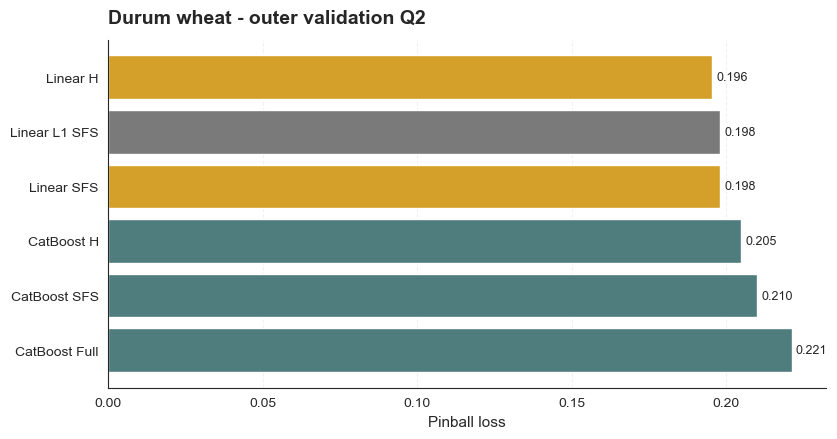

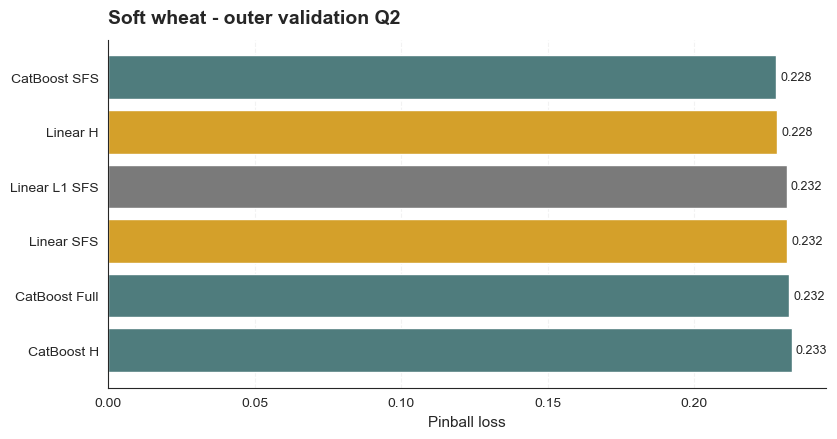

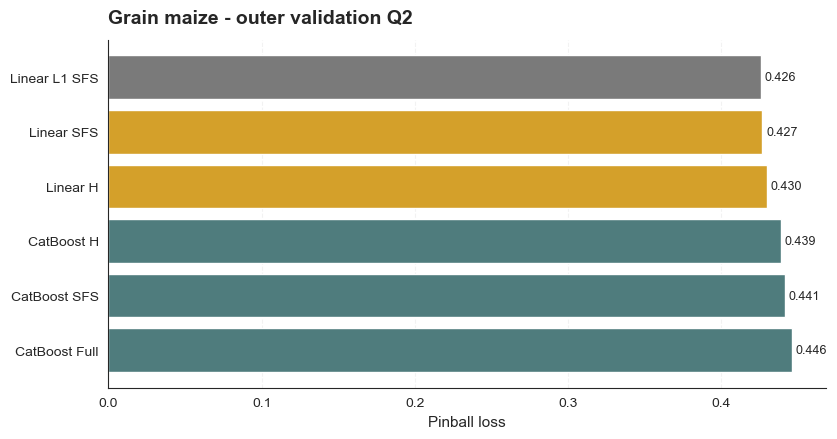

In [27]:
set_plot_style()

for crop in CROPS:
    plot_data = (
        outer_validation_results[
            outer_validation_results["crop"] == crop
        ]
        .sort_values("Outer validation Q2", ascending=True)
    )

    colors = [
        (
            GRAY_MED
            if label == "Linear L1 SFS"
            else TEAL
            if label.startswith("CatBoost")
            else GOLD
        )
        for label in plot_data["model_label"]
    ]

    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    bars = ax.barh(
        plot_data["model_label"],
        plot_data["Outer validation Q2"],
        color=colors,
    )

    ax.invert_yaxis()
    ax.set_title(f"{crop} - outer validation Q2")
    ax.set_xlabel("Pinball loss")
    ax.set_ylabel("")
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )
    ax.set_axisbelow(True)

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

### Outer-validation interpretation

The 2016-2018 period changes the interpretation of the feature-selection results more than it changes the ranking between model families.

- For **durum wheat**, the simple `Linear H` specification achieves the lowest outer-validation Q2 loss. The larger SFS models, despite their development-CV advantage, no longer improve the median forecast. CatBoost also remains behind the linear alternatives.

- For **grain maize**, the two linear SFS specifications remain the strongest candidates. Their advantage over `Linear H` is small on this later period but still present, while none of the CatBoost specifications improves on them.

- For **soft wheat**, the ordering changes more substantially. `Linear H` outperforms both linear SFS models, while `CatBoost SFS` reaches an almost identical loss and is marginally lower. The difference between `CatBoost SFS` and `Linear H` is extremely small, however, and CatBoost remains weaker across the development folds. This should therefore be treated as a late-period near-tie rather than evidence of a clear CatBoost advantage.

Overall, **the outer validation weakens the case for automatically retaining climate variables simply because they were selected during development**. Their predictive contribution is crop- and period-dependent, making temporal robustness more important than the best score obtained in any single development stage.

## Conclusions after conventional models

The work so far compare two conventional modelling families with substantially different inductive biases: linear quantile regression and gradient-boosted decision trees.

The linear models provide the strongest overall development evidence. Climate-enhanced SFS specifications improve the historical baseline consistently across the development folds, although the 2016-2018 outer validation shows that this advantage does not transfer equally to every crop. In particular, the simpler historical specification remains highly competitive outside the feature-selection period.

CatBoost introduces non-linearity, thresholds and interactions without requiring an explicit functional form. Temporal early stopping and native missing-value handling make it a substantially more robust challenger than the initial unrestricted specification. The updated model becomes competitive in several cases, including a near-tie with `Linear H` for soft wheat on 2016-2018, but it still does not show a consistent advantage over the strongest linear references across the development folds.

No CatBoost specification reaches the strongest linear references on the development folds, so there is no preliminary signal that would make a tuning investment in this family worthwhile at this stage. The next experiment therefore reallocates that budget to a model family based on a different learning paradigm, **tabular foundation models**, rather than to a deeper search within gradient boosting.

This additional comparison is particularly relevant to be able to verify if a model that transfers knowledge learned across many previous tabular problems can exploit the available historical and climate information more effectively than models trained exclusively on the current crop dataset.

## **Tabular foundation models and TabPFN**

### Tabular foundation models

Most supervised machine-learning algorithms are **task-specific**. A linear model, a random forest or a gradient-boosting model starts with a predefined learning algorithm and estimates its parameters from the training observations of the current dataset.

Foundation models introduce a different paradigm. Instead of learning only from the target dataset, a model is first **pretrained across a large collection of tasks**. The objective of pretraining is to acquire reusable knowledge that can later be transferred to previously unseen problems.

This paradigm has been highly successful in domains such as language and images, where very large pretrained models can adapt to new tasks with limited additional information. Applying the same idea to tabular data is more difficult because tables do not share a universal structure: different datasets can contain completely different features, units, distributions and relationships between predictors and targets.

**Tabular foundation models** attempt to overcome this problem by learning reusable strategies for prediction across many different tabular tasks rather than memorizing one fixed feature representation.

Conceptually, this changes the source of the model's inductive bias:

- a linear model assumes a predefined functional form;
- gradient boosting learns flexible rules from the current dataset;
- a tabular foundation model can additionally exploit knowledge acquired during pretraining across other prediction problems.

The target dataset is therefore no longer the model's only source of statistical information.

### Prior-Data Fitted Networks

TabPFN belongs to the family of **Prior-Data Fitted Networks (PFNs)**.

Instead of being pretrained on a fixed collection of real-world datasets, a PFN is trained on a very large distribution of **synthetically generated prediction problems**. These artificial datasets are sampled from a prior designed to represent many possible relationships between predictors and targets, including nonlinearities, interactions, noise and different data-generating structures.

During pretraining, the model repeatedly observes a dataset divided into labelled and unlabelled examples and learns to predict the missing targets. Across millions of such tasks, the network effectively learns not only representations of data but a **general prediction procedure**.

The resulting model can be interpreted as learning an approximation to Bayesian inference under the distribution of synthetic tasks used during pretraining. Given a new training dataset, it uses the observed examples to infer which kinds of relationships are plausible and forms predictions for new observations.

This is fundamentally different from fitting CatBoost or linear regression: the expensive learning of the general prediction strategy has already occurred during pretraining.

### In-context learning in TabPFN

At prediction time, TabPFN uses **in-context learning**.

In conventional supervised learning,

$$
\text{training data}
\rightarrow
\text{parameter optimization}
\rightarrow
\text{fitted model}
\rightarrow
\text{prediction}.
$$

TabPFN instead receives the labelled training observations as part of its prediction context:

$$
(X_{\text{train}}, y_{\text{train}}, X_{\text{test}})
\rightarrow
\text{pretrained TabPFN}
\rightarrow
p(y_{\text{test}} \mid X_{\text{train}}, y_{\text{train}}, X_{\text{test}}).
$$

The model therefore adapts to the new dataset through its **input context**, rather than by learning a completely new set of neural-network parameters from scratch.

The familiar `.fit()` interface should consequently not be interpreted in exactly the same way as fitting the previous estimators. In the basic TabPFN workflow, the training observations become the context on which the pretrained model conditions its predictions.

For regression, TabPFN can return a predictive distribution rather than only a single point estimate. This is especially useful in the present project because Q1, Q2 and Q3 can be extracted from the same predicted conditional distribution instead of fitting three completely independent regression models.

### Why TabPFN is relevant to this project

The characteristics of the present dataset make TabPFN a particularly relevant option.

Each crop provides only a few thousand annual province-level observations, while the complete representation contains a comparatively large number of historical and phase-level climate predictors. Many of these variables are correlated and their relationship with yield may involve interactions, thresholds or other nonlinear structures.

This creates a difficult regime for conventional modelling:

- simple linear models may underrepresent complex relationships;
- highly flexible models can overfit because task-specific training data are limited;
- aggressive feature selection can discard variables whose value appears only through nonlinear interactions.

A pretrained tabular model offers a different trade-off. TabPFN brings an external inductive bias learned from many previous synthetic prediction problems while still conditioning directly on the observations available for each crop.

The comparison of `H`, `SFS` and `Full` is therefore more than a feature-count experiment. It also tests whether the feature subset identified for a linear model remains appropriate for a model whose learned prediction strategy is fundamentally different.

At the same time, pretraining does not guarantee temporal generalization. The synthetic prior used to train TabPFN is not specific to Italian agriculture, and relationships in the real data may change across time. TabPFN is therefore evaluated with exactly the same chronological logic used for the conventional models.

### Experimental setup

The previous three feature definitions are preserved:

- `H`, containing the historical predictors;
- `SFS`, containing the crop-specific subset selected by linear Q2 regression;
- `Full`, containing the complete candidate predictor pool.

Historical missing values are passed natively to TabPFN instead of being replaced by the earlier zero-imputed representation. The SFS procedure itself is not repeated: selected historical variables are simply mapped back to their raw counterparts. This preserves the completed feature-selection experiment while allowing TabPFN to use its native treatment of missing information.

No task-specific TabPFN tuning is introduced. `random_state=0` is fixed and thinking mode remains disabled.

Q1, Q2 and Q3 are obtained from the predictive distribution returned by the same TabPFN regressor, with Q2 retained as the primary model-comparison metric.

The TabPFN methodology and the Prior-Data Fitted Network paradigm used here are described in **Hollmann et al. (2025)**. Because inference is performed through the hosted TabPFN API, the exact remote checkpoint used by this notebook is recorded explicitly after the first API calls. The recorded checkpoint, `tabpfn-v3-regressor-v3_default.ckpt`, identifies the experiments as using **TabPFN-3**, whose model generation and evaluation are documented in **Grinsztajn et al. (2026)**.

In [28]:
load_dotenv()

TABPFN_TOKEN = os.environ["TABPFN_TOKEN"]
tabpfn_client.set_access_token(TABPFN_TOKEN)

In [29]:
tabpfn_rows = []
TABPFN_MODELS = {}

for crop in CROPS:
    train = development_data[
        development_data["crop_name"] == crop
    ].copy()

    validation = outer_validation_data[
        outer_validation_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP),
        "SFS": native_feature_names(SFS_SELECTED_FEATURES[crop], NATIVE_FEATURE_MAP),
        "Full": native_feature_names(SFS_CANDIDATE_FEATURES, NATIVE_FEATURE_MAP),
    }

    for feature_label, features in feature_sets.items():
        model = TabPFNRegressor(
            random_state=0,
            thinking_mode=False,
        )

        model.fit(
            train[features],
            train["yield"],
        )

        predictions = model.predict(
            validation[features],
            output_type="quantiles",
            quantiles=[0.25, 0.50, 0.75],
        )

        q1, q2, q3 = predictions

        TABPFN_MODELS[
            f"{crop}__TabPFN_{feature_label}"
        ] = model

        tabpfn_rows.append({
            "crop": crop,
            "model_label": f"TabPFN {feature_label}",
            "Outer validation Q1": pinball(
                validation["yield"], q1, 0.25
            ),
            "Outer validation Q2": pinball(
                validation["yield"], q2, 0.50
            ),
            "Outer validation Q3": pinball(
                validation["yield"], q3, 0.75
            ),
        })

tabpfn_results = pd.DataFrame(tabpfn_rows)

display(
    tabpfn_results
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:03 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

...

00:02 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


Outer validation Q1  Outer validation Q2  Outer validation Q3
crop        model_label                                                               
Durum wheat TabPFN H                0.170506             0.198393             0.170128
            TabPFN SFS               0.17123             0.200921             0.172907
            TabPFN Full             0.171974             0.201195             0.163975
Grain maize TabPFN Full             0.339042             0.406309             0.345015
            TabPFN SFS              0.343955             0.418836             0.367799
            TabPFN H                0.377458             0.424602             0.364914
Soft wheat  TabPFN Full             0.177191             0.210746             0.178223
            TabPFN H                0.185168             0.220857             0.186207
            TabPFN SFS              0.180598             0.222737              0.18999

### TabPFN API model version check

The `tabpfn-client` package version used by this notebook is pinned in the project `requirements.txt`. However, inference is performed through the TabPFN API, which serves the underlying pretrained model remotely.

To make the modelling results reproducible, the metadata returned by the API after the first TabPFN prediction is therefore inspected to record the exact model checkpoint used during the experiments.

In [30]:
# Record the TabPFN model version served by the API.
tabpfn_example_model = next(iter(TABPFN_MODELS.values()))

print(
    "TabPFN API model path and version:",
    tabpfn_example_model._last_meta["tabpfn_config"]["model_path"],
)

TabPFN API model path and version: /app/tabpfn_models/tabpfn-v3-regressor-v3_default.ckpt


The API reports the following remote model checkpoint:

`tabpfn-v3-regressor-v3_default.ckpt`

Therefore, the TabPFN experiments in this notebook were performed using the **TabPFN v3 regression model** with the `v3_default` checkpoint.

For strict reproducibility, future executions should use both the `tabpfn-client` version pinned in `requirements.txt` and the same remote TabPFN model checkpoint. If the API reports a different model version or checkpoint, the resulting predictions should not be considered an exact reproduction of the experiments reported here.

Outer validation Q2
crop        model_label                       
Durum wheat Linear H                  0.195533
            TabPFN H                  0.198393
            TabPFN SFS                0.200921
            TabPFN Full               0.201195
Grain maize TabPFN Full               0.406309
            TabPFN SFS                0.418836
            TabPFN H                  0.424602
            Linear L1 SFS             0.425793
Soft wheat  TabPFN Full               0.210746
            TabPFN H                  0.220857
            TabPFN SFS                0.222737
            Linear H                  0.228368

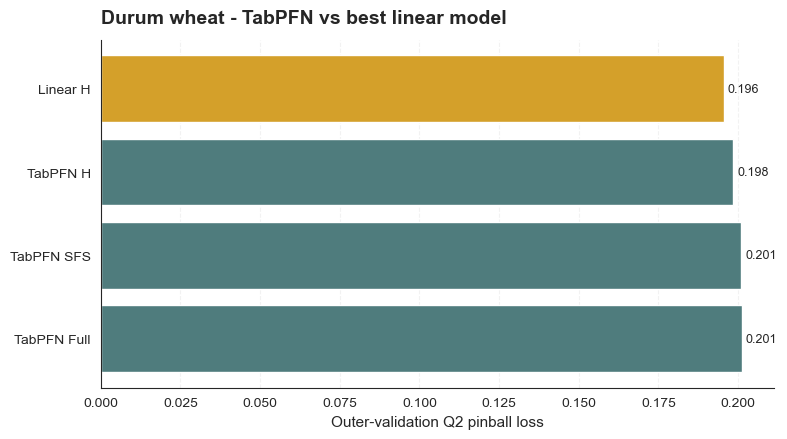

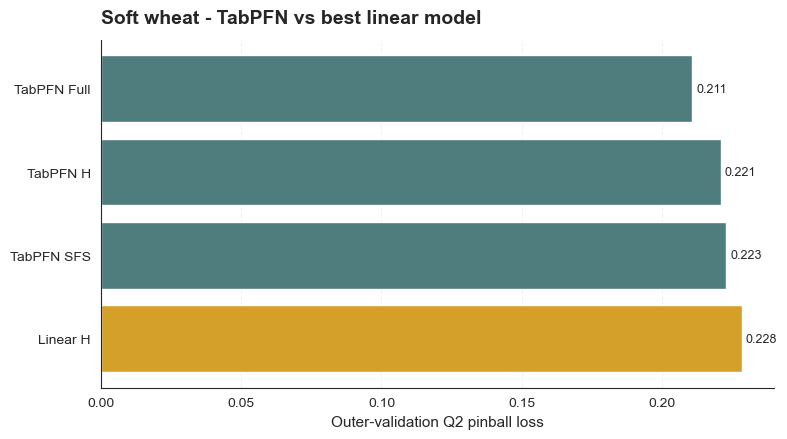

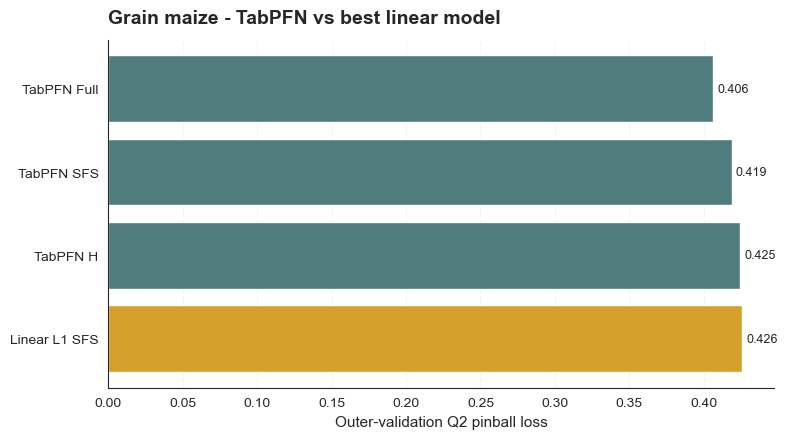

In [31]:
# Select the best linear model for each crop.
linear_winners = (
    outer_validation_results[
        outer_validation_results["model_label"].str.startswith("Linear")
    ]
    .sort_values(["crop", "Outer validation Q2"])
    .groupby("crop", as_index=False)
    .first()
)

# Add TabPFN results.
tabpfn_comparison = pd.concat([
    linear_winners,
    tabpfn_results[
        ["crop", "model_label", "Outer validation Q2"]
    ],
], ignore_index=True)

display(
    tabpfn_comparison
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

# Visual comparison.
set_plot_style()

for crop in CROPS:
    plot_data = (
        tabpfn_comparison[
            tabpfn_comparison["crop"] == crop
        ]
        .sort_values("Outer validation Q2")
    )

    colors = [
        GOLD if label.startswith("Linear") else TEAL
        for label in plot_data["model_label"]
    ]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    bars = ax.barh(
        plot_data["model_label"],
        plot_data["Outer validation Q2"],
        color=colors,
    )

    ax.invert_yaxis()
    ax.set_title(
        f"{crop} - TabPFN vs best linear model",
        loc="left",
    )
    ax.set_xlabel("Outer-validation Q2 pinball loss")
    ax.set_ylabel("")
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )
    ax.set_axisbelow(True)

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

### Validation set comparison and candidates for the robustness check

The 2016-2018 outer-validation period remains the primary model-selection evidence.

For **grain maize**, `TabPFN Full` has the lowest Q2 loss (0.406309), followed by `TabPFN SFS` (0.418836). The relative improvement of `Full` over `SFS` is about **3.0%**, below the 5% threshold. These two specifications therefore proceed to the temporal-robustness tie-breaker.

For **soft wheat**, `TabPFN Full` also has the lowest Q2 loss (0.210746), followed by `TabPFN H` (0.220857). The relative improvement is about **4.6%**, again below the 5% threshold. These two specifications therefore proceed to the same tie-breaker.

The temporal robustness check below uses only the three chronological development folds. The 2016-2018 outer-validation result is kept visible for context, but it is not included in the robustness summary.

### Temporal backtest of the model-selection finalists

The outer-validation comparison identifies the candidate pairs that require a tie-breaker under the predefined selection rule:

- **Grain maize:** `TabPFN SFS` versus `TabPFN Full`;
- **Soft wheat:** `TabPFN H` versus `TabPFN Full`.

The temporal backtest evaluates these candidates on the same three expanding development folds used earlier in the notebook. These folds are used only as a **temporal robustness diagnostic**: mean Q2 loss, Q2 variability and the number of folds won are calculated from the development folds alone.

Q1 and Q3 are retained in the fold-level results so that quantile behaviour can be considered later if temporal robustness does not provide a clear distinction.

The 2016-2018 outer-validation result remains the primary selection metric and is shown separately in the comparison table and plots. It is not averaged together with the development folds.

(The 2019-2022 final test remains completely untouched.)


In [32]:
TABPFN_BACKTEST_FEATURE_SETS = {
    "Grain maize": {
        "SFS": native_feature_names(
            SFS_SELECTED_FEATURES["Grain maize"],
            NATIVE_FEATURE_MAP,
        ),
        "Full": native_feature_names(
            SFS_CANDIDATE_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
    },
    "Soft wheat": {
        "H": native_feature_names(
            HISTORICAL_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
        "Full": native_feature_names(
            SFS_CANDIDATE_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
    },
}

TABPFN_BACKTEST_CROPS = list(
    TABPFN_BACKTEST_FEATURE_SETS
)

tabpfn_fold_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    crop_data = development_data[
        development_data["crop_name"] == crop
    ].copy()

    for feature_label, features in (
        TABPFN_BACKTEST_FEATURE_SETS[crop].items()
    ):
        for fold_name, validation_start, validation_end in CV_FOLDS:
            train = crop_data[
                crop_data["harvest_year"] < validation_start
            ]

            validation = crop_data[
                crop_data["harvest_year"].between(
                    validation_start,
                    validation_end,
                )
            ]

            model = TabPFNRegressor(
                random_state=0,
                thinking_mode=False,
            )

            model.fit(
                train[features],
                train["yield"],
            )

            predictions = model.predict(
                validation[features],
                output_type="quantiles",
                quantiles=[0.25, 0.50, 0.75],
            )

            q1, q2, q3 = predictions

            tabpfn_fold_rows.append({
                "crop": crop,
                "fold": fold_name,
                "model_label": f"TabPFN {feature_label}",
                "Q1": pinball(
                    validation["yield"],
                    q1,
                    0.25,
                ),
                "Q2": pinball(
                    validation["yield"],
                    q2,
                    0.50,
                ),
                "Q3": pinball(
                    validation["yield"],
                    q3,
                    0.75,
                ),
            })

tabpfn_fold_results = pd.DataFrame(
    tabpfn_fold_rows
)

display(
    tabpfn_fold_results
    .sort_values(["crop", "fold", "Q2"])
    .set_index(["crop", "fold", "model_label"])
)

00:00 Fitting... \

00:02 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

...

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


Q1       Q2       Q3
crop        fold      model_label                           
Grain maize 2007-2009 TabPFN SFS  0.353097 0.390852 0.323996
                      TabPFN Full 0.359113 0.400393 0.329177
            2010-2012 TabPFN SFS  0.433334 0.464085 0.373365
                      TabPFN Full 0.434846  0.47029 0.385661
            2013-2015 TabPFN SFS  0.384062 0.481557 0.438408
                      TabPFN Full 0.394318 0.504788 0.458612
Soft wheat  2007-2009 TabPFN H    0.217422  0.24747 0.193771
                      TabPFN Full 0.218077 0.248069  0.18928
            2010-2012 TabPFN Full 0.262866 0.293578 0.228765
                      TabPFN H     0.26243 0.296852  0.23455
            2013-2015 TabPFN H    0.220189 0.244423  0.19574
                      TabPFN Full 0.221084 0.262397 0.203342

In [33]:
comparison_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    model_labels = [
        f"TabPFN {feature_label}"
        for feature_label in TABPFN_BACKTEST_FEATURE_SETS[crop]
    ]

    # Development folds.
    for fold_name, _, _ in CV_FOLDS:
        row = {
            "crop": crop,
            "period": fold_name,
        }

        for model_label in model_labels:
            row[model_label] = tabpfn_fold_results[
                (tabpfn_fold_results["crop"] == crop)
                & (tabpfn_fold_results["fold"] == fold_name)
                & (tabpfn_fold_results["model_label"] == model_label)
            ]["Q2"].iloc[0]

        comparison_rows.append(row)

    # Outer validation, shown separately from the robustness summary.
    row = {
        "crop": crop,
        "period": "2016-2018 outer",
    }

    for model_label in model_labels:
        row[model_label] = tabpfn_results[
            (tabpfn_results["crop"] == crop)
            & (tabpfn_results["model_label"] == model_label)
        ]["Outer validation Q2"].iloc[0]

    comparison_rows.append(row)

tabpfn_temporal_comparison = pd.DataFrame(
    comparison_rows
)

display(
    tabpfn_temporal_comparison
    .set_index(["crop", "period"])
)

TabPFN SFS  TabPFN Full  TabPFN H
crop        period                                            
Grain maize 2007-2009          0.390852     0.400393       NaN
            2010-2012          0.464085      0.47029       NaN
            2013-2015          0.481557     0.504788       NaN
            2016-2018 outer    0.418836     0.406309       NaN
Soft wheat  2007-2009               NaN     0.248069   0.24747
            2010-2012               NaN     0.293578  0.296852
            2013-2015               NaN     0.262397  0.244423
            2016-2018 outer         NaN     0.210746  0.220857

In [34]:
summary_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    crop_folds = tabpfn_fold_results[
        tabpfn_fold_results["crop"] == crop
    ].copy()

    model_labels = [
        f"TabPFN {feature_label}"
        for feature_label in TABPFN_BACKTEST_FEATURE_SETS[crop]
    ]

    q2_by_fold = crop_folds.pivot(
        index="fold",
        columns="model_label",
        values="Q2",
    )

    period_best = q2_by_fold[model_labels].min(axis=1)

    for model_label in model_labels:
        model_folds = crop_folds[
            crop_folds["model_label"] == model_label
        ]

        summary_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Mean Q1": model_folds["Q1"].mean(),
            "Mean Q2": model_folds["Q2"].mean(),
            "Mean Q3": model_folds["Q3"].mean(),
            "Std Q2": model_folds["Q2"].std(ddof=0),
            "Best-fold count": int(
                np.isclose(
                    q2_by_fold[model_label],
                    period_best,
                ).sum()
            ),
        })

tabpfn_temporal_summary = pd.DataFrame(
    summary_rows
)

display(
    tabpfn_temporal_summary
    .sort_values(["crop", "Mean Q2"])
    .set_index(["crop", "model_label"])
)

Mean Q1  Mean Q2  Mean Q3    Std Q2  Best-fold count
crop        model_label                                                      
Grain maize TabPFN SFS  0.390164 0.445498  0.37859 0.0392931                3
            TabPFN Full 0.396092  0.45849  0.39115 0.0434278                0
Soft wheat  TabPFN H    0.233347 0.262915  0.20802 0.0240292                2
            TabPFN Full 0.234009 0.268015 0.207129 0.0189987                1

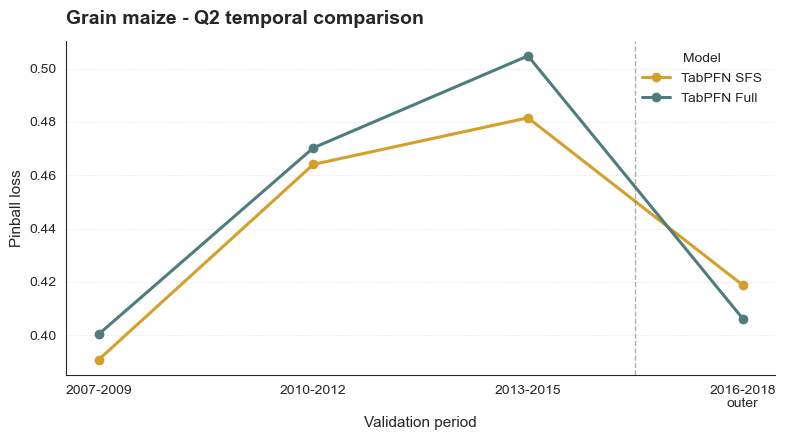

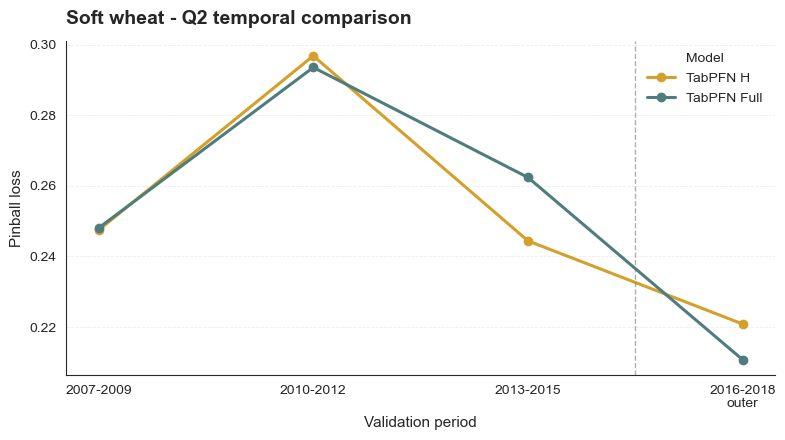

In [35]:
set_plot_style()

for crop in TABPFN_BACKTEST_CROPS:
    model_labels = [
        f"TabPFN {feature_label}"
        for feature_label in TABPFN_BACKTEST_FEATURE_SETS[crop]
    ]

    plot_data = (
        tabpfn_temporal_comparison[
            tabpfn_temporal_comparison["crop"] == crop
        ]
        .set_index("period")[model_labels]
    )

    x = range(len(plot_data))
    colors = [GOLD, TEAL]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for model_label, color in zip(model_labels, colors):
        ax.plot(
            x,
            plot_data[model_label],
            marker="o",
            linewidth=2.2,
            color=color,
            label=model_label,
        )

    ax.axvline(
        2.5,
        color=GRAY_MED,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_title(
        f"{crop} - Q2 temporal comparison",
        loc="left",
    )
    ax.set_xlabel("Validation period")
    ax.set_ylabel("Pinball loss")

    ax.set_xticks(x)
    ax.set_xticklabels([
        "2007-2009",
        "2010-2012",
        "2013-2015",
        "2016-2018\nouter",
    ])

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35,
    )

    ax.legend(title="Model")

    fig.tight_layout()
    plt.show()

### Temporal robustness interpretation

The temporal robustness check produces a clear result for **grain maize**. `TabPFN SFS` outperforms `TabPFN Full` in all three development folds, with a lower mean Q2 loss (0.4455 versus 0.4585) and slightly lower temporal variability (0.0393 versus 0.0434). The same specification also has lower mean Q1 and Q3 loss across the development folds.

This is sufficient to resolve the maize tie under the first model-selection criterion. Although `TabPFN Full` remains better on the 2016-2018 outer-validation period, its advantage there is below the predefined 5% threshold and is not supported by the earlier temporal windows. **`TabPFN SFS` is therefore retained as the preferred grain-maize specification.**

For **soft wheat**, temporal robustness is less conclusive. `TabPFN H` has the lower mean development-fold Q2 loss (0.2629 versus 0.2680) and is better in two of the three folds. `TabPFN Full`, however, has lower Q2 variability across the folds (0.0190 versus 0.0240) and remains the stronger model on the primary 2016-2018 outer validation.

The first tie-breaker therefore provides some evidence in favour of `TabPFN H`, but not a sufficiently unambiguous distinction to override the outer-validation advantage of `TabPFN Full`. The soft-wheat comparison consequently proceeds to the second criterion: **quantile behaviour**.

### Soft wheat quantile behaviour

Because temporal robustness does not fully separate the two soft-wheat finalists, the next tie-breaker examines the behaviour of their predicted quantiles.

The existing Q1 and Q3 pinball losses already show whether predictive accuracy away from the median remains coherent. Two additional diagnostics are useful:

- **empirical quantile coverage**, measuring the proportion of observed yields falling below each predicted quantile; a calibrated Q1, Q2 and Q3 should be close to 25%, 50% and 75%, respectively;
- **quantile crossing**, checking whether the expected ordering `Q1 <= Q2 <= Q3` is violated for any observation.

The empirical coverage of the central Q1-Q3 interval is also reported. Since Q1 and Q3 correspond to the 25th and 75th percentiles, this interval has a nominal coverage of 50%.

These diagnostics are calculated only for `TabPFN H` and `TabPFN Full` on the 2016-2018 outer-validation observations. No additional model specification or tuning is introduced, and the final test set remains untouched.

In [36]:
# Keep only the two soft-wheat finalists.
soft_quantile_loss = (
    tabpfn_results[
        (tabpfn_results["crop"] == "Soft wheat")
        & (
            tabpfn_results["model_label"]
            .isin(["TabPFN H", "TabPFN Full"])
        )
    ]
    [
        [
            "model_label",
            "Outer validation Q1",
            "Outer validation Q2",
            "Outer validation Q3",
        ]
    ]
)

# Display the three quantile losses side by side.
# Q2 remains the primary metric, while Q1 and Q3 help assess
# whether performance is coherent across the predicted distribution.
display(
    soft_quantile_loss
    .set_index("model_label")
)

,Outer validation Q1,Outer validation Q2,Outer validation Q3
model_label,,,
TabPFN H,0.185168,0.220857,0.186207
TabPFN Full,0.177191,0.210746,0.178223


In [37]:
# Select the soft-wheat observations from the outer-validation period.
soft_validation = outer_validation_data[
    outer_validation_data["crop_name"] == "Soft wheat"
].copy()

# Reconstruct the feature sets used by the two finalist models.
soft_feature_sets = {
    "TabPFN H": native_feature_names(
        HISTORICAL_FEATURES,
        NATIVE_FEATURE_MAP,
    ),
    "TabPFN Full": native_feature_names(
        SFS_CANDIDATE_FEATURES,
        NATIVE_FEATURE_MAP,
    ),
}

quantile_rows = []

for model_label, features in soft_feature_sets.items():

    # Recover the already-fitted TabPFN model.
    # No retraining or additional tuning is performed here.
    model_key = (
        "Soft wheat__"
        + model_label.replace(" ", "_")
    )

    model = TABPFN_MODELS[model_key]

    # Generate the three quantile predictions required
    # for the calibration and crossing diagnostics.
    q1, q2, q3 = model.predict(
        soft_validation[features],
        output_type="quantiles",
        quantiles=[0.25, 0.50, 0.75],
    )

    y = soft_validation["yield"].to_numpy()

    # A quantile crossing occurs whenever the expected ordering
    # Q1 <= Q2 <= Q3 is violated for an observation.
    crossing = (
        (q1 > q2)
        | (q2 > q3)
    )

    # Store calibration, interval and crossing diagnostics.
    quantile_rows.append({
        "model_label": model_label,

        # Empirical proportion of observed yields below each
        # predicted quantile. Ideal values are approximately
        # 25%, 50% and 75%, respectively.
        "Q1 coverage": np.mean(y <= q1),
        "Q2 coverage": np.mean(y <= q2),
        "Q3 coverage": np.mean(y <= q3),

        # Q1-Q3 defines a nominal 50% prediction interval.
        "Q1-Q3 coverage": np.mean(
            (y >= q1) & (y <= q3)
        ),

        # Average width of the central prediction interval.
        # This is descriptive and is not used as an independent
        # model-selection criterion.
        "Mean Q1-Q3 width": np.mean(q3 - q1),

        # Number and percentage of observations with
        # non-monotonic quantile predictions.
        "Crossing count": crossing.sum(),
        "Crossing %": crossing.mean() * 100,
    })

# Collect the diagnostics for the two finalist specifications.
soft_quantile_diagnostics = pd.DataFrame(
    quantile_rows
)

display(
    soft_quantile_diagnostics
    .set_index("model_label")
)

00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


,Q1 coverage,Q2 coverage,Q3 coverage,Q1-Q3 coverage,Mean Q1-Q3 width,Crossing count,Crossing %
model_label,,,,,,,
TabPFN H,0.213287,0.482517,0.737762,0.524476,0.612079,0,0
TabPFN Full,0.174825,0.433566,0.713287,0.538462,0.654522,0,0


### Soft wheat quantile-behaviour interpretation

The second tie-breaker provides a sufficiently clear distinction between the two soft-wheat finalists.

`TabPFN Full` achieves lower outer-validation pinball loss at all three quantiles, improving on `TabPFN H` by approximately 4.3% at Q1, 4.6% at Q2 and 4.3% at Q3. Its predictive advantage is therefore consistent across the estimated distribution rather than being confined to the median.

`TabPFN H` shows better empirical calibration. Its Q1, Q2 and Q3 coverages are closer to the nominal 25%, 50% and 75% levels, and its central Q1-Q3 interval is slightly narrower and closer to the nominal 50% coverage.

However, neither specification exhibits quantile crossing, and the central interval produced by `TabPFN Full` remains reasonably calibrated. The main difference is therefore a trade-off between better marginal calibration for H and consistently lower quantile loss for Full.

Given that the modelling objective is primarily predictive and that pinball loss is the reference metric for each estimated quantile, the consistent Q1, Q2 and Q3 loss advantage is considered the stronger evidence.

**`TabPFN Full` is therefore selected for soft wheat.**

The comparison is resolved at the quantile-behaviour stage, so the subsequent parsimony and reproducibility tie-breakers are not required for this crop.

## Final test evaluation: 2019-2022

The models chosen for each crop are:

- **Durum wheat:** `Linear H`;
- **Grain maize:** `TabPFN SFS`;
- **Soft wheat:** `TabPFN Full`.

The 2019-2022 test period has not contributed to feature selection, model-family comparison, hyperparameter decisions or the final choice among competing specifications.

Before the final evaluation, each selected model is refitted using all admissible observations prior to the test period, combining the original 1995-2015 development data with the 2016-2018 outer-validation observations.

The 2019-2022 block is then evaluated once. Q2 pinball loss remains the primary performance metric, while Q1 and Q3 loss and quantile diagnostics are retained to assess the broader predictive distribution.

The test results are used exclusively for final performance assessment. They do not trigger any further model selection or tuning.

### Scaling and interpretability of the final linear model

The selected `Linear H` specification uses an unregularized `QuantileRegressor` (`alpha=0`).

For an unregularized linear model, feature standardization represents an invertible reparameterization rather than a change in predictive flexibility. The scaled and unscaled formulations should therefore describe the same fitted relationship in different units.

This equivalence was verified empirically on the already-used 2016-2018 outer-validation period. For Q1, Q2 and Q3, the scaled and unscaled models produced identical pinball losses and predictions equal up to floating-point precision, with maximum absolute differences of approximately \(10^{-14}\).

Standardization is therefore omitted from the final linear implementation. This simplification does not alter predictive performance, while allowing the fitted coefficients and intercepts to be reported directly in the original feature units and the final quantile equations to be written explicitly.

No final-test observations were used for this verification.

In [38]:
# Use only durum wheat, since this is the crop for which Linear H
# has been selected as the final specification.
durum_development = development_data[
    development_data["crop_name"] == "Durum wheat"
].copy()

durum_validation = outer_validation_data[
    outer_validation_data["crop_name"] == "Durum wheat"
].copy()

scaling_check_rows = []

for quantile_name, quantile in QUANTILES.items():

    # Original specification used throughout model development.
    scaled_model = make_linear_pipeline(
        quantile
    )

    # Equivalent unregularized model fitted directly
    # on the predictors in their original units.
    unscaled_model = QuantileRegressor(
        quantile=quantile,
        alpha=0.0,
        solver="highs",
    )

    scaled_model.fit(
        durum_development[HISTORICAL_FEATURES],
        durum_development["yield"],
    )

    unscaled_model.fit(
        durum_development[HISTORICAL_FEATURES],
        durum_development["yield"],
    )

    scaled_prediction = scaled_model.predict(
        durum_validation[HISTORICAL_FEATURES]
    )

    unscaled_prediction = unscaled_model.predict(
        durum_validation[HISTORICAL_FEATURES]
    )

    # Numerical solvers can introduce extremely small differences,
    # even when the two formulations are mathematically equivalent.
    scaling_check_rows.append({
        "quantile": quantile_name,
        "Scaled loss": pinball(
            durum_validation["yield"],
            scaled_prediction,
            quantile,
        ),
        "Unscaled loss": pinball(
            durum_validation["yield"],
            unscaled_prediction,
            quantile,
        ),
        "Max prediction difference": np.max(
            np.abs(
                scaled_prediction
                - unscaled_prediction
            )
        ),
        "Predictions equal": np.allclose(
            scaled_prediction,
            unscaled_prediction,
            rtol=1e-8,
            atol=1e-8,
        ),
    })

scaling_check = pd.DataFrame(
    scaling_check_rows
)

display(
    scaling_check.set_index("quantile")
)

,Scaled loss,Unscaled loss,Max prediction difference,Predictions equal
quantile,,,,
Q1,0.16328,0.16328,2.66454e-15,True
Q2,0.195533,0.195533,1.68754e-14,True
Q3,0.181433,0.181433,7.10543e-15,True


### Scaling and final linear specification

The scaled and unscaled implementations of `Linear H` are empirically equivalent.

Across Q1, Q2 and Q3, the two formulations produce identical outer-validation pinball losses. Their predictions differ only at approximately \(10^{-14}\), which is attributable to floating-point numerical precision.

This result is also consistent with the model specification. Since `QuantileRegressor` is used without regularization (`alpha=0`), standardization changes the parameterization of the fitted linear relationship but not its predictive flexibility.

`StandardScaler` is therefore omitted from the final `Linear H` implementation. This simplification does not alter predictive performance and allows the fitted intercepts and coefficients to be interpreted directly in the original feature units.

The equivalence check was performed exclusively on the already-used 2016-2018 outer-validation period. The final 2019-2022 test set remained untouched.

In [39]:
# After model selection, the 2016-2018 outer-validation observations
# can be incorporated into the final training data.
final_training_data = pd.concat([
    development_data,
    outer_validation_data,
], ignore_index=True)

final_fit_sizes = pd.concat([
    final_training_data
    .groupby("crop_name")
    .size()
    .rename("1995-2018 final training"),

    final_test_data
    .groupby("crop_name")
    .size()
    .rename("2019-2022 final test"),
], axis=1)

display(final_fit_sizes)

,1995-2018 final training,2019-2022 final test
crop_name,,
Durum wheat,2058,373
Grain maize,2294,366
Soft wheat,2124,361


### Final model refit

The selected specifications are now refitted once using the complete 1995-2018 pre-test information.

No model-selection decision is reconsidered at this stage:

- the four historical predictors defining `Linear H` remain fixed for durum wheat;
- the previously selected SFS feature set remains fixed for grain maize;
- the complete candidate feature set remains fixed for soft wheat;
- the TabPFN inference configuration remains unchanged.

Only the amount of admissible training data increases through the inclusion of the 2016-2018 observations.

In [40]:
FINAL_MODELS = {}
FINAL_PREDICTIONS = {}
final_test_rows = []


crop = "Durum wheat"

train = final_training_data[
    final_training_data["crop_name"] == crop
].copy()

test = final_test_data[
    final_test_data["crop_name"] == crop
].copy()

FINAL_MODELS[crop] = {}
FINAL_PREDICTIONS[crop] = {}

durum_losses = {}

# Fit one independent unregularized linear model
# for each conditional quantile.
for quantile_name, quantile in QUANTILES.items():

    model = QuantileRegressor(
        quantile=quantile,
        alpha=0.0,
        solver="highs",
    )

    model.fit(
        train[HISTORICAL_FEATURES],
        train["yield"],
    )

    prediction = model.predict(
        test[HISTORICAL_FEATURES]
    )

    FINAL_MODELS[crop][quantile_name] = model
    FINAL_PREDICTIONS[crop][quantile_name] = prediction

    durum_losses[quantile_name] = pinball(
        test["yield"],
        prediction,
        quantile,
    )

final_test_rows.append({
    "crop": crop,
    "model_label": "Linear H",
    "Test Q1": durum_losses["Q1"],
    "Test Q2": durum_losses["Q2"],
    "Test Q3": durum_losses["Q3"],
})

In [41]:
# Freeze the two selected TabPFN specifications.
TABPFN_FINAL_SPECS = {
    "Grain maize": {
        "model_label": "TabPFN SFS",
        "features": native_feature_names(
            SFS_SELECTED_FEATURES["Grain maize"],
            NATIVE_FEATURE_MAP,
        ),
    },
    "Soft wheat": {
        "model_label": "TabPFN Full",
        "features": native_feature_names(
            SFS_CANDIDATE_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
    },
}


for crop, specification in TABPFN_FINAL_SPECS.items():

    train = final_training_data[
        final_training_data["crop_name"] == crop
    ].copy()

    test = final_test_data[
        final_test_data["crop_name"] == crop
    ].copy()

    features = specification["features"]

    # Use the same TabPFN configuration used during model selection.
    model = TabPFNRegressor(
        random_state=0,
        thinking_mode=False,
    )

    model.fit(
        train[features],
        train["yield"],
    )

    predictions = model.predict(
        test[features],
        output_type="quantiles",
        quantiles=[0.25, 0.50, 0.75],
    )

    q1, q2, q3 = predictions

    FINAL_MODELS[crop] = {
        "model": model,
        "features": features,
    }

    FINAL_PREDICTIONS[crop] = {
        "Q1": q1,
        "Q2": q2,
        "Q3": q3,
    }

    final_test_rows.append({
        "crop": crop,
        "model_label": specification["model_label"],
        "Test Q1": pinball(
            test["yield"],
            q1,
            0.25,
        ),
        "Test Q2": pinball(
            test["yield"],
            q2,
            0.50,
        ),
        "Test Q3": pinball(
            test["yield"],
            q3,
            0.75,
        ),
    })

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:04 Predicting... Done!


In [42]:
final_test_results = pd.DataFrame(
    final_test_rows
)

display(
    final_test_results
    .sort_values("crop")
    .set_index(["crop", "model_label"])
)

,,Test Q1,Test Q2,Test Q3
crop,model_label,,,
Durum wheat,Linear H,0.175642,0.210646,0.189819
Grain maize,TabPFN SFS,0.334758,0.375864,0.296493
Soft wheat,TabPFN Full,0.197815,0.239293,0.202605


### Final models vs naive persistence

As a final measure of predictive skill, the selected model for each crop is compared with the same **naive persistence benchmark** introduced at the beginning of the modelling workflow.

For each final-test observation, the naive forecast is the observed yield of the same province in the previous year. When that value is unavailable, the median yield of the crop in the **1995–2018 final training period** is used as fallback, preserving the same leakage-safe logic used during development.

The comparison is restricted to **Q2 pinball loss**, since the persistence benchmark is a point forecast and Q2 is the primary model-selection objective throughout the notebook.

The percentage improvement is calculated as:

$$
\text{Improvement} =
\frac{
L_{\text{naive}} - L_{\text{final}}
}{
L_{\text{naive}}
}
\times 100
$$

where lower pinball loss indicates better predictive performance.

In [43]:
# Compare each selected final model with the naive persistence benchmark
# on the untouched 2019-2022 test period.
naive_test_rows = []

for crop in CROPS:

    train = final_training_data[
        final_training_data["crop_name"] == crop
    ]

    test = final_test_data[
        final_test_data["crop_name"] == crop
    ]

    naive_prediction = (
        test["yield_lag_1"]
        .fillna(train["yield"].median())
    )

    naive_test_rows.append({
        "crop": crop,
        "Naive Test Q2": pinball(
            test["yield"],
            naive_prediction,
            QUANTILES["Q2"],
        ),
    })

In [44]:
naive_test_results = pd.DataFrame(
    naive_test_rows
)

final_vs_naive = (
    final_test_results[
        ["crop", "model_label", "Test Q2"]
    ]
    .merge(
        naive_test_results,
        on="crop",
    )
)

final_vs_naive["Improvement (%)"] = (
    (
        final_vs_naive["Naive Test Q2"]
        - final_vs_naive["Test Q2"]
    )
    / final_vs_naive["Naive Test Q2"]
    * 100
)

final_vs_naive["Final model beats naive"] = (
    final_vs_naive["Test Q2"]
    < final_vs_naive["Naive Test Q2"]
)

In [45]:
display(
    final_vs_naive
    .sort_values("crop")
    .set_index(["crop", "model_label"])
)

,,Test Q2,Naive Test Q2,Improvement (%),Final model beats naive
crop,model_label,,,,
Durum wheat,Linear H,0.210646,0.211048,0.190778,True
Grain maize,TabPFN SFS,0.375864,0.440979,14.7659,True
Soft wheat,TabPFN Full,0.239293,0.241731,1.00873,True


### Interpretation

All three selected models outperform the naive persistence benchmark on the final 2019–2022 test period, although the size of the improvement differs substantially across crops.

* **Grain maize** shows the clearest gain: the final **TabPFN SFS** model reduces Q2 pinball loss by approximately **14.8%** relative to persistence. This indicates that the model extracts substantial predictive information beyond simply carrying the previous year's provincial yield forward.
* **Soft wheat** shows a much smaller improvement of approximately **1.0%**. The **TabPFN Full** model therefore provides only a modest advantage over persistence for median prediction on the test period, despite having been selected through the chronological validation procedure.
* **Durum wheat** is essentially tied with the naive benchmark, with the final **Linear H** specification improving Q2 pinball loss by only about **0.2%**. This is consistent with the strong importance of historical yield information already observed throughout the modelling analysis: for this crop, previous-year yield alone constitutes a particularly competitive benchmark.

These results add an important perspective to the final test evaluation. Model selection identifies the strongest candidate among the specifications considered, but this does not necessarily imply a large gain over a simple persistence rule. In particular, the results suggest that the additional modelling effort produces a **material improvement in median prediction for Grain maize**, while the incremental Q2 predictive skill is limited for Soft wheat and especially for Durum wheat.

The comparison should nevertheless be interpreted specifically as a test of **median predictive skill**. The naive persistence benchmark provides only a point forecast, whereas the selected models also estimate Q1 and Q3 and therefore provide a conditional prediction interval. Consequently, the comparison does not evaluate the additional distributional information supplied by the quantile models.

### Final test performance and distribution diagnostics

The three frozen specifications have now been evaluated on the untouched 2019-2022 final test period.

The resulting pinball losses are:

- **Durum wheat - Linear H:** Q1 = 0.1756, Q2 = 0.2106, Q3 = 0.1898;
- **Grain maize - TabPFN SFS:** Q1 = 0.3348, Q2 = 0.3759, Q3 = 0.2965;
- **Soft wheat - TabPFN Full:** Q1 = 0.1978, Q2 = 0.2393, Q3 = 0.2026.

Q2 remains the primary final performance metric, while Q1 and Q3 quantify predictive accuracy in the lower and upper parts of the conditional yield distribution.

These losses are calculated from the **raw model predictions** and represent the final predictive assessment of the selected specifications. They are not altered by the post-processing introduced below.

For subsequent probabilistic interpretation, the three predicted quartiles must also define a physically and logically coherent yield distribution. The next step therefore enforces non-negative and monotonically ordered quartiles before deriving the predicted interquartile range and conditional outlier limits.

This post-processing is used only to construct coherent distributional outputs and diagnostics. It does not reopen model selection or modify the final test scores reported above.

### Quantile ordering, interquartile range and outlier limits

The three predicted quartiles are now converted into a coherent conditional yield distribution.

Although Q1, Q2 and Q3 represent increasingly higher conditional quantiles, separately estimated quantile predictions are not guaranteed to preserve this ordering for every observation. This lack of monotonicity is known as the **quantile-crossing problem** and has been studied explicitly in the quantile-regression literature (**Chernozhukov, Fernández-Val & Galichon, 2010**).

The cited work proposes **monotone rearrangement** as a principled estimator-level solution to the problem. The post-processing used in this notebook is deliberately simpler and should not be interpreted as an implementation of that estimator. Its purpose is only to impose the logical constraints required for the subsequent distributional diagnostics after the official predictive evaluation has already been completed.

Because agricultural yield cannot be negative, and because the quartiles must be monotonically ordered, the following deterministic sequential correction is applied:

$$
Q_1^{*} = \max(0, Q_1)
$$

$$
Q_2^{*} = \max(Q_1^{*}, Q_2)
$$

$$
Q_3^{*} = \max(Q_2^{*}, Q_3)
$$

so that, for every observation,

$$
0 \leq Q_1^{*} \leq Q_2^{*} \leq Q_3^{*}.
$$

The corrected quartiles are then used to estimate the conditional interquartile range:

$$
IQR^{*} = Q_3^{*} - Q_1^{*}.
$$

Tukey-style conditional outlier limits are subsequently derived as

$$
Lower = Q_1^{*} - 1.5\,IQR^{*}
$$

$$
Upper = Q_3^{*} + 1.5\,IQR^{*}.
$$

Since a negative yield threshold has no physical interpretation, the lower limit is finally truncated at zero:

$$
Lower^{*} = \max(0, Lower).
$$

A compact count of raw violations is reported before correction so that the extent of the post-processing remains visible without adding another detailed diagnostic table.

The correction affects only the distributional outputs used below. The final Q1, Q2 and Q3 pinball losses remain those calculated from the original model predictions.

In [46]:
# Collect raw final-test predictions in a single observation-level dataframe,
# while preserving the geographic and production metadata used later.
final_prediction_frames = []

for crop in CROPS:

    test = final_test_data[
        final_test_data["crop_name"] == crop
    ].copy()

    final_prediction_frames.append(
        pd.DataFrame({
            "crop": crop,
            "harvest_year": test["harvest_year"].to_numpy(),
            "PROVINCE": test["PROVINCE"].to_numpy(),
            "REGION": test["REGION"].to_numpy(),
            "MACRO_REGION": test["MACRO_REGION"].to_numpy(),
            "area": test["area"].to_numpy(),
            "production": test["production"].to_numpy(),
            "yield_true": test["yield"].to_numpy(),

            # Keep the raw model outputs unchanged for official test scoring.
            "q25_raw": np.asarray(
                FINAL_PREDICTIONS[crop]["Q1"]
            ),
            "q50_raw": np.asarray(
                FINAL_PREDICTIONS[crop]["Q2"]
            ),
            "q75_raw": np.asarray(
                FINAL_PREDICTIONS[crop]["Q3"]
            ),
        })
    )

final_predictions = pd.concat(
    final_prediction_frames,
    ignore_index=True,
)

display(final_predictions.head())

,crop,harvest_year,PROVINCE,REGION,MACRO_REGION,area,production,yield_true,q25_raw,q50_raw,q75_raw
0,Durum wheat,2019,Agrigento,Sicilia,Sicilia,21300,55030,2.58357,2.60809,2.81748,3.13489
1,Durum wheat,2020,Agrigento,Sicilia,Sicilia,21300,55030,2.58357,2.5725,2.77033,3.10711
2,Durum wheat,2021,Agrigento,Sicilia,Sicilia,21150,53050,2.50827,2.47532,2.67511,2.991
3,Durum wheat,2022,Agrigento,Sicilia,Sicilia,21800,55030,2.52431,2.41318,2.60443,2.92864
4,Durum wheat,2019,Alessandria,Piemonte,North West,1335,7849.4,5.8797,3.34612,3.53711,4.05775


In [47]:
# Count physical and ordering violations before deterministic post-processing.
raw_violation_rows = []

for crop in CROPS:

    group = final_predictions[
        final_predictions["crop"] == crop
    ]

    q1_below_zero = group["q25_raw"] < 0
    q1_above_q2 = group["q25_raw"] > group["q50_raw"]
    q2_above_q3 = group["q50_raw"] > group["q75_raw"]

    raw_violation_rows.append({
        "crop": crop,
        "Q1 below zero": int(q1_below_zero.sum()),
        "Q1 above Q2": int(q1_above_q2.sum()),
        "Q2 above Q3": int(q2_above_q3.sum()),
        "Any violation": int(
            (
                q1_below_zero
                | q1_above_q2
                | q2_above_q3
            ).sum()
        ),
    })


# Store the detailed counts, but print only a compact summary for readability.
raw_violations = pd.DataFrame(raw_violation_rows)

crop_summary = ", ".join(
    f"{row['crop']}: {row['Any violation']}"
    for _, row in raw_violations.iterrows()
)

print(
    f"Raw quantile-ordering violations: "
    f"{raw_violations['Any violation'].sum()}/"
    f"{len(final_predictions)} rows"
)

print(
    f"{crop_summary} | "
    f"Q1 < 0: {raw_violations['Q1 below zero'].sum()}, "
    f"Q1 > Q2: {raw_violations['Q1 above Q2'].sum()}, "
    f"Q2 > Q3: {raw_violations['Q2 above Q3'].sum()}"
)

Raw quantile-ordering violations: 5/1100 rows
Durum wheat: 5, Soft wheat: 0, Grain maize: 0 | Q1 < 0: 0, Q1 > Q2: 4, Q2 > Q3: 1


**Observation.** Only 5 of the 1,100 final-test rows (0.45%) violate the raw quantile-ordering constraints, all for durum wheat. No Q1 prediction is negative, so the consistency correction affects only a very small fraction of the final predictions.

In [48]:
# Enforce the physical lower bound for Q1.
final_predictions["q25"] = (
    final_predictions["q25_raw"]
    .clip(lower=0.0)
)

final_predictions["q50"] = final_predictions["q50_raw"]
final_predictions["q75"] = final_predictions["q75_raw"]


# Enforce Q1 <= Q2 <= Q3; the utility also derives the IQR
# and the Tukey-style lower and upper limits.
final_predictions = add_quantile_limits(
    final_predictions
)

### Final distributional diagnostics

The corrected quartiles provide a coherent ordered set of conditional quantile estimates for every final-test observation.

Calibration is evaluated through the empirical proportion of observed yields falling below Q1, Q2 and Q3. For well-calibrated quantiles these proportions should be close to 25%, 50% and 75%, respectively. The central Q1-Q3 interval should contain approximately 50% of the observed outcomes.

The predicted IQR measures the observation-specific spread between Q1 and Q3.
Its median is reported as a robust summary of the typical conditional dispersion within each crop.

Finally, observed yields falling beyond the Tukey-style conditional limits are counted as low or high outliers.

These diagnostics use the corrected quantiles. The official final-test pinball losses remain those calculated from the raw model predictions.

In [49]:
# Flag observed yields outside the predicted Tukey-style limits.
final_predictions["low_outlier"] = (
    final_predictions["yield_true"]
    < final_predictions["low_limit"]
)

final_predictions["high_outlier"] = (
    final_predictions["yield_true"]
    > final_predictions["high_limit"]
)

final_predictions["any_outlier"] = (
    final_predictions["low_outlier"]
    | final_predictions["high_outlier"]
)


# Summarize calibration, typical interval width and observed outlier frequency
# separately for each crop.
final_diagnostic_rows = []

for crop in CROPS:

    group = final_predictions[
        final_predictions["crop"] == crop
    ]

    y = group["yield_true"]

    q1 = group["q25"]
    q2 = group["q50_corrected"]
    q3 = group["q75_corrected"]

    final_diagnostic_rows.append({
        "crop": crop,
        "Test rows": len(group),

        # Coverage is the empirical share of observed yields below each quantile.
        "Empirical Q1 coverage (%)": (
            (y <= q1).mean() * 100
        ),

        "Empirical Q2 coverage (%)": (
            (y <= q2).mean() * 100
        ),

        "Empirical Q3 coverage (%)": (
            (y <= q3).mean() * 100
        ),

        "Inside Q1-Q3 (%)": (
            ((y >= q1) & (y <= q3)).mean() * 100
        ),

        # The median gives a robust summary of the typical predicted spread.
        "Median predicted IQR": (
            group["predicted_iqr"].median()
        ),

        "Low outliers": int(
            group["low_outlier"].sum()
        ),

        "High outliers": int(
            group["high_outlier"].sum()
        ),

        "Outlier share (%)": (
            group["any_outlier"].mean() * 100
        ),
    })


final_quantile_diagnostics = pd.DataFrame(
    final_diagnostic_rows
)

display(
    final_quantile_diagnostics
    .set_index("crop")
    .round(2)
)

,Test rows,Empirical Q1 coverage (%),Empirical Q2 coverage (%),Empirical Q3 coverage (%),Inside Q1-Q3 (%),Median predicted IQR,Low outliers,High outliers,Outlier share (%)
crop,,,,,,,,,
Durum wheat,373,26.81,61.13,79.89,53.08,0.6,6,12,4.83
Soft wheat,361,21.88,46.81,72.3,50.42,0.64,11,16,7.48
Grain maize,366,18.31,42.9,69.4,51.09,1.1,11,8,5.19


**Observation.** The central Q1-Q3 coverage is close to its nominal 50% for all three crops (53.08% for durum wheat, 50.42% for soft wheat and 51.09% for grain maize). Marginal calibration is less uniform: durum-wheat Q2 coverage is relatively high (61.13%), while grain-maize Q2 coverage is relatively low (42.90%); soft wheat is closer to the nominal median level (46.81%). Final-test outlier shares remain between 4.83% and 7.48%.

### Performance across final-test years

The aggregate 2019-2022 Q2 loss is complemented by a year-specific diagnostic.

The calculation continues to use the **raw Q2 model prediction**, consistently with the primary final-test score. The corrected median is reserved for the subsequent distributional and outlier interpretation.

This check does not compare alternative models. It shows whether final predictive performance is broadly distributed across the four test years or driven by particularly favourable or difficult individual seasons.

In [50]:
# Recompute the primary Q2 loss inside each individual final-test year.
# The official overall test score remains the loss across all 2019-2022 rows.
yearly_rows = []

for crop in CROPS:

    group = final_predictions[
        final_predictions["crop"] == crop
    ]

    for year in sorted(
        group["harvest_year"].unique()
    ):

        year_data = group[
            group["harvest_year"] == year
        ]

        yearly_rows.append({
            "crop": crop,
            "harvest_year": year,
            # Retain the yearly sample size for possible balance checks.
            "n": len(year_data),

            "Mean Q2 pinball loss": pinball(
                year_data["yield_true"],
                year_data["q50_raw"],
                0.50,
            ),
        })


final_yearly_q2 = pd.DataFrame(
    yearly_rows
)


display(
    final_yearly_q2
    .pivot(
        index="crop",
        columns="harvest_year",
        values="Mean Q2 pinball loss",
    )
)

harvest_year,2019,2020,2021,2022
crop,,,,
Durum wheat,0.237986,0.151382,0.231177,0.221744
Grain maize,0.345613,0.373995,0.330549,0.453257
Soft wheat,0.239408,0.182063,0.296566,0.243072


**Observation.** Predictive difficulty varies by crop and year rather than deteriorating uniformly through the test period. Grain maize records its highest Q2 loss in 2022, soft wheat in 2021, while durum wheat performs particularly well in 2020.

### Outer validation and final-test performance

The final Q2 result is compared with the Q2 loss previously obtained on the 2016-2018 outer-validation period for the same selected specification.

This comparison is only descriptive: the final models have been refitted using all admissible information through 2018, whereas the outer-validation results were produced by models trained only on the earlier development period.

The comparison therefore indicates whether predictive difficulty changes substantially between the two successive periods, it is not a measure  deterioration of an identical fitted model.

In [51]:
# Retrieve the outer-validation Q2 score for each already frozen specification.
selected_model_labels = {
    "Durum wheat": "Linear H",
    "Grain maize": "TabPFN SFS",
    "Soft wheat": "TabPFN Full",
}


outer_selected_rows = []

for crop, model_label in selected_model_labels.items():

    if model_label.startswith("TabPFN"):

        outer_q2 = tabpfn_results.loc[
            (tabpfn_results["crop"] == crop)
            & (tabpfn_results["model_label"] == model_label),
            "Outer validation Q2",
        ].iloc[0]

    else:

        outer_q2 = outer_validation_results.loc[
            (outer_validation_results["crop"] == crop)
            & (outer_validation_results["model_label"] == model_label),
            "Outer validation Q2",
        ].iloc[0]

    outer_selected_rows.append({
        "crop": crop,
        "model_label": model_label,
        "Validation Q2": outer_q2,
    })


outer_vs_test = (
    pd.DataFrame(outer_selected_rows)
    .merge(
        final_test_results[
            ["crop", "model_label", "Test Q2"]
        ],
        on=["crop", "model_label"],
        how="left",
    )
)

# Positive values indicate higher loss on the final test; negative values
# indicate lower final-test loss than on outer validation.
outer_vs_test["Test - validation"] = (
    outer_vs_test["Test Q2"]
    - outer_vs_test["Validation Q2"]
)


display(
    outer_vs_test
    .set_index(["crop", "model_label"])
)

,,Validation Q2,Test Q2,Test - validation
crop,model_label,,,
Durum wheat,Linear H,0.195533,0.210646,0.0151123
Grain maize,TabPFN SFS,0.418836,0.375864,-0.0429721
Soft wheat,TabPFN Full,0.210746,0.239293,0.0285468


**Observation.** Relative to outer validation, final-test Q2 loss increases modestly for durum wheat (+0.015) and soft wheat (+0.029), while it decreases for grain maize (-0.043). These differences are reported as temporal generalization evidence and do not alter the frozen model choices.

### Geographic distribution of final-test outliers

Region information is retained as observation metadata to support a compact geographic diagnostic.

The table below does not re-evaluate or compare models. It simply identifies whether the province-year observations falling outside the estimated Tukey-style limits are concentrated in particular regions.

Only regions containing at least one final-test outlier are displayed.

In [52]:
# Summarize the final-test outliers by crop and region.
regional_outlier_summary = (
    final_predictions
    .groupby(
        ["crop", "REGION"],
        as_index=False,
    )
    .agg(
        test_rows=("any_outlier", "size"),
        low_outliers=("low_outlier", "sum"),
        high_outliers=("high_outlier", "sum"),
        outliers=("any_outlier", "sum"),
    )
)

# Use the available crop-region test rows as the denominator.
regional_outlier_summary["Outlier share (%)"] = (
    regional_outlier_summary["outliers"]
    / regional_outlier_summary["test_rows"]
    * 100
)

# Keep only regions where at least one outlier is observed.
regional_outlier_summary = (
    regional_outlier_summary[
        regional_outlier_summary["outliers"] > 0
    ]
    .sort_values(
        ["crop", "outliers"],
        ascending=[True, False],
    )
)


display(
    regional_outlier_summary
    .set_index(["crop", "REGION"])
)

test_rows  low_outliers  high_outliers  outliers  Outlier share (%)
crop        REGION                                                                                    
Durum wheat Lazio                         20             2              2         4                 20
            Piemonte                      25             0              4         4                 16
            Toscana                       36             1              2         3            8.33333
            Emilia-Romagna                36             0              2         2            5.55556
            Lombardia                     38             0              2         2            5.26316
            Veneto                        26             2              0         2            7.69231
            Sardegna                      16             1              0         1               6.25
Grain maize Veneto                        28             6              0         6            21.4286
            Piemonte                      32             0              3         3              9.375
            Toscana                       40             3              0         3                7.5
            Emilia-Romagna                36             2              0         2            5.55556
            Marche                        20             0              2         2                 10
            Abruzzo                       16             0              1         1               6.25
            Trentino-Alto Adige            6             0              1         1            16.6667
            Umbria                         8             0              1         1               12.5
Soft wheat  Lombardia                     48             0              5         5            10.4167
            Sardegna                      15             1              3         4            26.6667
            Veneto                        28             1              3         4            14.2857
            Friuli-Venezia Giulia         13             3              0         3            23.0769
            Lazio                         20             1              1         2                 10
            Molise                         8             2              0         2                 25
            Toscana                       38             1              1         2            5.26316
            Abruzzo                       16             1              0         1               6.25
            Campania                      16             0              1         1               6.25
            Marche                        20             1              0         1                  5
            Sicilia                        6             0              1         1            16.6667
            Trentino-Alto Adige            6             0              1         1            16.6667

**Observation.** Final-test outliers are distributed across several regions rather than being confined to a single geographic area. Some local concentrations are visible, but percentages based on relatively few crop-region observations should be interpreted cautiously.

### Final durum-wheat quantile equations

Durum wheat is the only crop whose final specification is an explicit linear quantile model.

Because the final `Linear H` implementation is fitted directly on the original historical predictors, its coefficients can be reported without transforming them back from standardized units.

A separate equation is estimated for Q1, Q2 and Q3. These equations represent the raw model outputs. The deterministic non-negativity and quantile-ordering correction is applied only afterwards when constructing the distributional outputs.

In [53]:
# Extract the final linear coefficients directly in the original feature units.
durum_coefficient_rows = []

for quantile_name in QUANTILES:

    model = FINAL_MODELS[
        "Durum wheat"
    ][quantile_name]

    # Build one coefficient row for each fitted quantile equation.
    row = {
        "quantile": quantile_name,
        "intercept": model.intercept_,
    }

    for feature, coefficient in zip(
        HISTORICAL_FEATURES,
        model.coef_,
    ):
        row[feature] = coefficient

    durum_coefficient_rows.append(row)


durum_coefficients = pd.DataFrame(
    durum_coefficient_rows
).set_index("quantile")


display(durum_coefficients)

,intercept,yield_lag_1_zero_filled,yield_lag_1_missing,yield_median_province_rolling,yield_median_region_rolling
quantile,,,,,
Q1,0.0810483,0.419756,2.24535,0.364999,0.120905
Q2,0.0870251,0.529864,2.9946,0.357626,0.0950671
Q3,0.348408,0.36696,3.75159,0.436079,0.191696


In [54]:
# Format the three fitted regressions as directly readable equations.
for quantile_name in QUANTILES:

    model = FINAL_MODELS[
        "Durum wheat"
    ][quantile_name]

    equation = f"{model.intercept_:.4f}"

    for feature, coefficient in zip(
        HISTORICAL_FEATURES,
        model.coef_,
    ):

        # Print the sign separately so the equation remains easy to read.
        sign = "+" if coefficient >= 0 else "-"

        equation += (
            f" {sign} "
            f"{abs(coefficient):.4f} * {feature}"
        )

    print(
        f"{quantile_name}: yield = {equation}"
    )

Q1: yield = 0.0810 + 0.4198 * yield_lag_1_zero_filled + 2.2454 * yield_lag_1_missing + 0.3650 * yield_median_province_rolling + 0.1209 * yield_median_region_rolling
Q2: yield = 0.0870 + 0.5299 * yield_lag_1_zero_filled + 2.9946 * yield_lag_1_missing + 0.3576 * yield_median_province_rolling + 0.0951 * yield_median_region_rolling
Q3: yield = 0.3484 + 0.3670 * yield_lag_1_zero_filled + 3.7516 * yield_lag_1_missing + 0.4361 * yield_median_province_rolling + 0.1917 * yield_median_region_rolling


**Observation.** The final durum-wheat specification is fully auditable as three explicit linear equations. Because the four inputs have different scales and include a binary missingness indicator, coefficient magnitudes should not be interpreted as standardized feature importance.

### Interpreting the Durum Wheat linear quantile models

For Durum Wheat, the selected linear specification uses only historical yield information, combining the previous-year observation with rolling yield levels at province and macro-regional scale. The three fitted quantile equations are:

$$
\hat{y}_{Q1}
=
0.0810
+ 0.4198 \cdot \mathrm{yield\_lag\_1\_zero\_filled}
+ 2.2454 \cdot \mathrm{yield\_lag\_1\_missing}
+ 0.3650 \cdot \mathrm{yield\_median\_province\_rolling}
+ 0.1209 \cdot \mathrm{yield\_median\_region\_rolling}
$$

$$
\hat{y}_{Q2}
=
0.0870
+ 0.5299 \cdot \mathrm{yield\_lag\_1\_zero\_filled}
+ 2.9946 \cdot \mathrm{yield\_lag\_1\_missing}
+ 0.3576 \cdot \mathrm{yield\_median\_province\_rolling}
+ 0.0951 \cdot \mathrm{yield\_median\_region\_rolling}
$$

$$
\hat{y}_{Q3}
=
0.3484
+ 0.3670 \cdot \mathrm{yield\_lag\_1\_zero\_filled}
+ 3.7516 \cdot \mathrm{yield\_lag\_1\_missing}
+ 0.4361 \cdot \mathrm{yield\_median\_province\_rolling}
+ 0.1917 \cdot \mathrm{yield\_median\_region\_rolling}
$$

The three equations reveal a consistent structure. **Recent local yield history provides the strongest short-term signal**, particularly at the conditional median, where the coefficient of the previous-year yield reaches (0.5299). The rolling provincial median is also substantial at every quantile, while the regional rolling median provides a smaller but persistent broader geographical component. At Q3, both geographical historical terms receive relatively larger coefficients, suggesting that high-yield outcomes are particularly associated with provinces and regions characterised by persistently favourable production levels.

The coefficient of `yield_lag_1_missing` should be interpreted separately. This variable identifies observations for which the previous-year yield was unavailable and replaced by zero. Its comparatively large coefficient therefore acts mainly as a correction to this missing-value representation rather than as an agronomic driver.

This result is especially interesting when compared with the earlier bivariate analysis. Durum Wheat showed the **strongest environmental associations among the three crops**. The leading climatic signals were mainly negative correlations with **evapotranspiration, wind speed and solar radiation**. Evapotranspiration and radiation during the **planting / early vegetative phase** were particularly prominent, while wind speed appeared among the strongest associations across several crop phases. **Temperature and vapour pressure** also tended to correlate negatively with yield, whereas **frost-related indicators during the vegetative / reproductive phase** showed positive associations.

However, these climatic relationships were accompanied by a pronounced geographical structure. Durum Wheat yield itself showed a persistent macro-regional ordering: **North East and North West generally occupied the highest-yield range, Center an intermediate position, and South, Sicilia and especially Sardegna the lower part of the distribution**. The climatic predictors examined in the bivariate analysis also displayed marked differences between geographical areas rather than behaving as spatially homogeneous variables. Consequently, part of their strong pooled correlation with yield can reflect the fact that different Italian production areas simultaneously have **different climatic regimes and different long-run yield levels**.

This provides a plausible interpretation of why explicit climate variables are absent from the final historical model without implying that climate is unimportant. The two rolling geographical terms, particularly `yield_median_province_rolling`, can act as compact summaries of persistent local conditions. They may therefore indirectly capture part of the same spatial structure represented by evapotranspiration, radiation, temperature, wind and frost exposure, together with other relatively stable territorial characteristics such as soils, production systems and agronomic practices.

The selected model can consequently be interpreted as combining **short-term persistence** (`yield_lag_1`) with a **local structural baseline** (`yield_median_province_rolling`) and a weaker **broader geographical baseline** (`yield_median_region_rolling`). The modelling result therefore does not indicate that climatic conditions are irrelevant to Durum Wheat yield. Rather, it suggests that, for out-of-time prediction, much of the useful information contained in the climate variables is already embedded in the historical geographical pattern of yield, leaving relatively limited incremental predictive information for the climate variables once this structure is known.

For this reason, all coefficients should remain interpreted as **predictive rather than causal**.


### Interpreting the TabPFN models with SHAP values

The final TabPFN models for **Soft wheat** and **Grain maize** are less directly interpretable than the linear Durum-wheat specification. Their behaviour is therefore explored through **SHAP (SHapley Additive exPlanations)**, a feature-attribution framework that expresses a model prediction in terms of contributions assigned to its input features (**Lundberg & Lee, 2017**).

The analysis is applied only after model selection and final refitting. It does not influence model choice or test performance: its purpose is purely interpretative.

For TabPFN, the Shapley-value computation is performed through the `shapiq`-based utilities exposed by `tabpfn_extensions`. `shapiq` provides algorithms for estimating Shapley values and higher-order Shapley interactions under finite computational budgets (**Muschalik et al., 2024**). In this notebook the explainer is explicitly configured with `index="SV"` and `max_order=1`, so the analysis concerns standard first-order **Shapley feature attributions**, not higher-order interaction values.

Because the Soft-wheat model uses the complete predictor set, while the Grain-maize model uses the smaller SFS-selected subset, Shapley values are estimated on a small reproducible sample of final-test observations rather than computed exhaustively. The resulting beeswarm plots summarize both the relative importance of the strongest predictors and the direction of their contribution to TabPFN predictions.

00:00 Predicting... |

00:02 Predicting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!


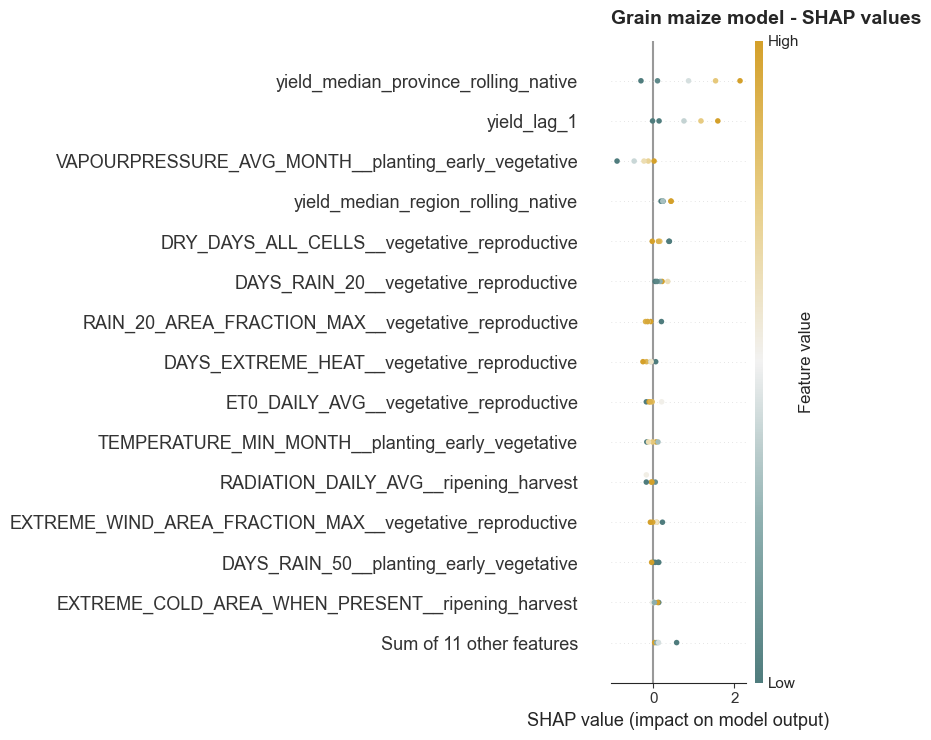

00:00 Predicting... \

00:04 Predicting... Done!
00:00 Predicting... \

00:04 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
00:00 Predicting... \

00:04 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


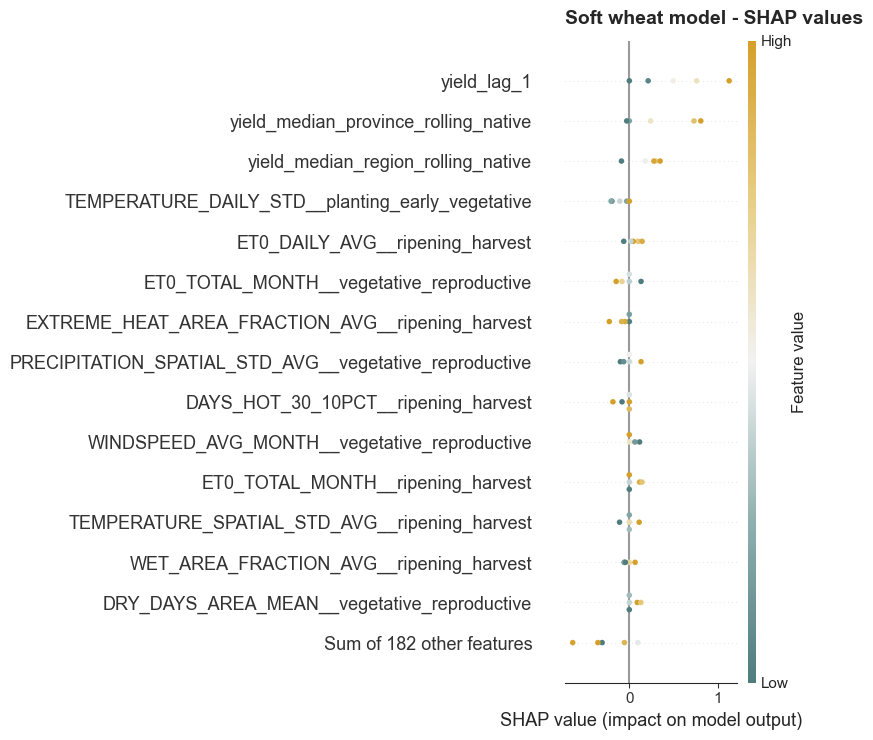

In [55]:
# SHAP interpretation of the two selected TabPFN models.
SHAP_CROPS = [
    "Grain maize",
    "Soft wheat",
]

N_SHAP_ROWS = 5
SHAP_BUDGET = 256

TABPFN_SHAP = {}


for crop in SHAP_CROPS:

    model = FINAL_MODELS[crop]["model"]
    features = FINAL_MODELS[crop]["features"]

    train = final_training_data[
        final_training_data["crop_name"] == crop
    ].copy()

    test = final_test_data[
        final_test_data["crop_name"] == crop
    ].copy()

    # Keep the interpretation deliberately small and reproducible.
    X_explain = (
        test[features]
        .sample(
            n=min(N_SHAP_ROWS, len(test)),
            random_state=0,
        )
    )

    # shapiq works internally with NumPy arrays, while the TabPFN client
    # requires the same named columns used when the model was fitted.
    wrapped_model = NamedColumnsWrapper(
        model,
        features,
    )

    # The training predictors define the reference distribution used
    # when estimating the contribution of each feature.
    explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
        model=wrapped_model,
        data=train[features],
        index="SV",
        max_order=1,
        random_state=0,
    )

    # Approximate Shapley values with a fixed computational budget.
    explanation = shapiq_to_shap_explanation(
        explainer,
        X_explain,
        budget=SHAP_BUDGET,
        feature_names=features,
    )

    TABPFN_SHAP[crop] = explanation

    # Beeswarm: global importance together with direction of contribution.
    shap.plots.beeswarm(
        explanation,
        max_display=15,
        color=diverging_cmap,
        show=False,
    )

    plt.title(
        f"{crop} model - SHAP values",
        loc="left",
    )
    plt.tight_layout()
    plt.show()

### Interpretation of the final TabPFN models

The SHAP analysis provides a complementary view of how the final TabPFN models generate their predictions. In both plots, positive SHAP values increase the predicted yield and negative values decrease it, while colour represents the original feature value, from **low (teal)** to **high (gold)**.

#### Grain maize

The Grain-maize model shows a relatively **concentrated predictive structure**, consistent with its use of the smaller SFS-selected feature set.

The dominant predictors are the recent and local yield-history variables. In particular, higher values of `yield_median_province_rolling_native` and `yield_lag_1` produce the largest positive contributions to predicted yield, followed by the rolling regional median. This indicates that TabPFN relies strongly on the persistence of local production levels and on the spatial structure of historical yield.

Climate variables provide a second layer of information. Several of their effects are directionally coherent:

* higher vapour pressure during the planting and early vegetative phase is associated with higher predictions, whereas low values contribute negatively;
* a larger number of dry days during the vegetative-reproductive phase tends to reduce predicted yield;
* a greater spatial extent of heavy rainfall and stronger extreme-heat conditions during the same phase generally contribute negatively;
* temperature, radiation and evapotranspiration variables have smaller, more localised effects.

The remaining 11 predictors collectively contribute much less than the leading variables. Overall, the Grain-maize TabPFN therefore behaves as a relatively parsimonious model: **historical yield and local spatial persistence define the main expected yield level, while a limited number of climatic indicators adjust that expectation according to the conditions experienced during agronomically relevant phases.**

#### Soft wheat

The Soft-wheat model presents a more distributed predictive structure. Although it is fitted on the **full predictor set**, the strongest individual contributions are again associated with yield history. High `yield_lag_1`, high provincial rolling yield and high regional rolling yield all clearly increase the prediction, confirming that recent production performance and geographical persistence form the main baseline of the model.

Beyond this baseline, however, the SHAP values reveal a recognisable set of climatic conditions associated with more favourable or unfavourable predictions.

* During **planting and early vegetative development**, low values of daily temperature variability tend to contribute negatively, whereas higher values are closer to neutral or mildly favourable. A similar directional pattern appears for some atmospheric variables, suggesting that early-season thermal conditions help refine the expected yield established from historical information.

* During the **vegetative-reproductive phase**, water-demand and moisture-related variables appear particularly relevant. Higher total evapotranspiration tends to shift predictions downward, suggesting less favourable conditions when cumulative atmospheric water demand becomes stronger. At the same time, greater spatial variability in precipitation tends to be associated with more positive contributions. This does not necessarily imply that heterogeneous rainfall is intrinsically beneficial, but indicates that the model distinguishes between different spatial configurations of water availability rather than responding only to total rainfall.

The **ripening and harvest phase** shows the clearest climatic asymmetry. Greater exposure to extreme heat and a larger number of hot days are associated with negative SHAP contributions, making **late-season heat stress one of the most clearly unfavourable climatic signals in the model**. Conversely, higher average evapotranspiration, greater wet-area fraction and, to a lesser extent, greater spatial temperature variability tend to appear on the positive side of the prediction. These effects are weaker than the historical-yield signal, but together they suggest that the model favours ripening conditions that avoid widespread heat stress while retaining sufficient spatial moisture availability.

Some lower-ranked variables show more ambiguous or locally inconsistent directions. This is expected in a model using nearly two hundred predictors, where correlated climatic descriptors can share information and where individual contributions may depend on combinations of other variables.

The final **“Sum of 182 other features”** row is therefore particularly informative. It shows how the full Soft-wheat model does not rely on one additional dominant climatic predictor. Instead, a substantial part of its environmental adjustment is distributed across a long tail of individually small effects. The model can consequently be interpreted as having a **strong historical and geographical backbone, refined by a broad set of climatic corrections whose cumulative contribution is meaningful even when each individual variable is relatively weak.**

#### Overall interpretation

The two TabPFN models therefore reach their predictions through related but distinct mechanisms.

For both crops, **spatio-temporal persistence of yield is the strongest source of predictive information**: recent yield and provincial/regional rolling statistics establish the main expected production level.

Climate then modifies this baseline.

For Grain maize, this climatic adjustment is comparatively concentrated: a limited number of selected indicators provide clear corrections around the historical baseline.

For Soft wheat, the adjustment is much more distributed, but still interpretable in agronomic terms. The model tends to associate **late-season heat stress and stronger cumulative water demand with lower yield predictions**, while conditions characterised by lower heat exposure and more favourable moisture-related signals tend to shift predictions upward. Other climatic descriptors contribute through smaller and more context-dependent corrections.

This helps reconcile the modelling results with the earlier exploratory analysis. Strong bivariate relationships between yield and climatic variables do not imply that climate must dominate a multivariate predictive model. Part of the same information is already embedded in persistent geographical differences and historical yield levels, while TabPFN can exploit the remaining climatic information through nonlinear and interacting adjustments.

The resulting hierarchy can therefore be summarised as:

**local and regional yield history establish the baseline; climatic conditions refine it.**

This mechanism is relatively compact for Grain maize and substantially more distributed for Soft wheat, reflecting the different feature sets retained by their final models.

> Because the SHAP computation is based on a small reproducible subset of test observations, the strongest and most consistent patterns should be interpreted as the main model mechanisms, while the precise direction of lower-ranked individual features should not be over-interpreted.

### National aggregation of province-level predictions

The primary modelling output remains the province-level prediction.

For an aggregate national view, provincial predicted yields cannot be averaged directly because cultivated areas differ substantially across provinces.
Instead, each predicted yield is first converted into implied production:

$$
\widehat{P}_{i,t} = A_{i,t}\widehat{Y}_{i,t}
$$

where \(A_{i,t}\) is cultivated area.

Predicted production is then summed across provinces and national yield is reconstructed as total predicted production divided by total cultivated area.

The same procedure is applied to Q1, Q2, Q3 and the two outlier limits.

The resulting national Q1, Q2 and Q3 series should be interpreted as **area-weighted aggregates of province-level quantile forecasts**. They are
not the quantiles of a separately estimated national predictive distribution.

In [56]:
# Convert province-level yield forecasts into area-weighted national aggregates.
province_level_predictions, national_predictions = (
    aggregate_national_predictions(
        final_predictions
    )
)


# Keep the observed yield, central quantiles and Tukey-style limits
# in the compact national summary.
national_columns = [
    "crop",
    "harvest_year",
    "yield_real",
    "yield_low_limit",
    "yield_q1",
    "yield_q2",
    "yield_q3",
    "yield_high_limit",
    "low_outlier",
    "high_outlier",
]


display(
    national_predictions[
        national_columns
    ]
)

,crop,harvest_year,yield_real,yield_low_limit,yield_q1,yield_q2,yield_q3,yield_high_limit,low_outlier,high_outlier
0,Durum wheat,2019,3.14956,2.17093,2.99413,3.25057,3.54294,4.36614,False,False
1,Durum wheat,2020,3.21752,2.12251,2.95304,3.19968,3.50673,4.33726,False,False
2,Durum wheat,2021,3.31034,2.18459,3.00769,3.26686,3.55691,4.38073,False,False
3,Durum wheat,2022,2.99215,2.25464,3.0751,3.34612,3.62208,4.44255,False,False
4,Grain maize,2019,9.95365,8.04447,9.52399,10.0499,10.5103,11.9898,False,False
5,Grain maize,2020,11.232,7.50954,9.47363,10.1187,10.7833,12.7477,False,False
6,Grain maize,2021,10.2963,7.40302,9.67424,10.4858,11.1886,13.4602,False,False
7,Grain maize,2022,8.30209,6.15163,8.53742,9.436,10.1279,12.5137,False,False
8,Soft wheat,2019,5.14129,4.01988,5.15582,5.54044,5.91312,7.04907,False,False
9,Soft wheat,2020,5.33158,3.42124,4.60149,5.01786,5.38833,6.56859,False,False


**Observation.** At the national aggregate level, none of the 12 crop-year observed yields falls beyond the corresponding Tukey-style limits. The largest visible median discrepancy occurs for grain maize in 2022, consistent with the higher Q2 loss observed for that year.

### National yield representation

The final plots translate the province-level model outputs into an area-weighted national representation.

For each crop, observed national yield is shown together with the aggregated median estimate, the Q1-Q3 band and the corresponding Tukey-style limits.

These plots provide an intuitive summary of the final model outputs but do not replace the province-level pinball-loss evaluation used to assess predictive performance.

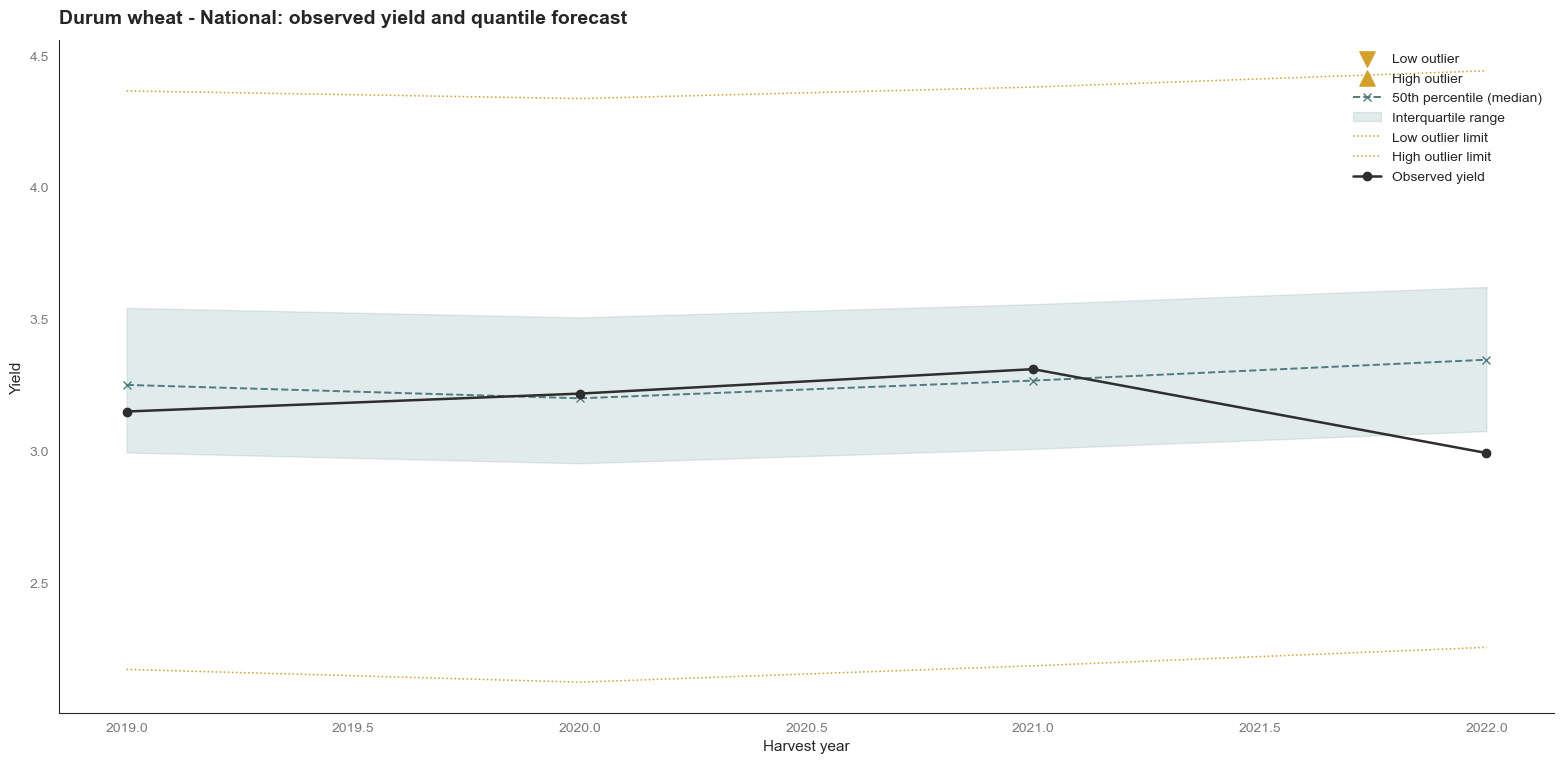

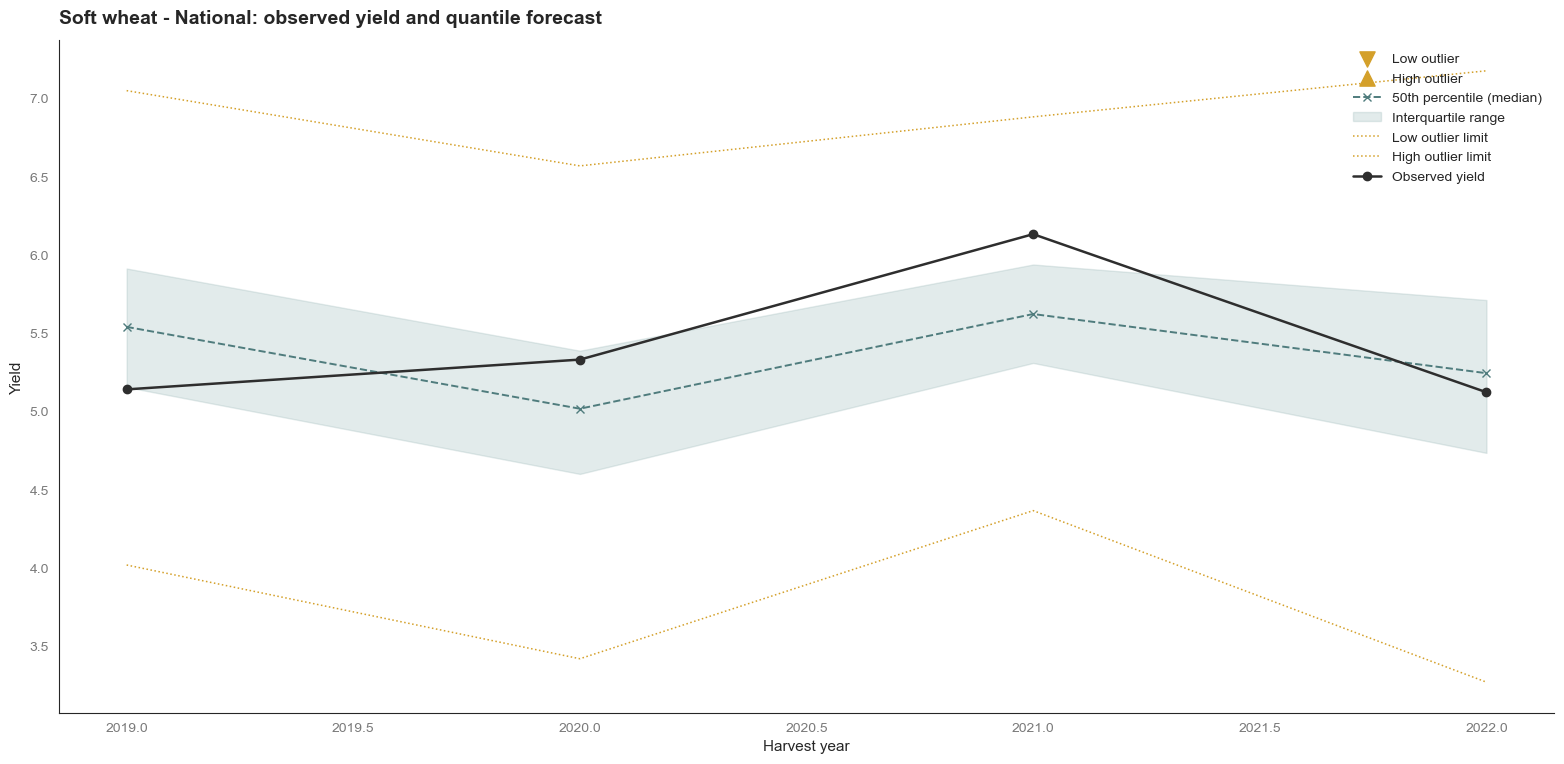

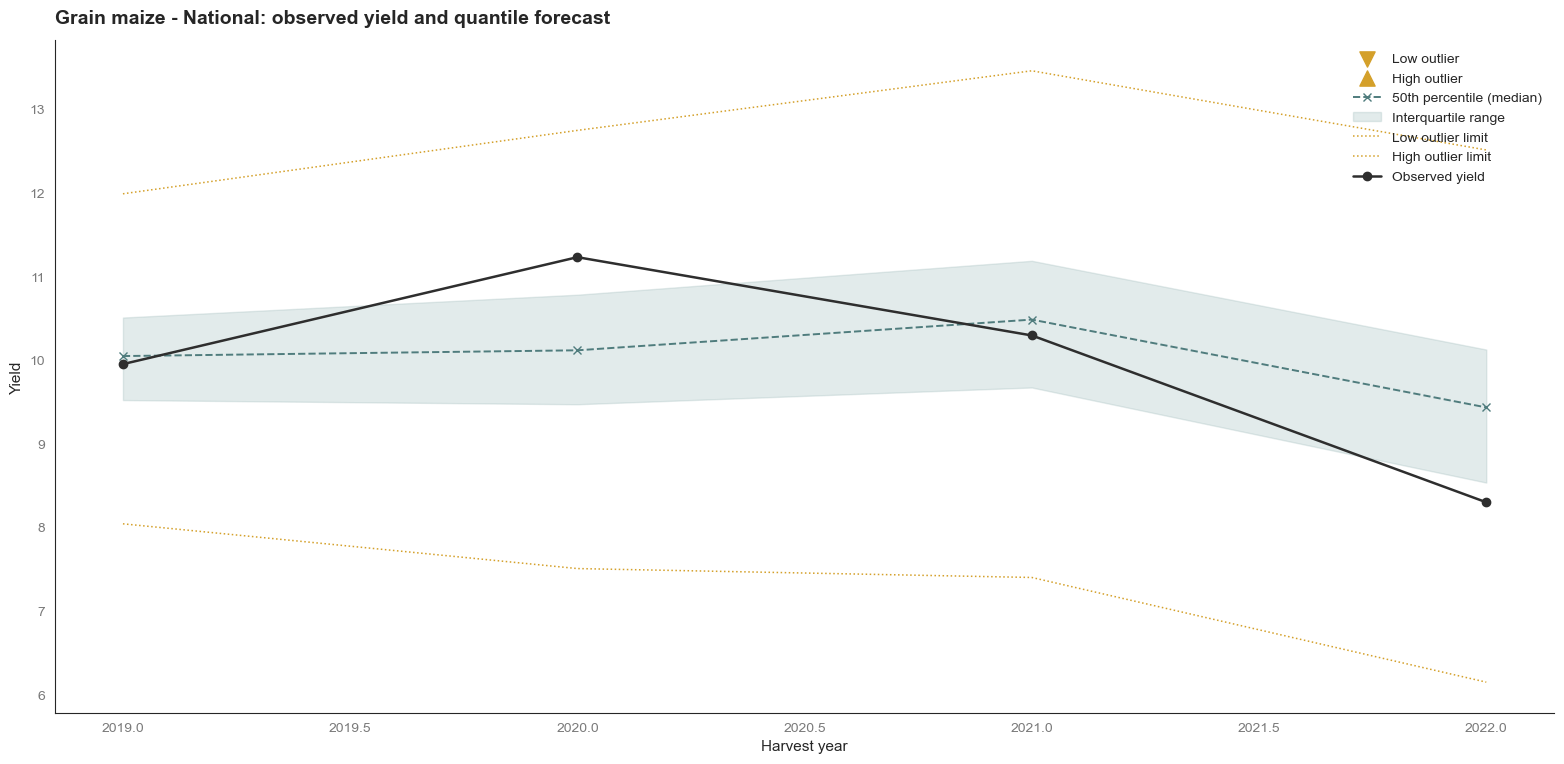

In [57]:
# Produce one national summary plot for each crop.
for crop in CROPS:

    plot_national_quantile_forecast(
        national_predictions,
        crop,
    )

### Selected territorial views

National aggregation provides a compact view of model performance, but it can conceal substantial geographical differences in both crop relevance and yield behaviour.

The EDA showed that the three crops have markedly different geographical structures. The territorial views below are therefore selected by jointly considering:

- the distribution of cultivated area across Italian macro-regions;
- the geographical yield patterns observed during the EDA;
- the usefulness of contrasting areas with different agricultural relevance or yield levels.

The same set of areas is not imposed on every crop, since their geographical production structures are inherently different.

For **durum wheat**, the northern macro-regions are compared with the Center. Durum wheat occupies a substantially larger cultivated area in Central Italy than in the North, while the two territories also represent distinct environmental and yield contexts.

For **soft wheat**, North East and Center are retained as the primary comparison. North East is particularly relevant because it combines the largest cultivated area with the highest observed yield levels. North West can additionally be inspected as a secondary northern reference.

For **grain maize**, North West and North East are considered jointly because maize cultivation is strongly concentrated in northern Italy. Center and Sardegna are retained as contrasting cases: their cultivated area is considerably smaller, while their observed yield levels are comparatively closer to those of the North than the geographical distribution of cultivated area alone would suggest.

These are not separate territorial models. Province-level predictions from the final models are aggregated using cultivated area, following the same procedure used for the national forecasts.

****************************************************************************************************
DURUM WHEAT CULTIVATED AREA
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max
MACRO_REGION,,,,,,,,
Center,28,298508,58289.5,212600,257087,291872,340452,427691
North East,28,54950.4,27739.6,18826.4,30265.4,49555,78229.5,114576
North West,28,11070.5,7865.59,2238,3486.5,9557,17027.5,27930
Sardegna,28,53961.9,33054.9,2851,31761.5,56614.5,81253.7,97108
Sicilia,28,307490,37561.2,228539,283812,300896,340770,375893
South,28,711862,115694,524015,630730,663893,846350,868937


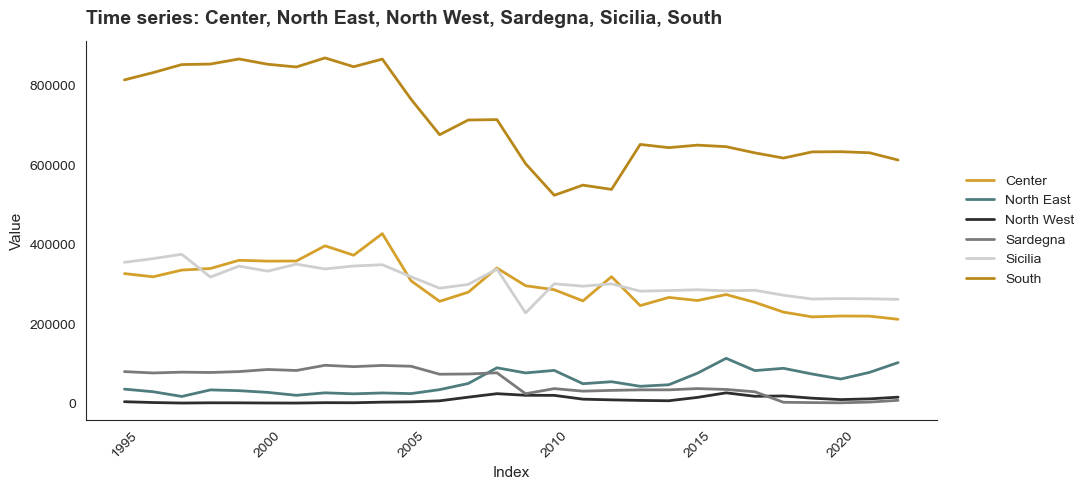

****************************************************************************************************
SOFT WHEAT CULTIVATED AREA
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max
MACRO_REGION,,,,,,,,
Center,28,131621,48680.1,57633,92679,127141,159308,259345
North East,28,251833,23405.4,207304,237165,247504,265376,303808
North West,28,146082,15906,112072,136461,144736,151986,183912
Sardegna,28,77.6861,158.41,0,0,0,42.75,579
Sicilia,28,706.821,341.473,110,400,620,1100,1170
South,28,80424.4,21191.6,30087,69061.8,75927.5,85804.3,132472


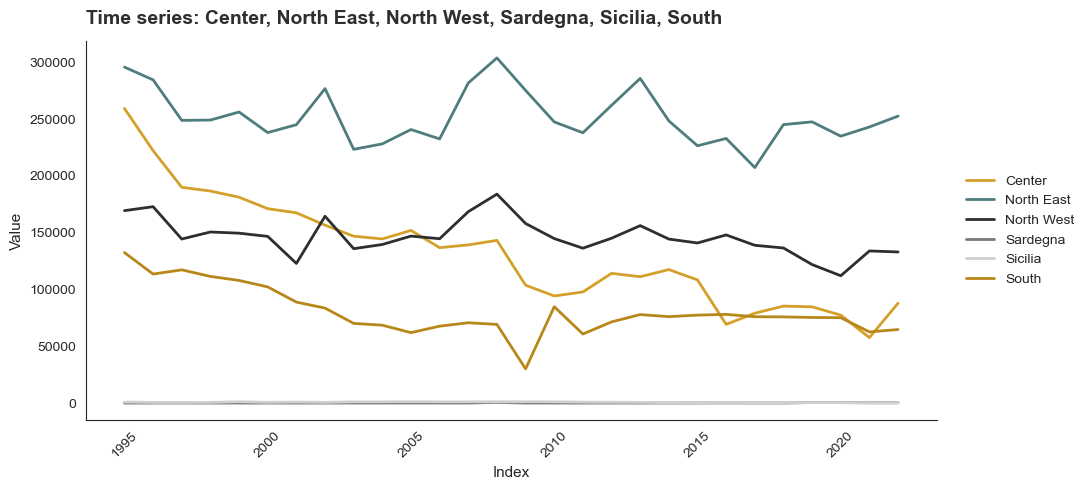

****************************************************************************************************
GRAIN MAIZE CULTIVATED AREA
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max
MACRO_REGION,,,,,,,,
Center,28,67823.4,20467.1,31373,51166,68906.3,85107.9,95446.9
North East,28,417605,104401,243467,316749,437935,494601,576008
North West,28,385430,71884.4,258846,311042,410725,439875,480801
Sardegna,28,2479.06,1434.2,387,1410.25,2462.51,3186.51,5399.01
Sicilia,28,354.071,151.254,188,205,300,477,610
South,28,37345.3,7918.19,26460.5,30363.8,36770.7,43874.3,51319.5


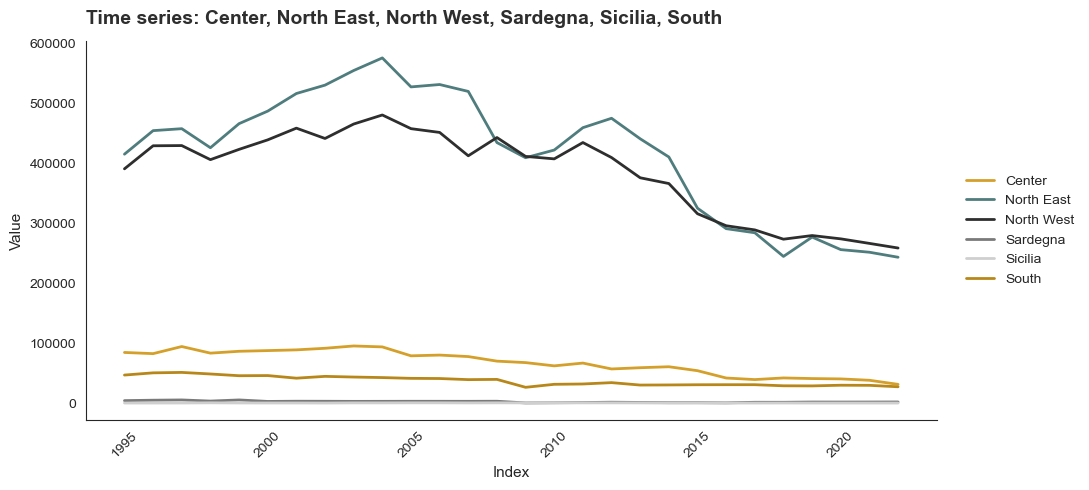

In [58]:
MACRO_REGION_ORDER = [
    "North West",
    "North East",
    "Center",
    "South",
    "Sicilia",
    "Sardegna",
]

area_distribution = data[
    [
        "crop_name",
        "REGION",
        "MACRO_REGION",
        "harvest_year",
        "area",
    ]
].copy()

# Aggregate provincial cultivated area within each macro-region and year.
annual_macro_area = (
    area_distribution
    .groupby(
        [
            "crop_name",
            "MACRO_REGION",
            "harvest_year",
        ],
        as_index=False,
    )["area"]
    .sum()
)

for crop in CROPS:
    print('*'*100)
    print(crop.upper(),"CULTIVATED AREA")
    print('*'*100)

    area_macro_pivot = annual_macro_area[annual_macro_area["crop_name"] == crop].pivot(
            index="harvest_year",
            columns="MACRO_REGION",
            values="area"
        )
    
    display(area_macro_pivot.describe().T)

    plot_time_series(
        area_macro_pivot,
        columns=area_macro_pivot.columns.tolist(),
        figsize=(11, 5)
    )

In [59]:
SELECTED_AREAS = {
    "Durum wheat": [
        {
            "key": "north",
            "label": "North West + North East",
            "macro_regions": ["North West", "North East"],
        },
        {
            "key": "center",
            "label": "Center",
            "macro_regions": ["Center"],
        },
    ],

    "Soft wheat": [
        {
            "key": "north_east",
            "label": "North East",
            "macro_regions": ["North East"],
        },
        {
            "key": "center",
            "label": "Center",
            "macro_regions": ["Center"],
        },
    ],

    "Grain maize": [
        {
            "key": "north",
            "label": "North West + North East",
            "macro_regions": ["North West", "North East"],
        },
        {
            "key": "center",
            "label": "Center",
            "macro_regions": ["Center"],
        },
        {
            "key": "sardegna",
            "label": "Sardegna",
            "macro_regions": ["Sardegna"],
        },
    ],
}

In [60]:
# Add the EDA macro-region classification to the final predictions.
territorial_predictions = final_predictions.copy()

# Build area-weighted yield aggregates for the selected territories.
selected_area_tables = []


for crop, areas in SELECTED_AREAS.items():

    for area in areas:

        area_data = territorial_predictions[
            (territorial_predictions["crop"] == crop)
            & (
                territorial_predictions["MACRO_REGION"]
                .isin(area["macro_regions"])
            )
        ].copy()


        _, area_predictions = (
            aggregate_national_predictions(
                area_data
            )
        )


        area_predictions["area_key"] = area["key"]
        area_predictions["area_label"] = area["label"]

        selected_area_tables.append(
            area_predictions
        )


selected_area_predictions = pd.concat(
    selected_area_tables,
    ignore_index=True,
)

In [61]:
display(
    selected_area_predictions[
        [
            "crop",
            "area_label",
            "harvest_year",
            "yield_real",
            "yield_q1",
            "yield_q2",
            "yield_q3",
        ]
    ]
)

,crop,area_label,harvest_year,yield_real,yield_q1,yield_q2,yield_q3
0,Durum wheat,North West + North East,2019,4.9257,5.33857,5.7747,6.13902
1,Durum wheat,North West + North East,2020,5.6365,5.03785,5.40316,5.86633
2,Durum wheat,North West + North East,2021,6.75119,5.24987,5.69584,6.02291
3,Durum wheat,North West + North East,2022,5.48553,5.73943,6.29714,6.47246
4,Durum wheat,Center,2019,3.72183,3.44457,3.73181,4.05401
5,Durum wheat,Center,2020,3.77367,3.47866,3.77282,4.0865
6,Durum wheat,Center,2021,3.71781,3.44856,3.74605,4.04535
7,Durum wheat,Center,2022,3.63915,3.36441,3.64866,3.95762
8,Soft wheat,North East,2019,5.74326,6.21774,6.61092,6.998
9,Soft wheat,North East,2020,6.26101,5.2349,5.73375,6.1713


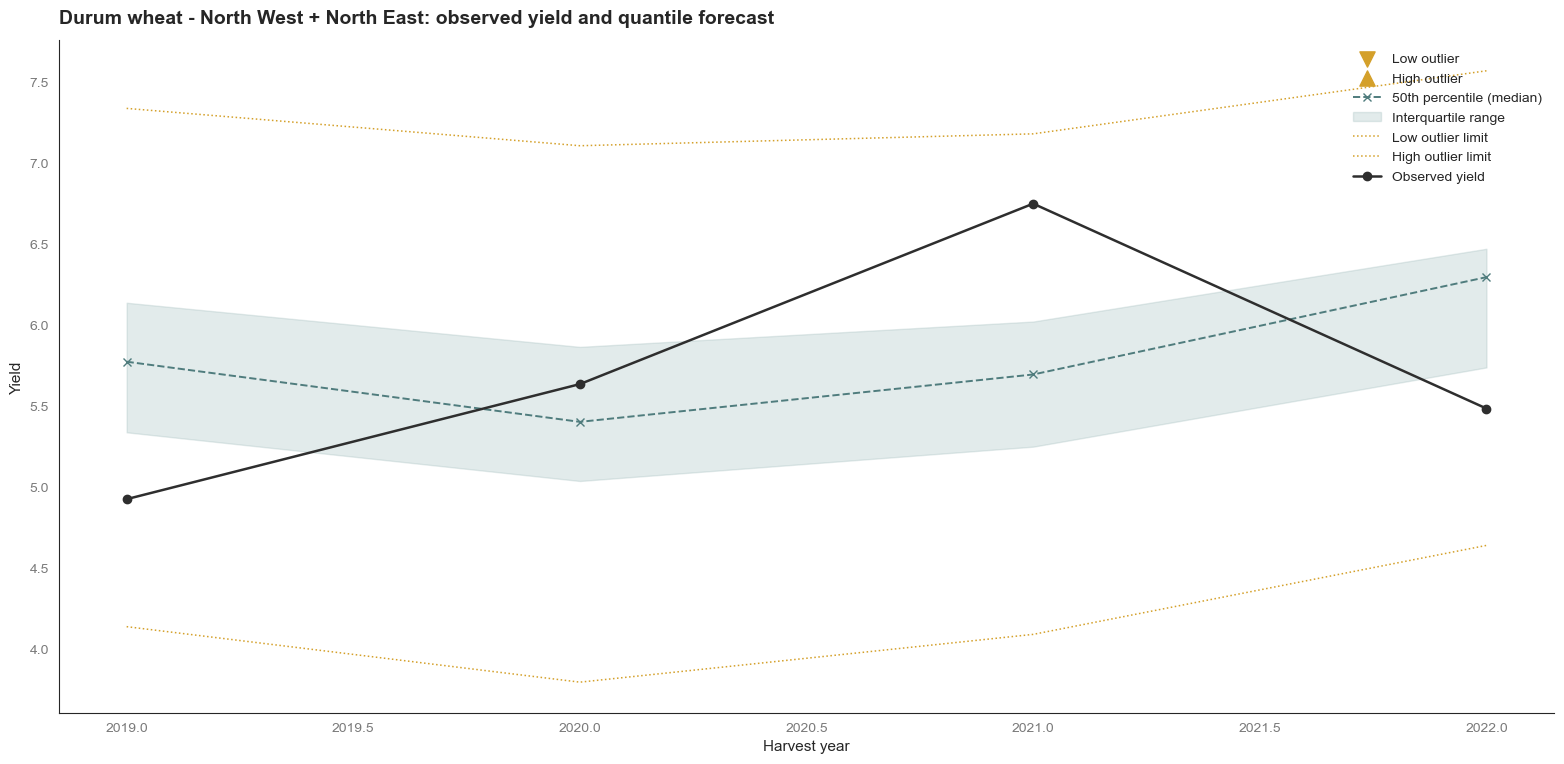

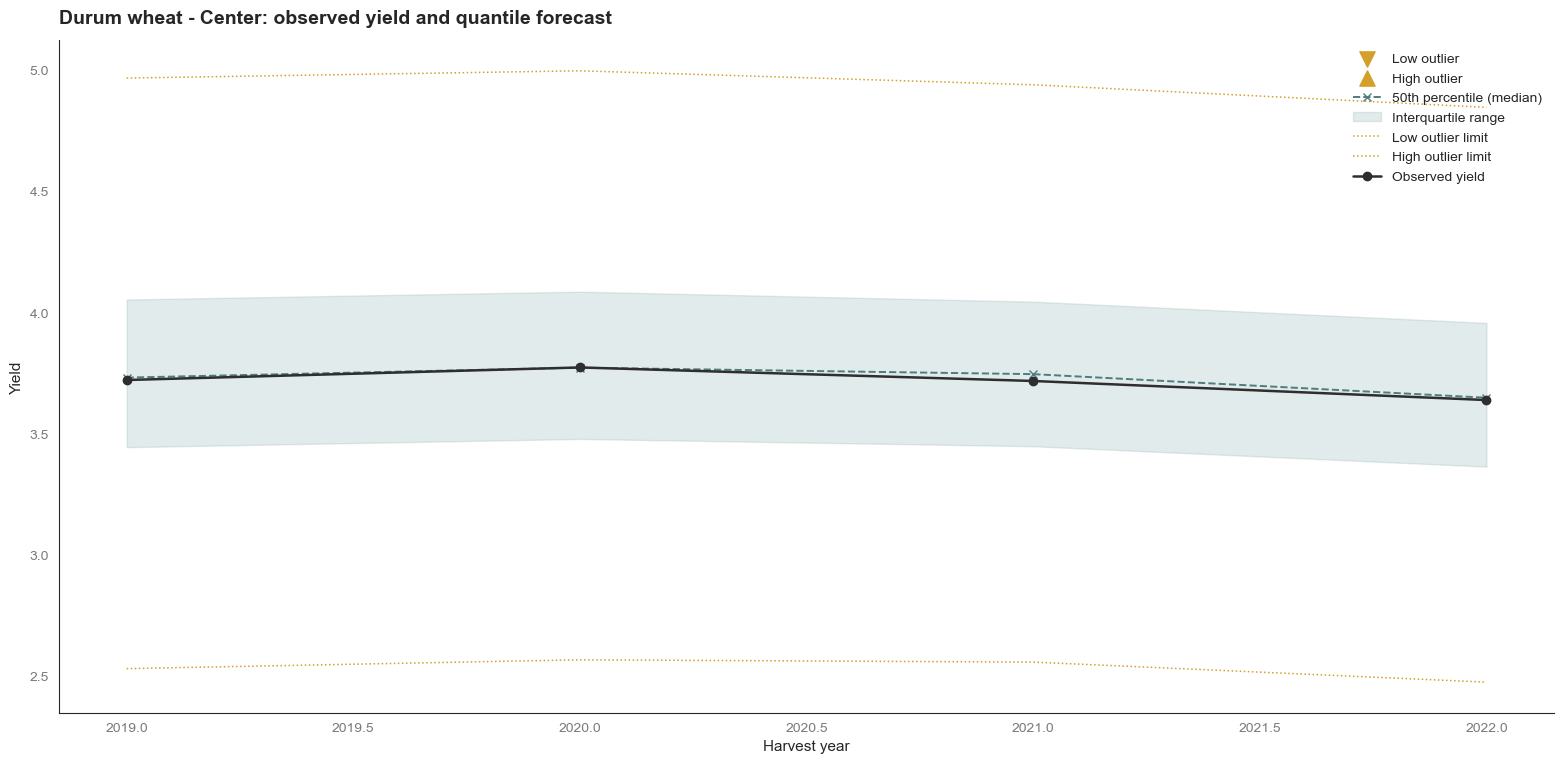

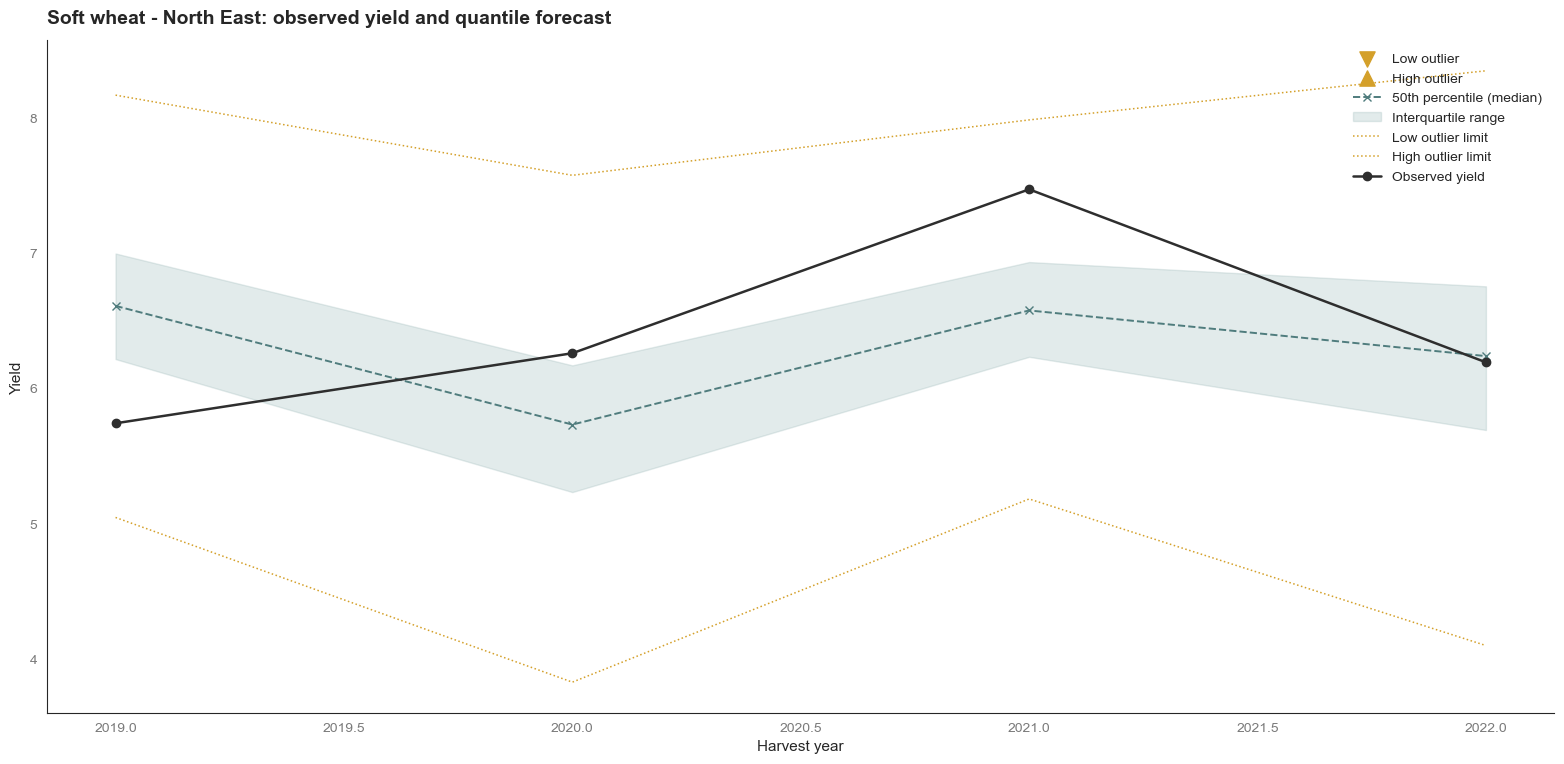

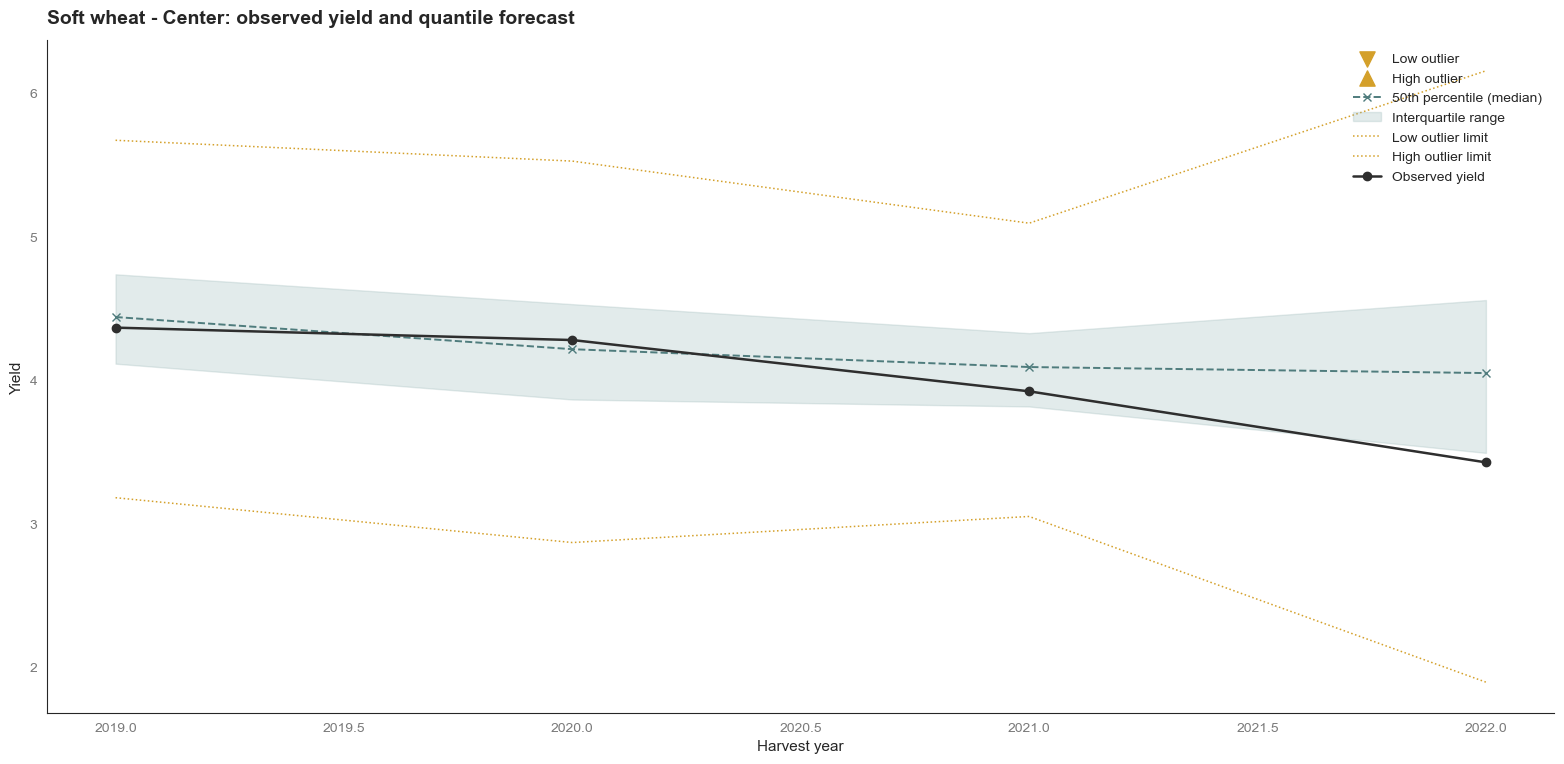

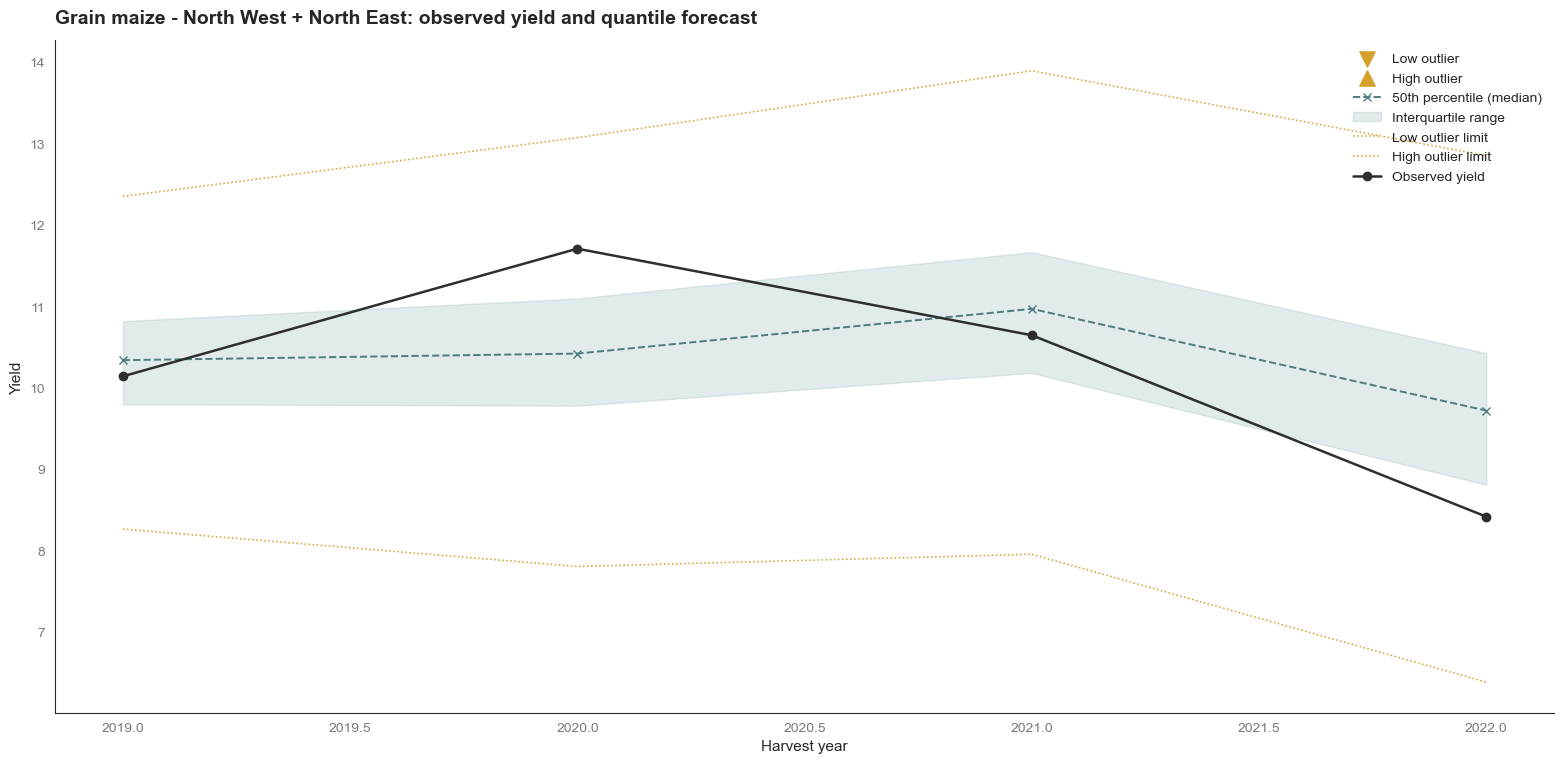

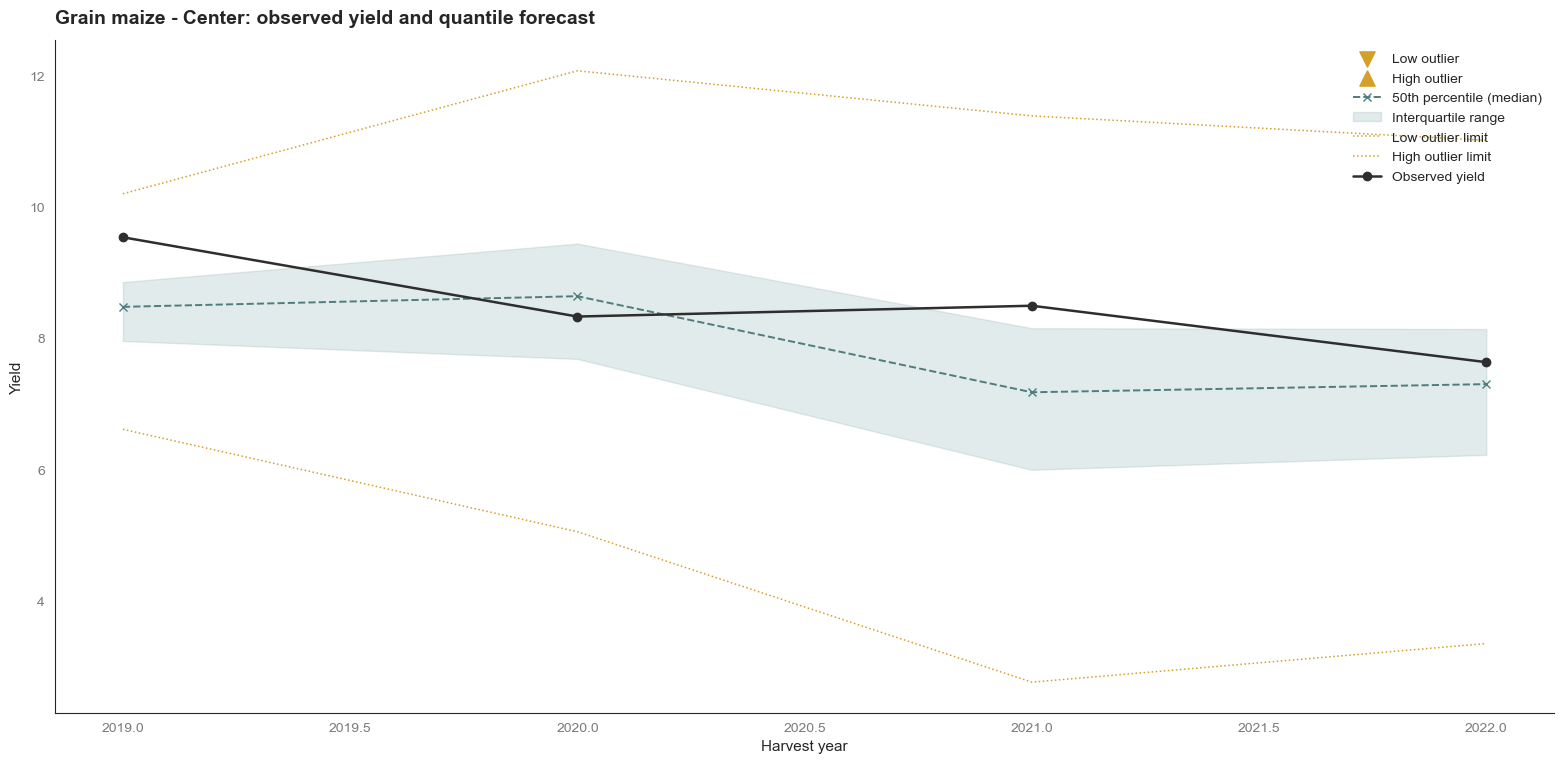

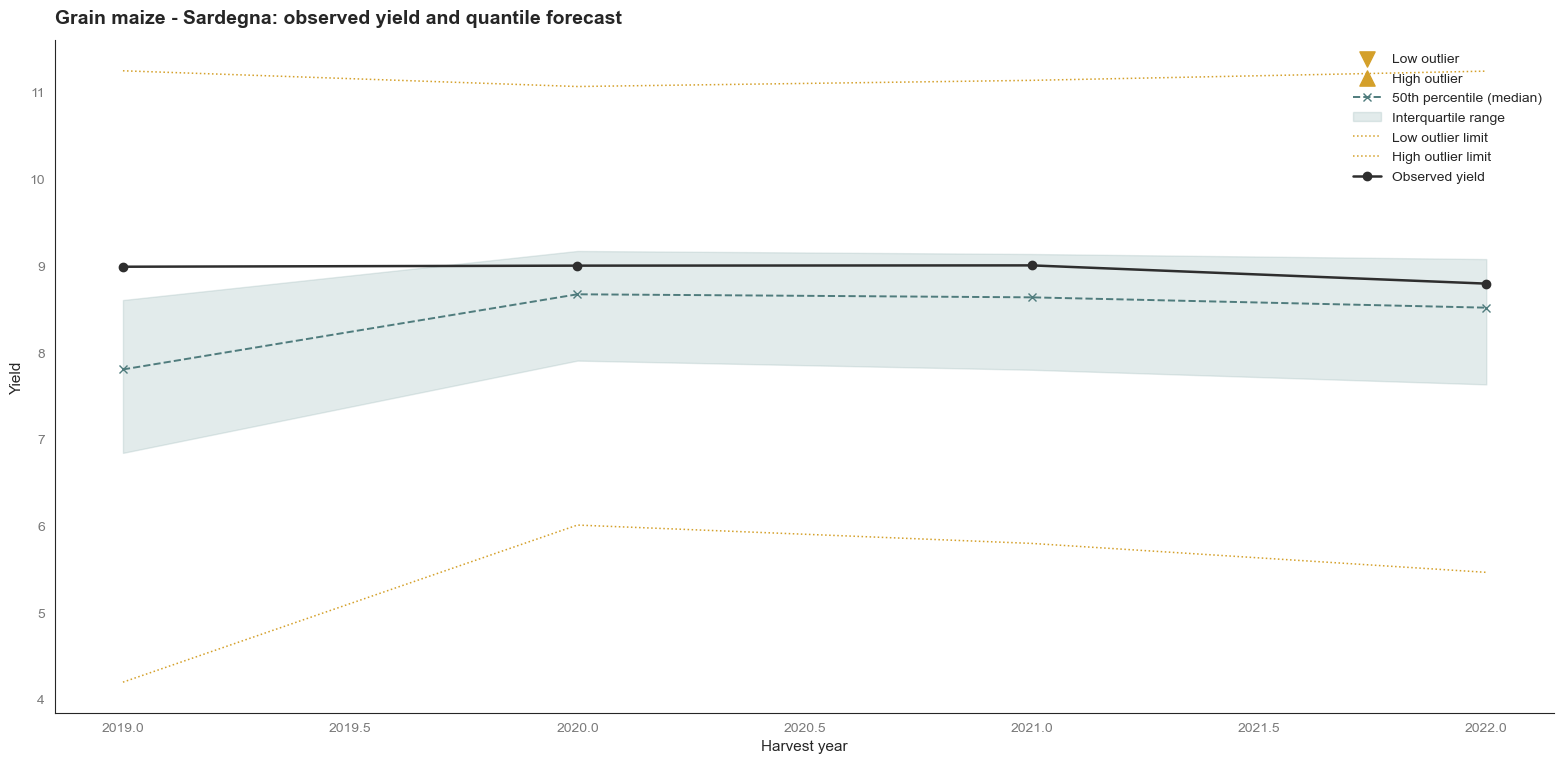

In [62]:
# Plot the selected territorial views for each crop.
for crop in CROPS:

    for area in SELECTED_AREAS[crop]:

        plot_data = selected_area_predictions[
            (selected_area_predictions["crop"] == crop)
            & (
                selected_area_predictions["area_key"]
                == area["key"]
            )
        ]

        plot_national_quantile_forecast(
            plot_data,
            crop,
            area_label=area["label"],
        )

### Territorial test performance and agricultural implications

The territorial aggregation provides a more informative view of final-model behaviour than national results alone. The 2019–2022 test period shows that predictive performance differs substantially across geographical contexts, and that these differences should be interpreted together with the actual distribution of cultivated area.

Importantly, cultivated area is used here as an indicator of **agricultural relevance rather than monetary economic value**: errors in areas where a crop is extensively cultivated potentially affect a much larger share of the corresponding production system.

#### Durum wheat

The contrast between **Center** and **North West + North East** is particularly informative.

In Central Italy, where durum wheat occupies a substantially larger cultivated area than in northern Italy, the model reproduces the observed aggregated yield remarkably closely throughout the test period. Both the yield level and its limited year-to-year variation are captured, with the median prediction almost overlapping the observed series.

The northern aggregate presents a more variable production regime. Observed yield rises markedly between 2019 and 2021 before falling again in 2022, while the predicted median follows a considerably smoother trajectory. The model therefore does not fully reproduce the amplitude of these interannual fluctuations. This limitation should, however, be interpreted in context: the observed values remain relatively close to the estimated interquartile range, and all remain well within the broader predictive boundaries. The model is therefore identifying a plausible northern yield regime even when the realised annual outcome departs from its central forecast.

The sharp decline between 2021 and 2022 is particularly worth investigating rather than treating automatically as evidence of model failure. The selected durum wheat model relies strongly on information describing previous local yield behaviour and therefore tends to extrapolate from the historical production regime observed up to that point. If the 2022 decline was associated with an unusually severe climatic event, a change in management conditions, input availability, disease pressure, or another factor not represented — or not previously observed with comparable intensity — in the training data, a substantial deviation from the central prediction would be expected. The forecast error can therefore also act as a diagnostic signal, identifying crop-year-territory combinations for which the historical relationships learned by the model no longer provide a complete explanation.

This geographical contrast reinforces an important result already emerging from the EDA. Durum wheat showed strong spatial structuring, and several environmental variables associated with yield also displayed marked geographical gradients. The near-perfect correspondence obtained in the Center indicates that the model captures very effectively the relatively stable historical production regime of an area where durum wheat is extensively cultivated. In the North, the same model still identifies the appropriate overall yield range, but realised outcomes fluctuate more strongly around it. Rather than invalidating the forecast, this suggests that the northern series may contain more year-specific information than can be inferred from historical yield dynamics alone.

The territorial results therefore provide two complementary forms of evidence: **strong predictive accuracy in the more important Central Italian durum-growing system, and useful uncertainty-aware forecasts in the more variable northern context**, where larger departures from the median may themselves motivate further investigation into the conditions affecting individual harvest years.

#### Soft wheat

For soft wheat, the **North East** represents an especially demanding and practically relevant test because it combines the largest cultivated area with the highest yield levels observed during the EDA.

The model correctly identifies this high-yield regime, but the central forecast smooths some of its substantial interannual variability. In particular, the high observed yield in 2021 is underestimated, while 2019 is overestimated. The 2022 value, by contrast, is reproduced very closely. The uncertainty interval generally accommodates these deviations, indicating that the model represents their plausibility better than the median prediction alone would suggest.

The **Center** presents a different profile: yields are lower and their trajectory is smoother. Here the model follows the observed series closely from 2019 to 2021 and correctly identifies a declining tendency, although the fall observed in 2022 is stronger than predicted.

This combination is relevant from an agricultural perspective. The model performs reasonably well in the North East — the area in which soft wheat is most widespread and productive — while the comparison with the Center confirms that it also distinguishes substantially different territorial yield regimes. At the same time, the northern results show that exceptionally favourable seasons remain more difficult to anticipate precisely.

#### Grain maize

Grain maize provides the strongest example of why cultivated-area distribution and yield behaviour should be considered jointly.

Cultivation is overwhelmingly concentrated in **North West + North East**, making this the most consequential territorial evaluation for the crop. The model correctly represents the high northern yield regime and captures the pronounced deterioration observed in 2022, although it underestimates the magnitude of both the favourable 2020 observation and the subsequent decline. Thus, the model identifies the broad movement of the main maize production system while remaining less accurate for unusually strong annual departures.

The comparison with **Center** and **Sardegna** is particularly interesting because their cultivated area is much smaller, whereas their observed yields are not proportionally lower. Central Italy shows intermediate yields and greater year-to-year variation, which the model captures only partially. Sardegna is even more distinctive: observed yield remains remarkably stable around a relatively high level during the test period despite the limited cultivated area. The model recognises this stability but systematically predicts somewhat lower values, especially at the beginning of the test period.

The Sardinian result should therefore not be interpreted as evidence that maize cultivation should simply be expanded there. It does, however, highlight a potentially interesting geographical configuration: a territory with limited maize diffusion but comparatively strong and stable observed productivity. This is exactly the type of pattern that deserves further agronomic and economic investigation.

#### From forecasting to agricultural decision support

These results suggest that the models can provide information beyond a single national yield forecast.

First, they can distinguish **territorial production regimes**: high-yield and highly cultivated systems such as soft wheat and maize in northern Italy, the stable durum-wheat system of Central Italy, and smaller but potentially interesting cases such as maize in Sardegna.

Second, the quantile forecasts provide a way to consider not only expected yield but also **uncertainty and downside risk**. A territory with a high expected yield but wide or unstable predictive intervals represents a different production profile from an area with slightly lower but much more stable expected outcomes. This distinction could be relevant when comparing possible cultivation strategies.

Third, differences between cultivated-area importance and observed productivity can be used to identify territories worth investigating further. The maize results are a clear example: the North remains the dominant production area, but the relatively high yields observed in Sardegna and, to a lesser extent, the Center indicate that present crop diffusion and observed productivity are not necessarily proportional.

These models should nevertheless **not be interpreted as causal crop-allocation models**. A higher predicted yield in one territory does not imply that moving or expanding cultivation there would produce that yield. The models learn from historically observed combinations of geography, previous yield, environmental conditions and cropping patterns; they do not simulate the consequences of changing land use, management practices or crop allocation.

Their most defensible role is therefore as a **screening and decision-support layer**. They can help identify:

* territories where a crop currently combines substantial diffusion with strong or stable expected productivity;
* areas where observed productivity appears unexpectedly high relative to current cultivation extent;
* production systems characterised by greater interannual uncertainty or downside risk;
* years and territories where observed yield departs materially from the modelled historical regime.

Combined with information on soils, irrigation availability, production costs, crop prices, rotations and agronomic constraints, these signals could support more targeted analyses of **where maintaining, adapting or further investigating particular crops may be most worthwhile**.

Overall, the territorial results strengthen rather than replace the national evaluation. They show that model usefulness depends not only on aggregate predictive accuracy, but also on **where the predictions are accurate, how important the crop is in those territories, and whether the model can distinguish the different agricultural systems in which the crop is grown**.

## Final modelling synthesis

The modelling stage leads to three different final specifications for the three crops:

* **Durum wheat: Linear quantile regression (Historical feature set)**
* **Soft wheat: TabPFN (Full feature set)**
* **Grain maize: TabPFN (SFS-selected feature set)**

These models were selected before the final test evaluation and subsequently refitted on the complete pre-test period. The final test therefore remains an independent assessment of the modelling choices rather than an additional model-selection step.

Despite their different complexity, the three models reveal a consistent underlying structure: **provincial yield is strongly anchored to its recent history and to persistent local and regional production patterns, while environmental conditions can modify that baseline.** The strength and form of this environmental adjustment, however, differ substantially among crops.

### Final predictive skill relative to persistence

The independent test also provides a stricter perspective on how much predictive value the final models add beyond the simplest temporal signal.

At Q2, all three selected specifications outperform naive persistence, but by markedly different margins:

* **Grain maize:** `TabPFN SFS` reduces test pinball loss by approximately **14.8%**;
* **Soft wheat:** `TabPFN Full` improves by approximately **1.0%**;
* **Durum wheat:** `Linear H` improves by only approximately **0.2%**.

The distinction is important for interpreting the models below. Feature coefficients and SHAP values describe **how a fitted model constructs its predictions**, but they do not by themselves measure how much predictive information those features add over a simpler benchmark.

The strongest evidence of genuinely incremental median predictive skill is therefore obtained for **Grain maize**. For **Soft wheat**, the richer environmental representation is selected by the chronological validation procedure and is actively used by the fitted model, but its final-test Q2 advantage over persistence is modest. For **Durum wheat**, persistence is already an exceptionally strong median benchmark over 2019–2022, leaving almost no additional Q2 skill for the richer historical specification to capture.

The quantile models nevertheless provide information that the point-based persistence benchmark does not: Q1 and Q3 describe the conditional uncertainty around the median forecast. The baseline comparison therefore measures incremental **median predictive skill**, not the full value of the probabilistic forecast.


### Durum wheat: a strong geographical footprint for both yield and relevant climate informations

Durum wheat is the clearest and, in some respects, most revealing case. Its final model is linear and quite compact, using only recent yield and rolling provincial and regional yield information.

Across the three conditional quantiles, `yield_lag_1` remains a major predictor. The provincial rolling median also has a strong and stable contribution, while the regional rolling median is smaller but consistently positive. At Q3, the two rolling geographical terms become relatively more important, indicating that the upper part of the predicted yield distribution is particularly associated with provinces and regions characterised by persistently high productivity.

The model therefore combines two forms of persistence:

**recent yield captures short-term continuity, while provincial and regional rolling yields capture the persistent geographical structure of productivity.**

This result becomes especially informative when read against the EDA.

Among the three crops, Durum wheat showed some of the **strongest marginal associations between yield and environmental conditions**. Higher evapotranspiration, wind speed and radiation were among the clearest negative correlates of yield. The planting and early vegetative phase was particularly prominent for evapotranspiration and radiation, while wind speed appeared repeatedly across crop phases. Temperature and vapour-pressure variables also showed negative associations, whereas greater persistence of frost during the vegetative-reproductive phase was positively associated with yield.

Crucially, these signals were also **strongly geographical**.

The macro-regional comparison showed a persistent yield gradient: **North West and North East generally occupied the high-yield end of the distribution, Center was intermediate, and South, Sicilia and especially Sardegna tended towards lower yields.**

The climatic variables associated with yield largely followed the same spatial structure. **Early-season evapotranspiration was lowest in the northern macro-regions, increased through the central and southern areas, and reached its highest levels in Sicilia and Sardegna.** Radiation showed a broadly comparable north-to-south climatic gradient. **Vegetative-reproductive wind speed was generally lower in the North and higher in the South and islands.** Frost persistence moved in the opposite direction: it was longest in the northern areas and shortest in Sicilia and Sardegna.

The important point is therefore not simply that *high ET0 or high wind correlate with lower yield*. The EDA showed that the combinations

**higher yield + lower atmospheric demand + lower wind + greater frost exposure**

and

**lower yield + higher atmospheric demand + higher wind + limited frost exposure**

are also, to a considerable extent, **different parts of Italy**.

This explains why explicit climate variables can appear important in the EDA yet fail to improve the final Durum-wheat model once historical provincial and regional yield information is available. A five-year provincial rolling yield is not a climate variable, but it is an extremely effective empirical summary of a territory: it retains persistent information associated with climate together with soils, cropping systems, agronomic practices and other stable local characteristics.

Likewise, the regional rolling yield explicitly carries part of the broader north–south production structure.

The modelling result should therefore **not** be interpreted as evidence that climate is unimportant for durum wheat. It supports a more specific conclusion: **the strongest climate–yield relationships identified in the EDA are heavily spatially structured, and much of their predictive information is already encoded in the recent production history of the same province and region.**

Once that geographical baseline is known, the available explicit climatic variables do not provide enough additional out-of-time predictive information to justify a more complex final model.

The final-test comparison with naive persistence further sharpens this interpretation. Although the complete historical specification combines previous-year yield with longer provincial and regional production baselines, its Q2 loss is only about **0.2% lower than persistence** over 2019–2022. For median prediction in this particular test period, most of the usable signal was therefore already contained in the immediately preceding yield observation. The additional historical terms remain useful for defining the fitted conditional distribution and its territorial structure, but they provide little incremental Q2 skill over the naive benchmark.

The `yield_lag_1_missing` coefficient should instead be interpreted only as a technical correction associated with unavailable historical observations, not as an agricultural driver.

### Grain maize: historical baseline with targeted climatic influence

The final Grain-maize TabPFN uses the smaller SFS-selected feature set, and its SHAP structure is correspondingly concentrated.

Historical productivity again dominates. The provincial rolling yield and previous-year yield generate the largest adjustments, with higher values clearly increasing predicted yield. The regional rolling statistic provides an additional geographical reference.

Unlike Durum wheat, however, **climatic information remains explicitly useful after this historical baseline has been established**.

The strongest environmental signals are concentrated in agronomically meaningful parts of the growing cycle. Early-season vapour-pressure conditions affect the prediction, while variables describing water availability, heavy rainfall, dryness and temperature extremes during the vegetative-reproductive phase further modify it. In particular, greater exposure to extreme heat, more dry days and a wider spatial extent of intense rainfall tend to be associated with less favourable predictions.

The resulting model is therefore relatively parsimonious despite its nonlinear form: it first identifies the productivity level that is plausible for a province from its recent and local history and then **adjusts that expectation according to a limited set of relevant seasonal conditions**.

For Grain maize, climate is therefore not a diffuse background signal. It acts through a comparatively small group of variables that provide targeted corrections to an otherwise strongly persistent local yield process.

The final-test benchmark provides independent support for this interpretation: `TabPFN SFS` reduces Q2 pinball loss by approximately **14.8%** relative to naive persistence. Among the three crops, Grain maize therefore provides the clearest evidence that combining historical productivity with additional seasonal information produces materially greater median predictive skill than simply carrying the previous year's yield forward.

### Soft wheat: historical backbone with a distributed environmental response

Soft wheat requires the most complex final model. TabPFN performs best with the **full predictor set**, and its SHAP analysis confirms that this complexity is used differently from the SFS Grain-maize model.

The dominant individual variables remain familiar: previous-year yield and the provincial and regional rolling medians establish a strong historical and geographical backbone. High values of all three are associated with higher predicted yield.

The environmental component is instead spread across a much larger number of predictors. No single climatic feature approaches the importance of yield history, but several coherent patterns emerge across the crop cycle.

During planting and early vegetative development, thermal variability contributes to differentiating more and less favourable situations. During the vegetative-reproductive phase, evapotranspiration and precipitation-related variables indicate that atmospheric water demand and the spatial distribution of moisture conditions matter to the model.

The clearest adverse pattern appears during **ripening and harvest**. Greater exposure to extreme heat and a larger occurrence of hot days are associated with lower yield predictions. Higher cumulative atmospheric water demand during earlier development also tends to be unfavourable, while several moisture-related indicators move predictions towards more favourable outcomes under the conditions represented in the data.

The important result is therefore not the existence of one dominant “Soft-wheat climate variable”. Instead, TabPFN uses **many individually moderate environmental signals jointly**. The SHAP aggregation of the remaining 182 predictors reinforces this interpretation: the full model extracts information from a long tail of small contributions rather than relying on a hidden fourth dominant feature.

Soft wheat consequently appears as the crop for which the predictive contribution of the environment is **most distributed and multivariate**.

The final-test baseline comparison requires a more cautious interpretation of these attributions. Although SHAP shows that the fitted `TabPFN Full` model makes use of a broad set of environmental variables, its Q2 pinball loss is only about **1.0% lower than naive persistence** over 2019–2022. The distributed environmental signal is therefore clearly part of the model's predictive mechanism, but the independent test provides only modest evidence that this additional complexity translates into incremental **median** forecasting skill beyond the strong previous-year-yield benchmark.

### What the three models say together

Taken together, the three final models suggest a clear hierarchy of information.

**The first level is local productive capacity.**
Previous yield and rolling provincial and regional productivity provide the strongest and most recurrent signal across crops. Agricultural yield in one province is therefore not predicted as an isolated response to the weather of a single season: it is strongly conditioned by where production occurs and by what that area has been capable of producing in recent years.

**The second level is the current growing season.**
Environmental conditions move the prediction away from this historical baseline when they contain additional information. Their role ranges from being largely absorbed by historical and geographical predictors for Durum wheat, to a limited set of targeted corrections for Grain maize, to a broad multivariate adjustment for Soft wheat.

Durum wheat makes the relationship between these two levels particularly clear. Its EDA initially produced what looked like a strong climate signal, but that signal was also geographically organised: the more productive northern territories systematically occupied different ranges of evapotranspiration, radiation, wind and frost exposure from the less productive southern and island territories. The historical provincial and regional predictors therefore encode much of the same spatial information.

This explains why the exploratory and modelling results are not contradictory. **A strong pooled climate–yield relationship can be agriculturally meaningful while still providing little incremental forecasting value once the model already knows the recent productivity of the territory in which that climate occurs.**

The distinction matters. The models are not saying that Italian agricultural production is driven by history instead of climate. They indicate that **climate operates within highly persistent geographical production systems**, and that part of its spatial signal is inseparable, for predictive purposes, from those systems unless additional within-location variation provides independent information.

Where that independent information remains detectable, the nonlinear models use it. For Grain maize it appears through a relatively compact set of water-, heat- and atmospheric-related indicators. For Soft wheat it appears as a much broader combination of seasonal environmental conditions.

From an agricultural perspective, a single national climate–yield relationship would therefore miss an important part of the phenomenon. Identical values of a climatic variable occur within territories characterised by different baseline productivity, and persistent differences among those territories reflect not only climate but also soils, production systems, management and other local characteristics not explicitly represented in the model.

At the same time, the models identify concrete environmental signals worth monitoring. **Atmospheric water demand, water availability and thermal stress repeatedly emerge as relevant dimensions**, although their importance, timing and predictive form differ between crops. Late-season heat stress is particularly visible in Soft wheat, while Grain maize responds through a more compact combination of water and temperature conditions.

These results are predictive rather than causal: they do not establish that modifying one climatic or agronomic variable would mechanically produce the corresponding change in yield. They do, however, establish which information the validated models actually use to distinguish more favourable from less favourable yield outcomes.

The main modelling conclusion can therefore be stated more precisely as:

> **History and geography define the expected yield of a territory. Climate is partly embedded in that geographical baseline and, where the current season contains additional information beyond it, modifies the prediction in a crop-specific way.**

For Durum wheat, the climatic signature is especially visible **between Italian production areas** and is consequently captured very effectively by their historical productivity. For Grain maize, a smaller set of seasonal conditions retains independent predictive value.
For Soft wheat, the fitted model uses a much broader combination of seasonal environmental conditions, although the final-test comparison with persistence shows that this richer representation translates into only modest incremental Q2 skill.
For Grain maize, the compact combination of historical and seasonal information translates into a substantial 14.8% reduction in Q2 loss relative to persistence.

## References

1. **Koenker, R., & Bassett, G. Jr. (1978).** Regression Quantiles. *Econometrica*, 46(1), 33–50. DOI: `10.2307/1913643`.

2. **Tashman, L. J. (2000).** Out-of-sample tests of forecasting accuracy: an analysis and review. *International Journal of Forecasting*, 16(4), 437–450. DOI: `10.1016/S0169-2070(00)00065-0`.

3. **Kohavi, R., & John, G. H. (1997).** Wrappers for feature subset selection. *Artificial Intelligence*, 97(1–2), 273–324. DOI: `10.1016/S0004-3702(97)00043-X`.

4. **Tibshirani, R. (1996).** Regression Shrinkage and Selection Via the Lasso. *Journal of the Royal Statistical Society: Series B (Methodological)*, 58(1), 267–288. DOI: `10.1111/j.2517-6161.1996.tb02080.x`.

5. **Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018).** CatBoost: Unbiased Boosting with Categorical Features. *Advances in Neural Information Processing Systems*, 31.

6. **Erickson, N., Purucker, L., Tschalzev, A., Holzmüller, D., Desai, P. M., Salinas, D., & Hutter, F. (2025).** TabArena: A Living Benchmark for Machine Learning on Tabular Data. *Advances in Neural Information Processing Systems*, 38, Datasets and Benchmarks Track. DOI: `10.52202/085713-0519`.

7. **Hollmann, N., Müller, S., Purucker, L., et al. (2025).** Accurate predictions on small data with a tabular foundation model. *Nature*, 637, 319–326. DOI: `10.1038/s41586-024-08328-6`.

8. **Grinsztajn, L., Flöge, K., Key, O., et al. (2026).** TabPFN-3: Technical Report. *arXiv preprint*, `arXiv:2605.13986`.

9. **Lundberg, S. M., & Lee, S.-I. (2017).** A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems*, 30, 4765–4774.

10. **Muschalik, M., Baniecki, H., Fumagalli, F., Kolpaczki, P., Hammer, B., & Hüllermeier, E. (2024).** shapiq: Shapley Interactions for Machine Learning. *Advances in Neural Information Processing Systems*, 37, Datasets and Benchmarks Track. DOI: `10.52202/079017-4141`.

11. **Chernozhukov, V., Fernández-Val, I., & Galichon, A. (2010).** Quantile and Probability Curves Without Crossing. *Econometrica*, 78(3), 1093–1125. DOI: `10.3982/ECTA7880`.